# 0 - Libraries


In [1]:
#Used for the first time in "Pathway to save figures"
import os
#Used for the first time in "Import DATA"
import pandas as pd
#Used for the first time in "Principal Component Analyses"
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#Used for the first time in "Hierarchical clustering"
import umap
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from scipy.stats import chi2
from matplotlib.colors import to_hex
from matplotlib.patches import Ellipse
from sklearn.neighbors import KNeighborsClassifier
from scipy.cluster.hierarchy import set_link_color_palette
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
from itertools import product
import joblib
from scipy.spatial import procrustes
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import warnings
 
#Used for the first time in "Release properties"
import seaborn as sns

#Used for the first time in "Check if data are comparable" - Statistical annotations
from scipy.stats import kruskal
from statannotations.Annotator import Annotator


#Some module create warnings for futur updates. Here we ignore them. Erase following line to restaure warnings.
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

In [ ]:
# ============================================================================
# CONFIGURATION VARIABLES
# ============================================================================
# All hardcoded variables and parameters used throughout the notebook

# Data processing options
NORMALIZE_PPR = False

# Clustering parameters
n_clust = 5  # Number of clusters for hierarchical clustering

# PCA parameters
n_components = 2  # Number of principal components

# Statistical parameters
confidence_level = 0.95  # Confidence level for ellipses and statistical tests
chi2_df = 2  # Degrees of freedom for chi-square critical value

# Visualization parameters
figure_size_default = (8, 6)
figure_size_large = (12, 6)
figure_size_traces = (15, 5)
figure_size_pca = (6, 5)
figure_size_biplot = (6, 6)
figure_size_subplots = (10, 6)
colormap_name = 'Set2'  # Matplotlib colormap for consistent colors
alpha_background = 0.4  # Alpha for background points
alpha_fill = 0.2  # Alpha for fill areas (SEM, ellipses)
alpha_traces = 0.3  # Alpha for individual traces
marker_size_default = 50
marker_size_large = 100
line_width_default = 2

# Time analysis parameters
baseline_duration = 0.5  # Duration of baseline in seconds
total_duration = 1.0  # Total trace duration in seconds
sampling_rate = 300  # Downsampled rate in Hz
peak_detection_start = 0.55  # Start time for peak detection
peak_detection_end = 0.58  # End time for peak detection
peak2_detection_start = 0.55  # Start time for second peak detection
peak2_detection_end = 0.58  # End time for second peak detection

# Plot limits and ranges
time_plot_start = 0.45  # Start time for trace plotting
time_plot_end = 1.0  # End time for trace plotting
percentile_threshold = 98  # Percentile for individual peak calculation

# Distance analysis parameters
random_seed = 42  # Random seed for reproducible results
n_bins_histogram = 51  # Number of bins for distance histograms
n_bins_traces = 21  # Number of bins for trace histograms

# File format and save options
save_format = "pdf"  # Format for saving figures
text_encoding = "utf-8"  # Encoding for text files

# Column removal lists (columns to exclude from PCA)
FAIL_COLUMNS = ['AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3']
ADDITIONAL_COLUMNS_TO_REMOVE = ['STD_baseline']

# Transform method for power transformation
FAIL_TRANSFORM_METHOD = 'yeo-johnson'  # or 'box-cox'

print("✓ Configuration variables loaded successfully")
print(f"✓ Number of clusters: {n_clust}")
print(f"✓ PCA components: {n_components}")
print(f"✓ Normalize PPR: {NORMALIZE_PPR}")
print(f"✓ Colormap: {colormap_name}")

# 1 - Data preparation

## 1.A. Direction for fig

In [2]:
output_dir = r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Figures"
os.makedirs(output_dir, exist_ok=True)

## 1.B. Import data
The PCA will use only the columns AMP1, AMP2, all PPRs and %Fail1 and 2. All the other columns will be un-selected.

In [3]:
#WT experiments
df_WT_pooled  = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="WT_pooled")
df_WT_Theo    = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="WT_Theo")
df_WT_Anthime = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="WT_Anthime")

#SynII experiments
df_SynII      = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="SynII")

#Calcium experiments
df_WT_1_5Ca   = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="Theo_1_5Ca")
df_WT_4Ca     = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="Theo_4Ca")

#Stability experiments
df_stab_before = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="Stability_Before")
df_stab_after  = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="Stability_After")

### 1.B.a Normalize PPR

In [4]:
# Pour toutes les dataframes de données, recalculer les colonnes PPRx/1 comme (AMPx / mean(AMP1...AMP10))

def recalc_ppr_mean(df):
    # Trouver toutes les colonnes AMPx (x=1..9)
    amp_cols = [f'AMP{i}' for i in range(1,10) if f'AMP{i}' in df.columns]
    amp_cols = [col for col in df.columns if col.startswith('AMP') and col.replace('AMP', '').isdigit()]
    amp_cols_sorted = sorted(amp_cols, key=lambda x: int(x.replace('AMP', '')))
    if not amp_cols_sorted:
        return df
    amp_mean = df[amp_cols_sorted].mean(axis=1)
    for amp_col in amp_cols_sorted:
        idx = int(amp_col.replace('AMP', ''))
        ppr_col = f'PPR{idx}/1'
        df[ppr_col] = df[amp_col] / amp_mean
    return df

# Appliquer à chaque dataframe de données
if NORMALIZE_PPR == True:
    df_WT_pooled = recalc_ppr_mean(df_WT_pooled)
    df_WT_Theo = recalc_ppr_mean(df_WT_Theo)
    df_WT_Anthime = recalc_ppr_mean(df_WT_Anthime)
    df_SynII = recalc_ppr_mean(df_SynII)
    df_WT_1_5Ca = recalc_ppr_mean(df_WT_1_5Ca)
    df_WT_4Ca = recalc_ppr_mean(df_WT_4Ca)
    df_stab_before = recalc_ppr_mean(df_stab_before)
    df_stab_after = recalc_ppr_mean(df_stab_after)

## 1.C. Check if data are comparable

### 1.C.a Amp1, Amp2, PPR 2/1, Fail1 and STD baseline comparison

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT_Theo vs. WT_Anthime: Kruskal-Wallis independent samples (pairwise between groups) with Bonferroni correction, P_val:2.331e-05 Stat=1.999e+01
WT_Anthime vs. SynII: Kruskal-Wallis independent samples (pairwise between groups) with Bonferroni correction, P_val:1.630e-06 Stat=2.510e+01
WT_Theo vs. SynII: Kruskal-Wallis independent samples (pairwise between groups) with Bonferroni correction, P_val:6.361e-01 Stat=1.558e+00
Kruskal-Wallis test for PPR2/1: H = 26.786, p = 0.000002
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

WT_Theo vs. WT_Anthime: Kruskal-Wallis independent samples (pairwise between groups) with Bonferroni correction, P_val:2.152e-01 Stat=

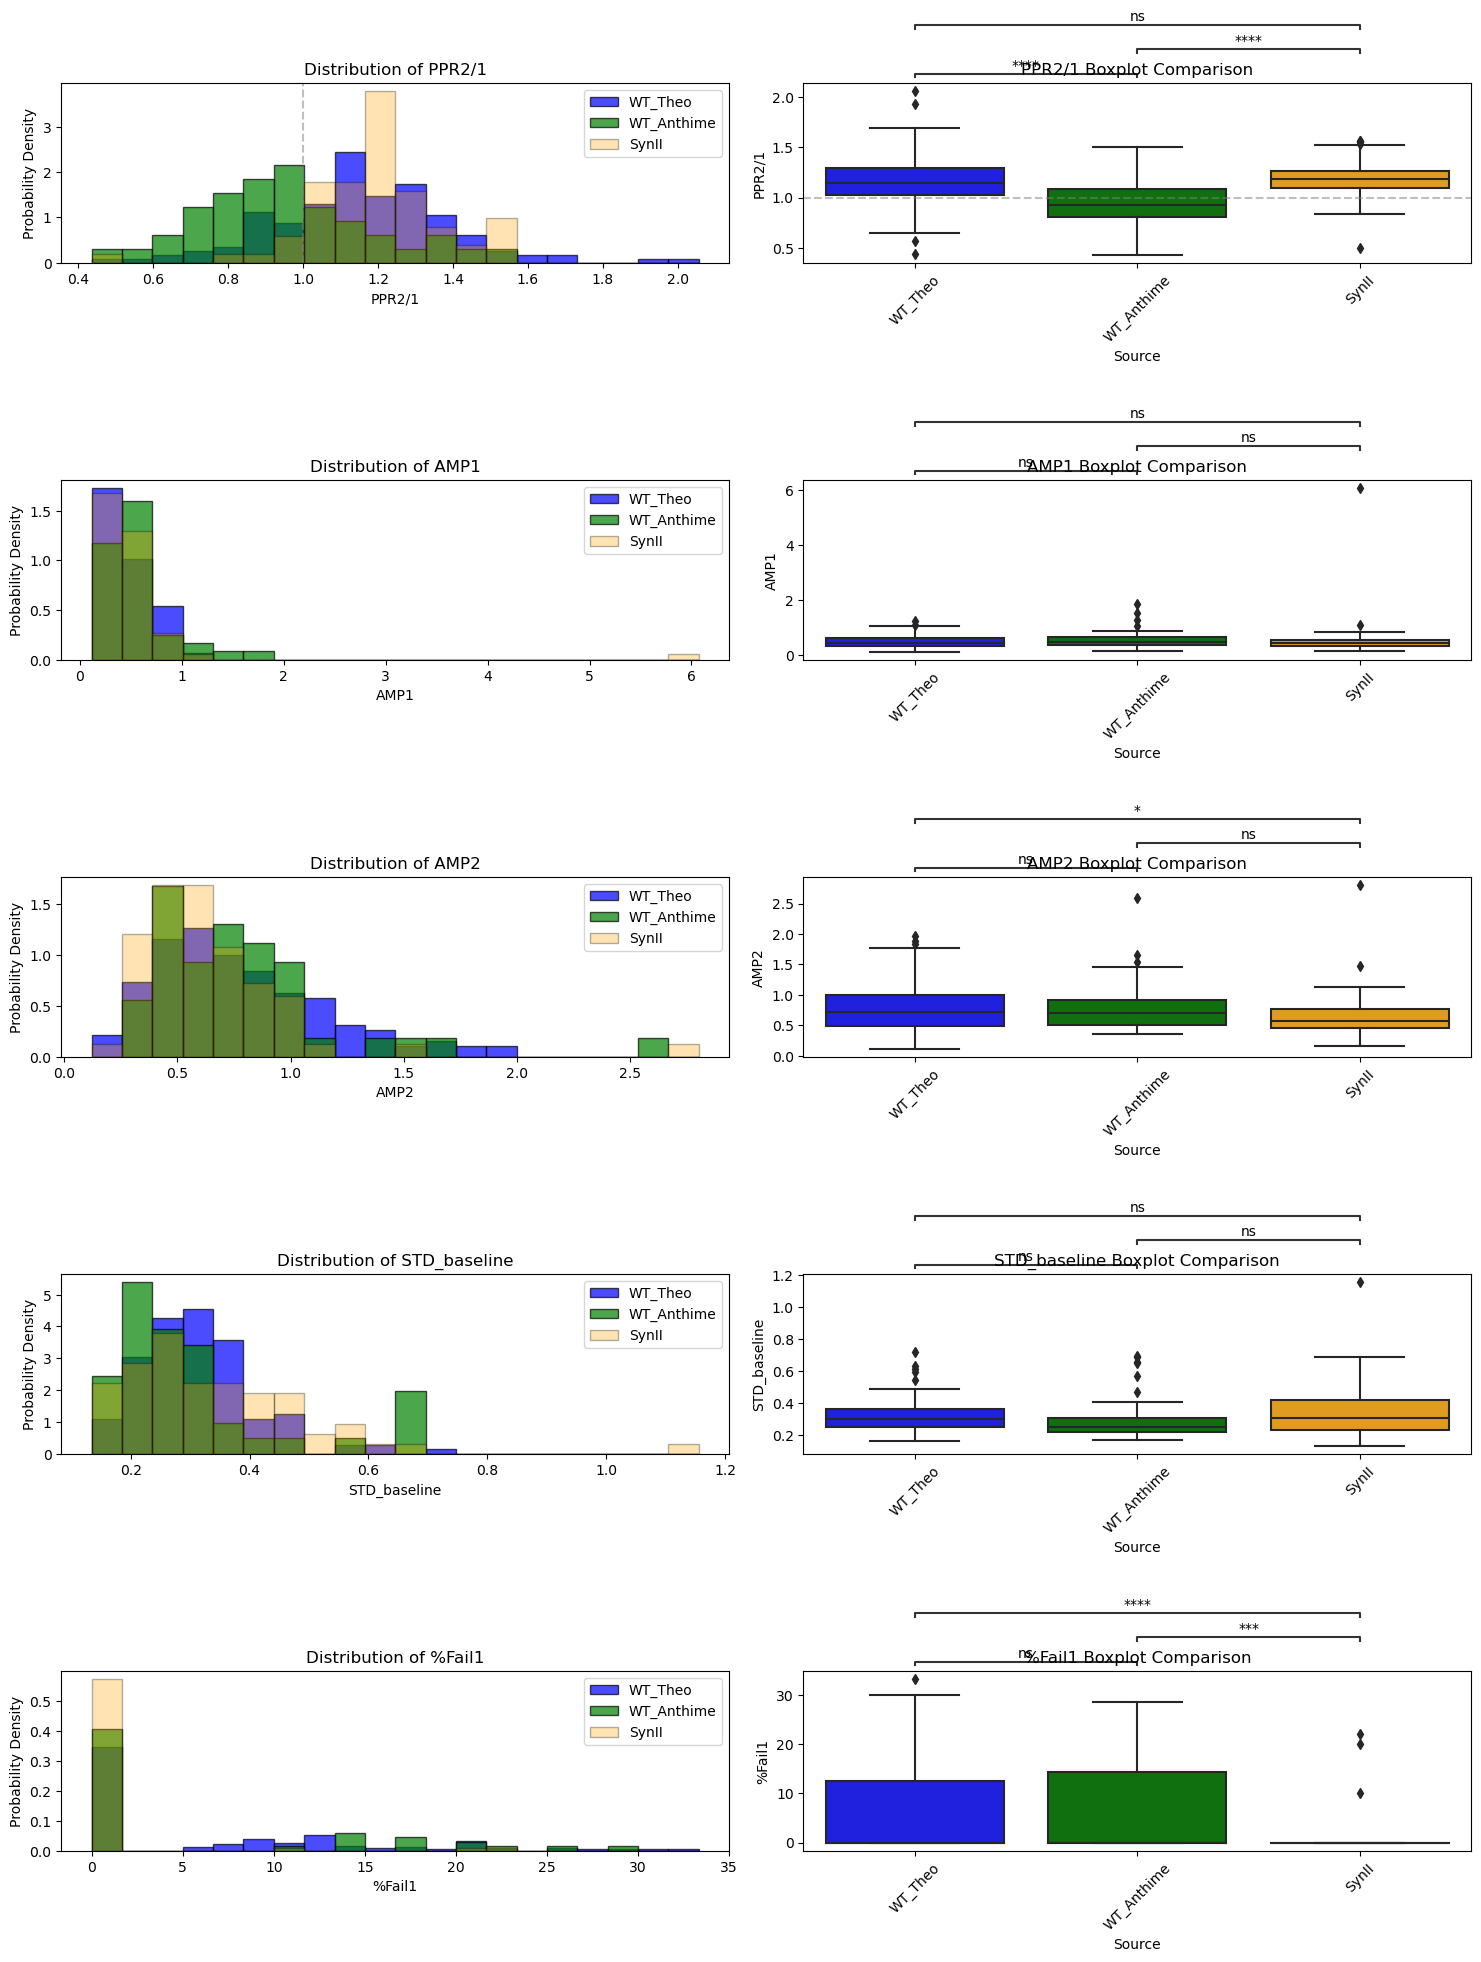

In [5]:
# Create a 5x2 subplot showing histograms (left) and boxplots (right) for different parameters
fig, axes = plt.subplots(5, 2, figsize=(15, 20))

# Use the already loaded datasets from the previous cell
datasets = {
    'WT_Theo': df_WT_Theo,
    'WT_Anthime': df_WT_Anthime, 
    'SynII': df_SynII
}
colors = ['blue', 'green', 'orange']

# Define parameters to analyze
parameters = ['PPR2/1', 'AMP1', 'AMP2', 'STD_baseline', '%Fail1']
special_lines = {'PPR2/1': 1}  # Parameters that need horizontal reference lines

# Define pairwise comparisons for statistical testing
comparisons = [
    ("WT_Theo", "SynII"),
    ("WT_Theo", "WT_Anthime"),
    ("WT_Anthime", "SynII"),
]

# Préparer le fichier texte pour sauvegarder les résultats statistiques
txt_path = os.path.join(output_dir, "0_parameter_comparison_histograms_boxplot.txt")
with open(txt_path, "w", encoding="utf-8") as f_txt:
    # Loop through each parameter
    for i, param in enumerate(parameters):
        # Calculate global range for this parameter
        all_data = []
        for dataset in datasets.values():
            all_data.extend(dataset[param].dropna())
        bins = np.linspace(min(all_data), max(all_data), 21)  # 20 bins
        
        # Histogram (left column)
        for j, (name, dataset) in enumerate(datasets.items()):
            axes[i, 0].hist(dataset[param].dropna(), bins=bins, 
                           edgecolor='black', alpha=0.7 if name != 'SynII' else 0.3, 
                           label=name, color=colors[j], density=True)
        
        axes[i, 0].set_xlabel(param)
        axes[i, 0].set_ylabel('Probability Density')
        axes[i, 0].set_title(f'Distribution of {param}')
        axes[i, 0].legend()
        
        # Add special horizontal lines if needed
        if param in special_lines:
            axes[i, 0].axvline(special_lines[param], color='gray', linestyle='--', alpha=0.5)
        
        # Boxplot with statistical annotations (right column)
        # Create combined DataFrame for this parameter
        param_frames = []
        for name, dataset in datasets.items():
            param_frames.append(dataset[[param]].assign(Source=name))
        param_combined_df = pd.concat(param_frames, ignore_index=True)
        
        ax = axes[i, 1]
        sns.boxplot(data=param_combined_df, x='Source', y=param, ax=ax, palette=colors)
        
        # Add special horizontal lines if needed
        if param in special_lines:
            ax.axhline(special_lines[param], color='gray', linestyle='--', alpha=0.5)
        
        # Apply statistical annotations
        try:
            annotator = Annotator(ax, comparisons, data=param_combined_df, x='Source', y=param)
            annotator.configure(test='Kruskal', text_format='star', loc='outside', 
                              comparisons_correction='bonferroni')
            annotator.apply_and_annotate()
        except Exception as e:
            print(f"Warning: Could not add statistical annotations for {param}: {e}")
            f_txt.write(f"Warning: Could not add statistical annotations for {param}: {e}\n")
        
        ax.set_ylabel(param)
        ax.set_title(f'{param} Boxplot Comparison')
        ax.tick_params(axis='x', rotation=45)
        
        # Perform overall Kruskal-Wallis test
        param_groups = [datasets[name][param].dropna() for name in datasets.keys()]
        param_kruskal_stat, param_kruskal_p = kruskal(*param_groups)
        result_str = f"Kruskal-Wallis test for {param}: H = {param_kruskal_stat:.3f}, p = {param_kruskal_p:.6f}"
        print(result_str)
        f_txt.write(result_str + "\n")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "0_parameter_comparison_histograms_boxplot.pdf"))
plt.show()

### 1.C.b Checking of the mean PPR profile 

For SynII, WT Anthime, WT Théo. Without considering any cluster for now.

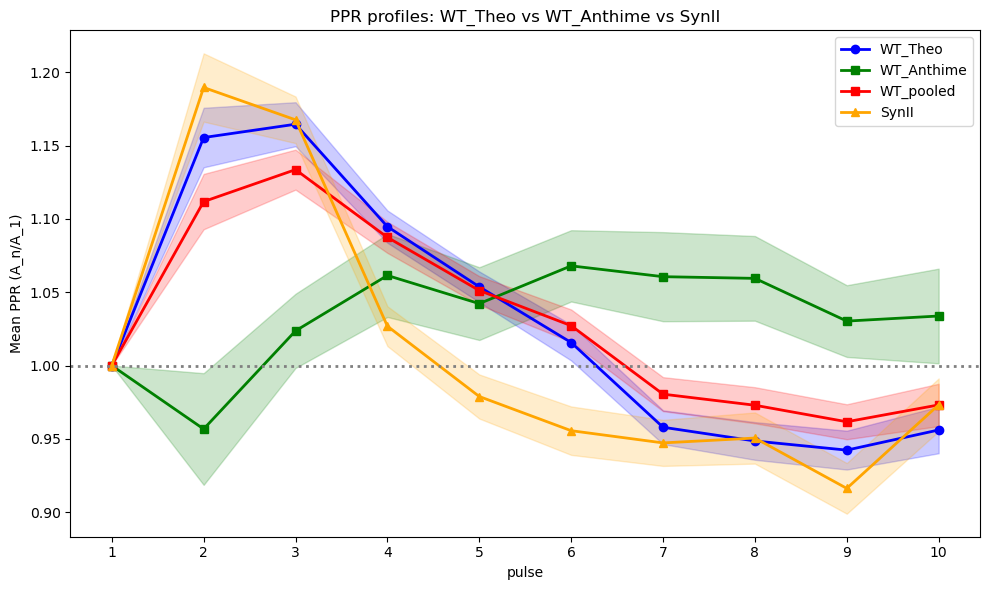

In [6]:
# Plot PPR profiles for WT_Theo and WT_Anthime with SEM
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_Theo.columns]
x_pulses = list(range(1, len(ppr_cols)+2))  # 1 to 10

plt.figure(figsize=(10, 6))

# Calculate means and SEMs for WT_Theo
means_theo = [1] + df_WT_Theo[ppr_cols].mean().tolist()  # pulse 1 is always 1
sems_theo = [0] + df_WT_Theo[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0

# Calculate means and SEMs for WT_Anthime
means_anthime = [1] + df_WT_Anthime[ppr_cols].mean().tolist()  # pulse 1 is always 1
sems_anthime = [0] + df_WT_Anthime[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0

# Calculate means and SEMs for WT_pooled
means_pooled = [1] + df_WT_pooled[ppr_cols].mean().tolist()  # pulse 1 is always 1
sems_pooled = [0] + df_WT_pooled[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0

# Calculate means and SEMs for SynII
means_synii = [1] + df_SynII[ppr_cols].mean().tolist()  # pulse 1 is always 1
sems_synii = [0] + df_SynII[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0

# Plot WT_Theo PPR profile
plt.plot(x_pulses, means_theo, marker='o', label='WT_Theo', color='blue', linewidth=2)
plt.fill_between(x_pulses, np.array(means_theo)-np.array(sems_theo), 
                 np.array(means_theo)+np.array(sems_theo), alpha=0.2, color='blue')

# Plot WT_Anthime PPR profile
plt.plot(x_pulses, means_anthime, marker='s', label='WT_Anthime', color='green', linewidth=2)
plt.fill_between(x_pulses, np.array(means_anthime)-np.array(sems_anthime), 
                 np.array(means_anthime)+np.array(sems_anthime), alpha=0.2, color='green')

# Plot pooled PPR profile
plt.plot(x_pulses, means_pooled, marker='s', label='WT_pooled', color='red', linewidth=2)
plt.fill_between(x_pulses, np.array(means_pooled)-np.array(sems_pooled), 
                 np.array(means_pooled)+np.array(sems_pooled), alpha=0.2, color='red')

# Plot SynII PPR profile
plt.plot(x_pulses, means_synii, marker='^', label='SynII', color='orange', linewidth=2)
plt.fill_between(x_pulses, np.array(means_synii)-np.array(sems_synii), 
                 np.array(means_synii)+np.array(sems_synii), alpha=0.2, color='orange')

plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('Mean PPR (A_n/A_1)')
plt.xlabel('pulse')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.title('PPR profiles: WT_Theo vs WT_Anthime vs SynII')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "1_WT_Theo_vs_Anthime_vs_SynII_PPR_profiles.pdf"))
plt.show()

### 1.C.c Checking the normalized traces
Each traces were cut to be 1scd long, with 0.5scd for the baseline. Since the sampling rate wasn't the same for each condition (from the fastest to the slowest : WT théo [small linescan], SynII [parallel linescan, 4 lines], WT anthime [long parallel linescan, 4 to 6 lines]) it has been decided to downsample everything to a fix value (here 300Hz) so the amplitudes could be on a comparable basis. Indeed, more points could lead to a sharper and taller peak.

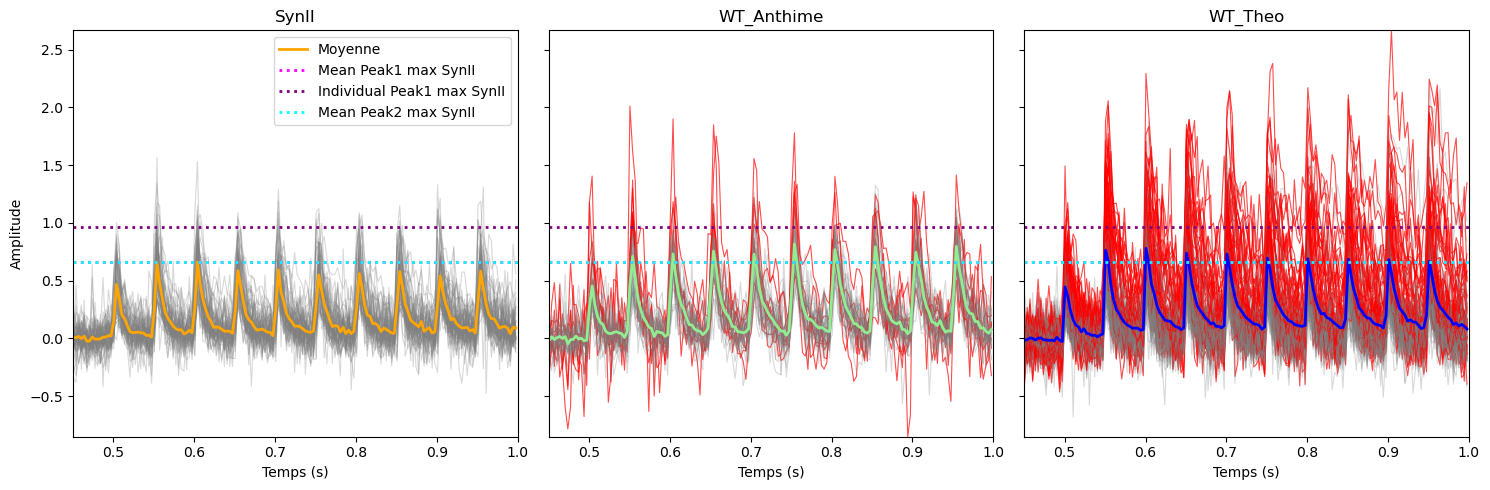


Traces WT_Anthime avec pic > seuil violet (n=9):
  241211_Fibre1_PortionA_bouton10
  241211_Fibre1_PortionA_bouton11
  241211_Fibre1_PortionA_bouton2
  241211_Fibre1_PortionA_bouton4
  241211_Fibre1_PortionA_bouton6
  241211_Fibre1_PortionA_bouton7
  241211_Fibre1_PortionA_bouton8
  241211_Fibre1_PortionA_bouton9
  241212_Fibre1_PortionB_bouton4

Traces WT_Theo avec pic > seuil violet (n=48):
  20190801_linescan1_20Hz_10pulses_2.5mMCa_bouton3
  20190801_linescan1_20Hz_10pulses_2.5mMCa_bouton5
  20190801_linescan1_20Hz_10pulses_2.5mMCa_bouton6
  20210125_linescan1_20Hz_10pulses_2.5mMCa_bouton2
  20210125_linescan3_20Hz_10pulses_2.5mMCa_bouton2
  20210125_linescan3_20Hz_10pulses_2.5mMCa_bouton3
  20210128_linescan1_20Hz_10pulses_2.5mMCa_bouton1
  20210128_linescan1_20Hz_10pulses_2.5mMCa_bouton3
  20210128_linescan2_20Hz_10pulses_2.5mMCa_bouton3
  20210128_linescan2_20Hz_10pulses_2.5mMCa_bouton5
  20210128_linescan4_20Hz_10pulses_2.5mMCa_bouton1
  20210128_linescan4_20Hz_10pulses_2.5mMCa

In [7]:
# Charger les traces
test_SynII = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="SynII")
test_wt_anthime = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="WT_Anthime")
test_wt_theo = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="WT_Theo")

# Extraire le temps
time = test_SynII.iloc[1:, 0].values.astype(float)

# Extraire les traces (toutes sauf la colonne temps)
traces_synii = test_SynII.iloc[1:, 1:].astype(float).values
traces_wt_anthime = test_wt_anthime.iloc[1:, 1:].astype(float).values
traces_wt_theo = test_wt_theo.iloc[1:, 1:].astype(float).values

# Moyennes
mean_synii = np.mean(traces_synii, axis=1)
mean_wt_anthime = np.mean(traces_wt_anthime, axis=1)
mean_wt_theo = np.mean(traces_wt_theo, axis=1)

# Mesure du pic SynII entre 0.5s et 0.53s
mask_peak = (time >= 0.55) & (time <=0.58)
peak_amp_synii = mean_synii[mask_peak].max()

# Mesure du pic le plus haut des traces individuelles de SynII entre 0.5s et 0.53s
peak_synii_individual = np.percentile(traces_synii[mask_peak, :], 98)

# Mesure du pic 2 de la moyenne SynII entre 0.55s et 0.58s
mask_peak2 = (time >= 0.55) & (time <= 0.58)
peak_amp_synii_2 = mean_synii[mask_peak2].max()

# Détermination des bornes globales pour l'échelle
all_traces = np.concatenate([traces_synii, traces_wt_anthime, traces_wt_theo], axis=1)
ymin = np.min(all_traces)
ymax = np.max(all_traces)

# Création de la figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Plot SynII
for trace in traces_synii.T:
    axes[0].plot(time, trace, color='gray', alpha=0.3, linewidth=0.8)
axes[0].plot(time, mean_synii, color='orange', linewidth=2, label='Moyenne')
axes[0].axhline(peak_amp_synii, color='magenta', linestyle='dotted', linewidth=2, label='Mean Peak1 max SynII')
axes[0].axhline(peak_synii_individual, color='purple', linestyle='dotted', linewidth=2, label='Individual Peak1 max SynII')
axes[0].axhline(peak_amp_synii_2, color='cyan', linestyle='dotted', linewidth=2, label='Mean Peak2 max SynII')
axes[0].set_title('SynII')
axes[0].set_ylim(ymin, ymax)
axes[0].set_xlim(0.45, 1.0)
axes[0].legend()

# Plot WT_Anthime
red_traces_anthime = []
for i, trace in enumerate(traces_wt_anthime.T):
    trace_peak = trace[mask_peak].max()
    if trace_peak > peak_synii_individual:
        axes[1].plot(time, trace, color='red', alpha=0.7, linewidth=0.8)
        red_traces_anthime.append(test_wt_anthime.columns[i+1])  # +1 because first column is time
    else:
        axes[1].plot(time, trace, color='gray', alpha=0.3, linewidth=0.8)
axes[1].plot(time, mean_wt_anthime, color='lightgreen', linewidth=2, label='Moyenne')
axes[1].axhline(peak_amp_synii, color='magenta', linestyle='dotted', linewidth=2, label='Mean Peak1 max SynII')
axes[1].axhline(peak_synii_individual, color='purple', linestyle='dotted', linewidth=2, label='Individual Peak1 max SynII')
axes[1].axhline(peak_amp_synii_2, color='cyan', linestyle='dotted', linewidth=2, label='Mean Peak2 max SynII')
axes[1].set_title('WT_Anthime')
axes[1].set_ylim(ymin, ymax)
axes[1].set_xlim(0.45, 1.0)

# Plot WT_Theo
red_traces_theo = []
for i, trace in enumerate(traces_wt_theo.T):
    trace_peak = trace[mask_peak].max()
    if trace_peak > peak_synii_individual:
        axes[2].plot(time, trace, color='red', alpha=0.7, linewidth=0.8)
        red_traces_theo.append(test_wt_theo.columns[i+1])  # +1 because first column is time
    else:
        axes[2].plot(time, trace, color='gray', alpha=0.3, linewidth=0.8)
axes[2].plot(time, mean_wt_theo, color='blue', linewidth=2, label='Moyenne')
axes[2].axhline(peak_amp_synii, color='magenta', linestyle='dotted', linewidth=2, label='Mean Peak1 max SynII')
axes[2].axhline(peak_synii_individual, color='purple', linestyle='dotted', linewidth=2, label='Individual Peak1 max SynII')
axes[2].axhline(peak_amp_synii_2, color='cyan', linestyle='dotted', linewidth=2, label='Mean Peak2 max SynII')
axes[2].set_title('WT_Theo')
axes[2].set_ylim(ymin, ymax)
axes[2].set_xlim(0.45, 1.0)

for ax in axes:
    ax.set_xlabel('Temps (s)')
axes[0].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "2_Traces_SynII_WTAnthime_WTTheo.pdf"))
plt.show()

# Print and save the IDs of traces in red (above purple threshold) and the threshold value
txt_path = os.path.join(output_dir, "2_Traces_SynII_WTAnthime_WTTheo.txt")
with open(txt_path, "w", encoding="utf-8") as f_txt:
    f_txt.write(f"Traces WT_Anthime avec pic > seuil violet (n={len(red_traces_anthime)}):\n")
    for trace_id in red_traces_anthime:
        f_txt.write(f"  {trace_id}\n")
    f_txt.write(f"\nTraces WT_Theo avec pic > seuil violet (n={len(red_traces_theo)}):\n")
    for trace_id in red_traces_theo:
        f_txt.write(f"  {trace_id}\n")
    f_txt.write(f"\nSeuil violet (pic max traces SynII): {peak_synii_individual:.3f}\n")

print(f"\nTraces WT_Anthime avec pic > seuil violet (n={len(red_traces_anthime)}):")
for trace_id in red_traces_anthime:
    print(f"  {trace_id}")

print(f"\nTraces WT_Theo avec pic > seuil violet (n={len(red_traces_theo)}):")
for trace_id in red_traces_theo:
    print(f"  {trace_id}")

print(f"\nSeuil violet (pic max traces SynII): {peak_synii_individual:.3f}")


## 1.D. Prepare data for analyses

In [8]:
#Get rids of the un-used columns for the PCA
df_WT_pooled   = df_WT_pooled.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline', 'Target'], axis=1) 
df_WT_Theo     = df_WT_Theo.drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline', 'Target'], axis=1)
df_WT_Anthime  = df_WT_Anthime.drop(['ID','AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline'], axis=1)
df_SynII       = df_SynII.drop(['ID','AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3', 'STD_baseline'], axis=1)
df_WT_1_5Ca    = df_WT_1_5Ca .drop(['ID', 'AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)
df_WT_4Ca      = df_WT_4Ca.drop(['ID','AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)
df_stab_before = df_stab_before.drop(['ID','AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)
df_stab_after  = df_stab_after.drop(['ID','AMP3','AMP4','AMP5','AMP6','AMP7','AMP8','AMP9','AMP10','%Fail3'], axis=1)

#Extracts labels
labels = df_WT_pooled.columns

## 1.E. PCA preparation

### 1.E.a Normalization

Normalization is essential before applying PCA or UMAP because these algorithms are sensitive to the scale of the variables. If features have different units or variances, those with larger scales can dominate the analysis and distort the results. By standardizing all features to have zero mean and unit variance, we ensure that each variable contributes equally to the dimensionality reduction and clustering steps.

In [9]:
#Creates a standard scaler object to normalize data
scaler = StandardScaler() 

#Fits scaler on df_WT_pooled (for means and std)
scaled_data_WT_pooled = scaler.fit_transform(df_WT_pooled)

#Applies the same scaling to all other datasets. For same feature space for PCA comparison
scaled_data_WT_Theo     = scaler.transform(df_WT_Theo)
scaled_data_WT_Anthime  = scaler.transform(df_WT_Anthime)
scaled_data_SynII       = scaler.transform(df_SynII)
scaled_data_WT_1_5Ca    = scaler.transform(df_WT_1_5Ca)
scaled_data_WT_4Ca      = scaler.transform(df_WT_4Ca)
scaled_data_stab_before = scaler.transform(df_stab_before)
scaled_data_stab_after  = scaler.transform(df_stab_after)

### 1.E.b - PCA construction
PCA is performed on the entire WT_pooled dataset to capture the main axes of variation present in all samples. By using all available data, the principal components reflect the global structure and variability of the dataset, ensuring that the projection is representative and comparable across different experimental groups. PCA is a good choice because it reduces dimensionality while preserving as much variance as possible, making it easier to visualize complex data and identify patterns or clusters. Additionally, PCA provides orthogonal axes (principal components) that are uncorrelated, which simplifies downstream analyses and interpretation.

In [10]:
#Creates a PCA object that reduces the data to 2 principal components
reducer_PCA = PCA(n_components=2)

#Fits the PCA on scaled_data_WT_pooled (learns projection axes)
transformed_data_WT_pooled = reducer_PCA.fit_transform(scaled_data_WT_pooled)

# Projects all other scaled datasets into the same space defined by new_df
transformed_data_WT_Theo     = reducer_PCA.transform(scaled_data_WT_Theo)
transformed_data_WT_Anthime  = reducer_PCA.transform(scaled_data_WT_Anthime)
transformed_data_SynII       = reducer_PCA.transform(scaled_data_SynII)
transformed_data_WT_1_5Ca    = reducer_PCA.transform(scaled_data_WT_1_5Ca)
transformed_data_WT_4Ca      = reducer_PCA.transform(scaled_data_WT_4Ca)
transformed_data_stab_before = reducer_PCA.transform(scaled_data_stab_before)
transformed_data_stab_after  = reducer_PCA.transform(scaled_data_stab_after)

### 1.E.c Organisation

In [11]:
# Create a DataFrame with columns PC1 and PC2
transformed_WT_pooled  = pd.DataFrame(transformed_data_WT_pooled, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_Theo    = pd.DataFrame(transformed_data_WT_Theo, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_Anthime = pd.DataFrame(transformed_data_WT_Anthime, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_SynII      = pd.DataFrame(transformed_data_SynII, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_1_5Ca   = pd.DataFrame(transformed_data_WT_1_5Ca, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_WT_4Ca     = pd.DataFrame(transformed_data_WT_4Ca, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_stab_before = pd.DataFrame(transformed_data_stab_before, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])
transformed_stab_after  = pd.DataFrame(transformed_data_stab_after, columns=[f"PC{i+1}" for i in range(transformed_data_WT_pooled.shape[1])])

### 1.E.d Few checks

In [12]:
print(" explained variance: ", reducer_PCA.explained_variance_ratio_)

 explained variance:  [0.28643318 0.15178991]


In [13]:
#Creates a DataFrame showing how much each original feature contributes to PC1 and PC2.
df_components = pd.DataFrame(reducer_PCA.components_, columns = labels, index = ['PC_1', 'PC_2'])
df_components

,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2,PPR1/1
PC_1,0.227412,0.245584,0.401809,0.262302,0.193578,-0.014179,-0.164164,-0.282078,-0.343005,-0.294738,-0.380064,-0.172265,-0.163306,0.328956
PC_2,0.492445,0.492875,-0.132574,-0.236686,0.015828,0.030959,-0.104746,0.156493,0.244981,0.254407,0.037689,-0.396530,-0.324286,-0.125497


In [14]:
#Concatenates the PCA-transformed data (PC1, PC2) and the original features (new_df) into one table
full_table = pd.concat([transformed_WT_pooled, df_WT_pooled], axis=1, join='inner')

#Computes the correlation matrix between all columns in full_table. Shows how each principal component correlates with the original features
full_table_df = full_table.corr()

#Extracts only the correlations between PC1/PC2 and the original features
coeff_corr = full_table_df.iloc[0:2,2:]
coeff_corr

,AMP1,AMP2,PPR2/1,PPR3/1,PPR4/1,PPR5/1,PPR6/1,PPR7/1,PPR8/1,PPR9/1,PPR10/1,%Fail1,%Fail2,PPR1/1
PC1,0.455396,0.491785,0.804628,0.525264,0.387643,-0.028393,-0.328741,-0.564866,-0.686872,-0.590218,-0.761083,-0.344963,-0.327023,0.658740
PC2,0.717865,0.718492,-0.193261,-0.345031,0.023074,0.045131,-0.152694,0.228129,0.357123,0.370864,0.054942,-0.578044,-0.472730,-0.182944


# 2 - Fig. 4 : Classes of STP and glutamate release properties at GC boutons

## 2.A - PCA visualization

### 2.A.a - Hierarchical clustering on PCA
By performing hierarchical clustering (HC) on the PCA embedding, we can identify clusters that may not be visible in the linear PCA projection. The resulting cluster labels are then projected back onto the PCA space to visualize how these non-linear clusters are distributed in the principal component axes.

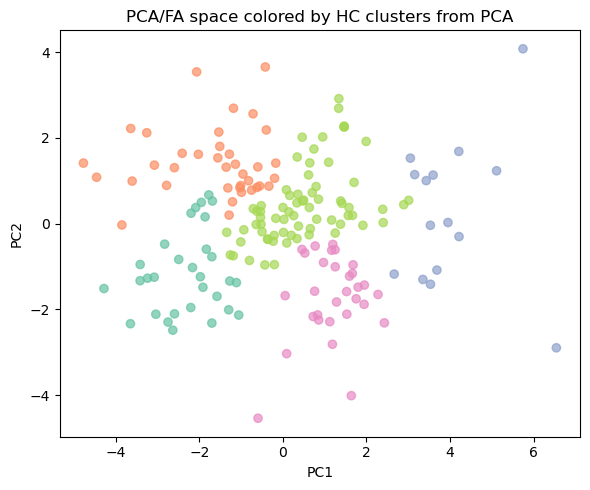

In [15]:
# Perform hierarchical clustering on PCA
n_clust   = 5  # Ensure this matches the chosen number of clusters
Z         = linkage(transformed_data_WT_pooled, method='ward') 
hc_labels = fcluster(Z, n_clust, criterion='maxclust')

# Import again the pooled data for WT and add HC labels 
df_WT_poolclust  = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="WT_pooled")
df_WT_poolclust['HC_UMAP'] = hc_labels

# Use consistent colormap
cmap = cm.get_cmap('Set2')
colors_umap = [cmap(l-1) for l in hc_labels]

# Project HC cluster labels onto PCA/FA space
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(transformed_data_WT_pooled[:, 0], transformed_data_WT_pooled[:, 1], 
                    c=colors_umap, alpha=0.7)

"""
def draw_ellipse(position, covariance, ax, **kwargs):
    #Draw confidence ellipse for cluster visualization
    if covariance.shape == (2, 2):
        # Critical value for 95% confidence with 2 degrees of freedom
        chi2_val = chi2.ppf(0.95, df=2)
        # Singular value decomposition of covariance matrix
        U, s, _ = np.linalg.svd(covariance)
        # Rotation angle of the ellipse
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        # Width and height of the ellipse (principal axes)
        width, height = 2 * np.sqrt(chi2_val * s)
    else:
        # 1D case (shouldn't happen with PC1 and PC2)
        angle = 0
        chi2_val = chi2.ppf(0.95, df=1)
        width, height = 2 * np.sqrt(chi2_val * covariance), 2 * np.sqrt(chi2_val * covariance)
    
    ellipse = Ellipse(position, width, height, angle, **kwargs)
    ax.add_patch(ellipse)

# Add confidence ellipses for each cluster
for cluster_id in range(1, n_clust + 1):
    # Get points belonging to this cluster
    cluster_mask = hc_labels == cluster_id
    cluster_points = transformed_data_WT_pooled[cluster_mask]
    
    if len(cluster_points) > 2:  # Need at least 3 points for covariance
        # Calculate cluster center and covariance
        center = np.mean(cluster_points, axis=0)
        covariance = np.cov(cluster_points.T)
        
        # Draw 95% confidence ellipse
        draw_ellipse(center, covariance, ax, 
                    facecolor=cmap(cluster_id-1), alpha=0.2, 
                    edgecolor=cmap(cluster_id-1), linewidth=2)
"""

ax.set_title('PCA/FA space colored by HC clusters from PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()

#save figure
plt.savefig(os.path.join(output_dir, "3_PCA_pooled.pdf"))

### 2.A.b Dendrogram 

A dendrogram is plotted here to visualize the hierarchical relationships between samples based on their similarity in the consensus UMAP embedding. This tree-like diagram allows us to see how clusters are formed at different levels of similarity, identify distinct groups, and assess the structure and separation of clusters. It provides an intuitive way to explore the results of hierarchical clustering and supports the selection of cluster boundaries for downstream analysis.

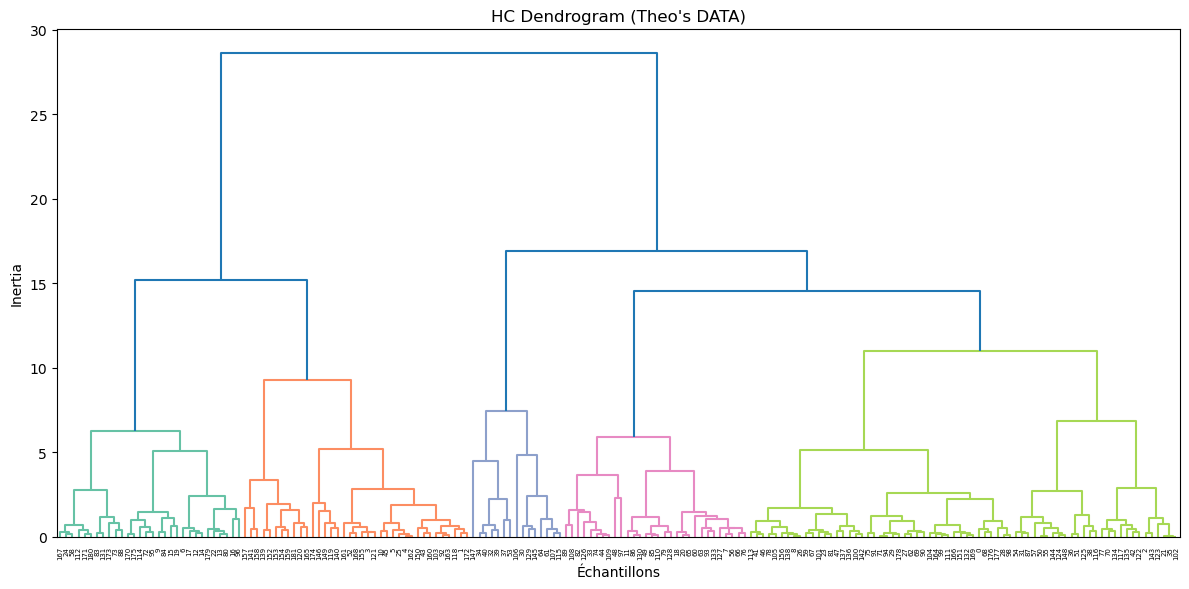

In [16]:
# Use the same colormap and number of clusters as before
cmap = cm.get_cmap('Set2')
hex_colors = [to_hex(cmap(i)) for i in range(n_clust)]
set_link_color_palette(hex_colors)

plt.figure(figsize=(12, 6))
dendrogram(Z, color_threshold=Z[-n_clust+1, 2], labels=transformed_WT_pooled.index.to_list(), leaf_rotation=90, )
plt.title("HC Dendrogram (Theo's DATA)")
plt.xlabel("Échantillons")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "5_HC_Dendrogram.pdf"))

### 2.A.c Biplot PCA
A biplot is used here to visualize both the samples and the variable loadings in the principal component space. This allows us to interpret how each original feature contributes to the first two principal components and to see the relationships between variables and samples simultaneously. By plotting the variable vectors, we can identify which features are most influential in separating the data, and how clusters or trends in the data relate to specific experimental measurements. This enhances the interpretability of the PCA results and helps link biological meaning to the observed patterns.


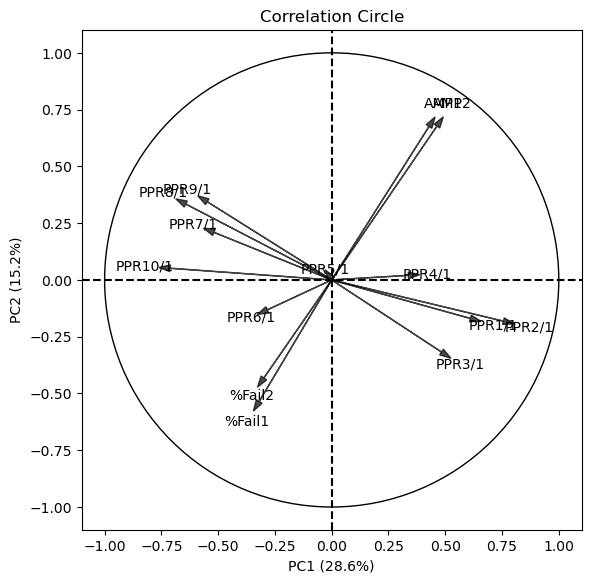

In [17]:
# PCA biplot: Visualize variable contributions to PC1 and PC2
# This uses the PCA object 'reducer' and its components_
# Update biplot to use correlation coefficients instead of loadings
# Get correlation coefficients between PCs and original variables
corr_coef = coeff_corr.T.values
scaling_factor = 1
corr_coef_scaled = corr_coef * scaling_factor

# Create the circle for correlation biplot
circle = plt.Circle((0, 0), 1, color='black', fill=False)
plt.figure(figsize=(6,6))
plt.axhline(0, color='black', linestyle='dashed')
plt.axvline(0, color='black', linestyle='dashed')
plt.gca().add_artist(circle)

# Plot correlation vectors
for i, var in enumerate(df_WT_pooled.columns):
    plt.arrow(0, 0, corr_coef_scaled[i, 0], corr_coef_scaled[i, 1],
              color='black', alpha=0.7, head_width=0.03, head_length=0.05, length_includes_head=True)
    plt.text(corr_coef_scaled[i, 0]*1.08, corr_coef_scaled[i, 1]*1.08, var, ha='center', va='center')

plt.xlabel(f"PC1 ({reducer_PCA.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({reducer_PCA.explained_variance_ratio_[1]*100:.1f}%)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal')
plt.title('Correlation Circle')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "6_correlation_circle.pdf"))
plt.show()

### 2.A.d Control - WT Anthime projection on PCA
To ensure that Anthime's data is well represented among the PCA.

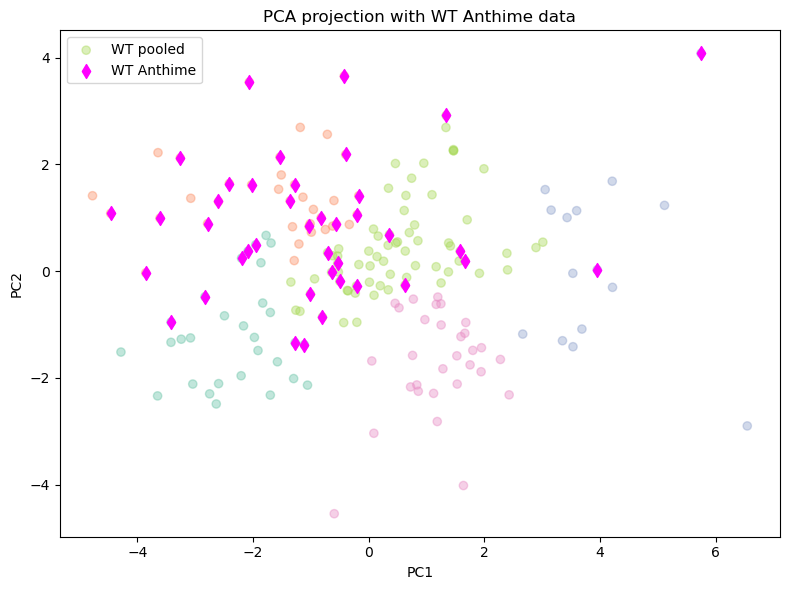

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
plt.scatter(transformed_WT_Anthime['PC1'], transformed_WT_Anthime['PC2'], marker='d', s=50, c='magenta', label='WT Anthime')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection with WT Anthime data')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "7_PCA_WT_Anthime.pdf"))
plt.show()

### 2.A.e BONUS #1 - PCA with PC/IN projected

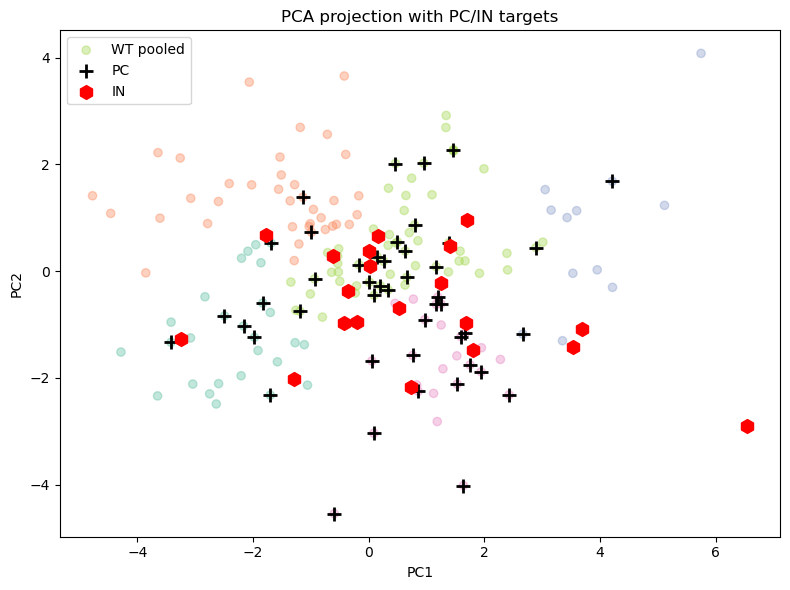

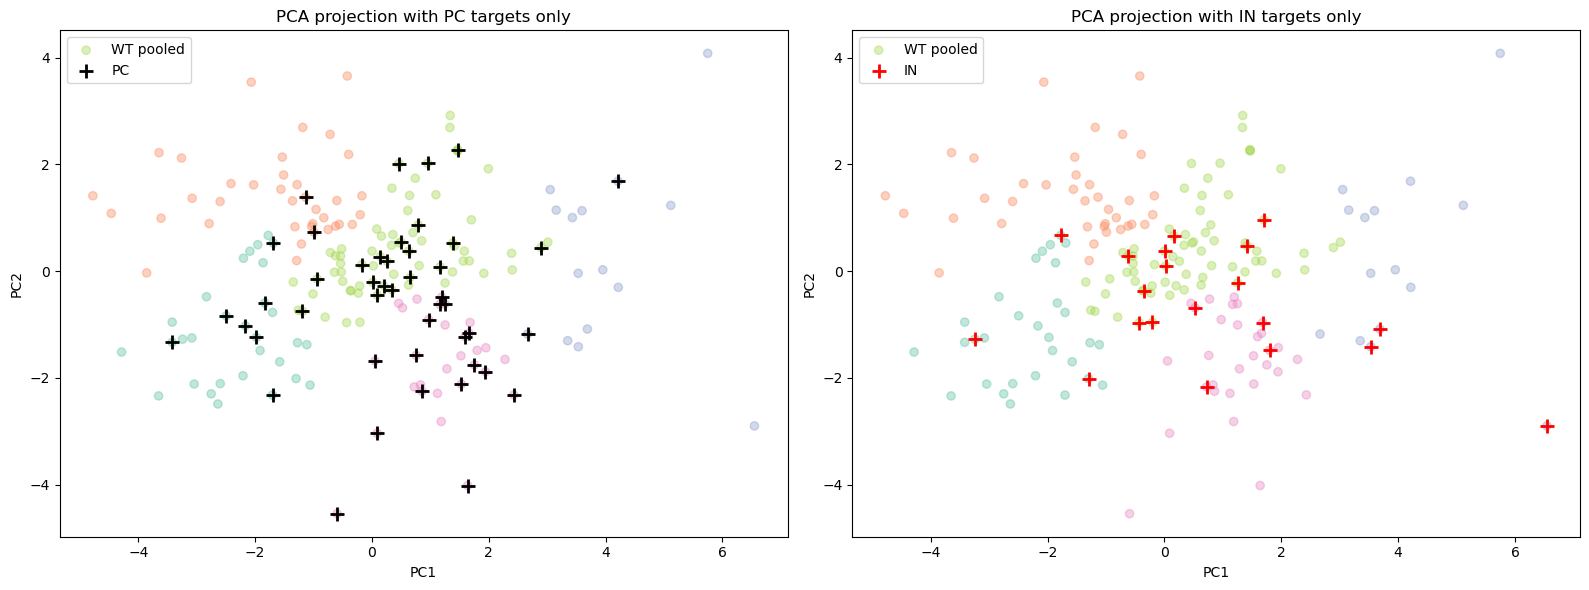

In [19]:
df_WT_Theo    = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="WT_Theo")
# Filter data for PC and IN targets only
pc_data = df_WT_Theo[df_WT_Theo['Target'] == 'PC']
in_data = df_WT_Theo[df_WT_Theo['Target'] == 'IN']

# Get the indices for PC and IN data
pc_indices = pc_data.index
in_indices = in_data.index

# Extract corresponding transformed data
pc_transformed = transformed_data_WT_Theo[pc_indices]
in_transformed = transformed_data_WT_Theo[in_indices]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
plt.scatter(pc_transformed[:, 0], pc_transformed[:, 1], marker='+', s=100, c='black', linewidths=2, label='PC')
plt.scatter(in_transformed[:, 0], in_transformed[:, 1], marker='h', s=100, c='red', label='IN')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection with PC/IN targets')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "8_PCA_PC_IN.pdf"))
plt.show()
# Separate plots for PC and IN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Only PC targets
ax1.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
ax1.scatter(pc_transformed[:, 0], pc_transformed[:, 1], marker='+', s=100, c='black', linewidths=2, label='PC')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('PCA projection with PC targets only')
ax1.legend()

# Plot 2: Only IN targets
ax2.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
ax2.scatter(in_transformed[:, 0], in_transformed[:, 1], marker='+', s=100, c='red', linewidths=2, label='IN')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('PCA projection with IN targets only')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "9_PCA_PC_IN_separate.pdf"))
plt.show()


### 2.A.f Bonus #2- Big amplitude boutons
Here are projected the WT boutons that show a bigger than the biggest Amp1 bouton of SynII.

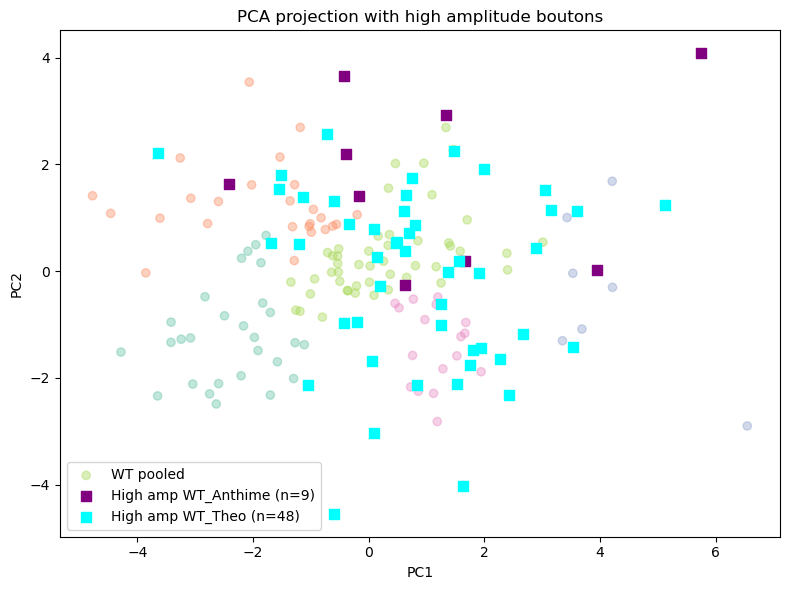

Nombre total de boutons haute amplitude projetés: 57
WT_Anthime: 9 boutons
WT_Theo: 48 boutons


In [20]:
# Get the list of red traces (high amplitude traces) from both WT datasets
red_traces_combined = red_traces_anthime + red_traces_theo

# Extract the corresponding data points from the transformed datasets
high_amp_indices_anthime = []
high_amp_indices_theo = []

# For WT_Anthime - find indices of red traces
for trace_id in red_traces_anthime:
    # Find the column index in the original dataset (subtract 1 because first column is time)
    col_index = list(test_wt_anthime.columns).index(trace_id) - 1
    if col_index >= 0:
        high_amp_indices_anthime.append(col_index)

# For WT_Theo - find indices of red traces  
for trace_id in red_traces_theo:
    # Find the column index in the original dataset (subtract 1 because first column is time)
    col_index = list(test_wt_theo.columns).index(trace_id) - 1
    if col_index >= 0:
        high_amp_indices_theo.append(col_index)

# Extract the corresponding transformed data points
high_amp_anthime_transformed = transformed_data_WT_Anthime[high_amp_indices_anthime]
high_amp_theo_transformed = transformed_data_WT_Theo[high_amp_indices_theo]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')
plt.scatter(high_amp_anthime_transformed[:, 0], high_amp_anthime_transformed[:, 1], 
           marker='s', s=50, c='purple', label=f'High amp WT_Anthime (n={len(high_amp_anthime_transformed)})')
plt.scatter(high_amp_theo_transformed[:, 0], high_amp_theo_transformed[:, 1], 
           marker='s', s=50, c='cyan', label=f'High amp WT_Theo (n={len(high_amp_theo_transformed)})')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection with high amplitude boutons')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "10_PCA_high_amplitude_boutons.pdf"))
plt.show()

print(f"Nombre total de boutons haute amplitude projetés: {len(high_amp_anthime_transformed) + len(high_amp_theo_transformed)}")
print(f"WT_Anthime: {len(high_amp_anthime_transformed)} boutons")
print(f"WT_Theo: {len(high_amp_theo_transformed)} boutons")

## 2.B - Average profile by classes

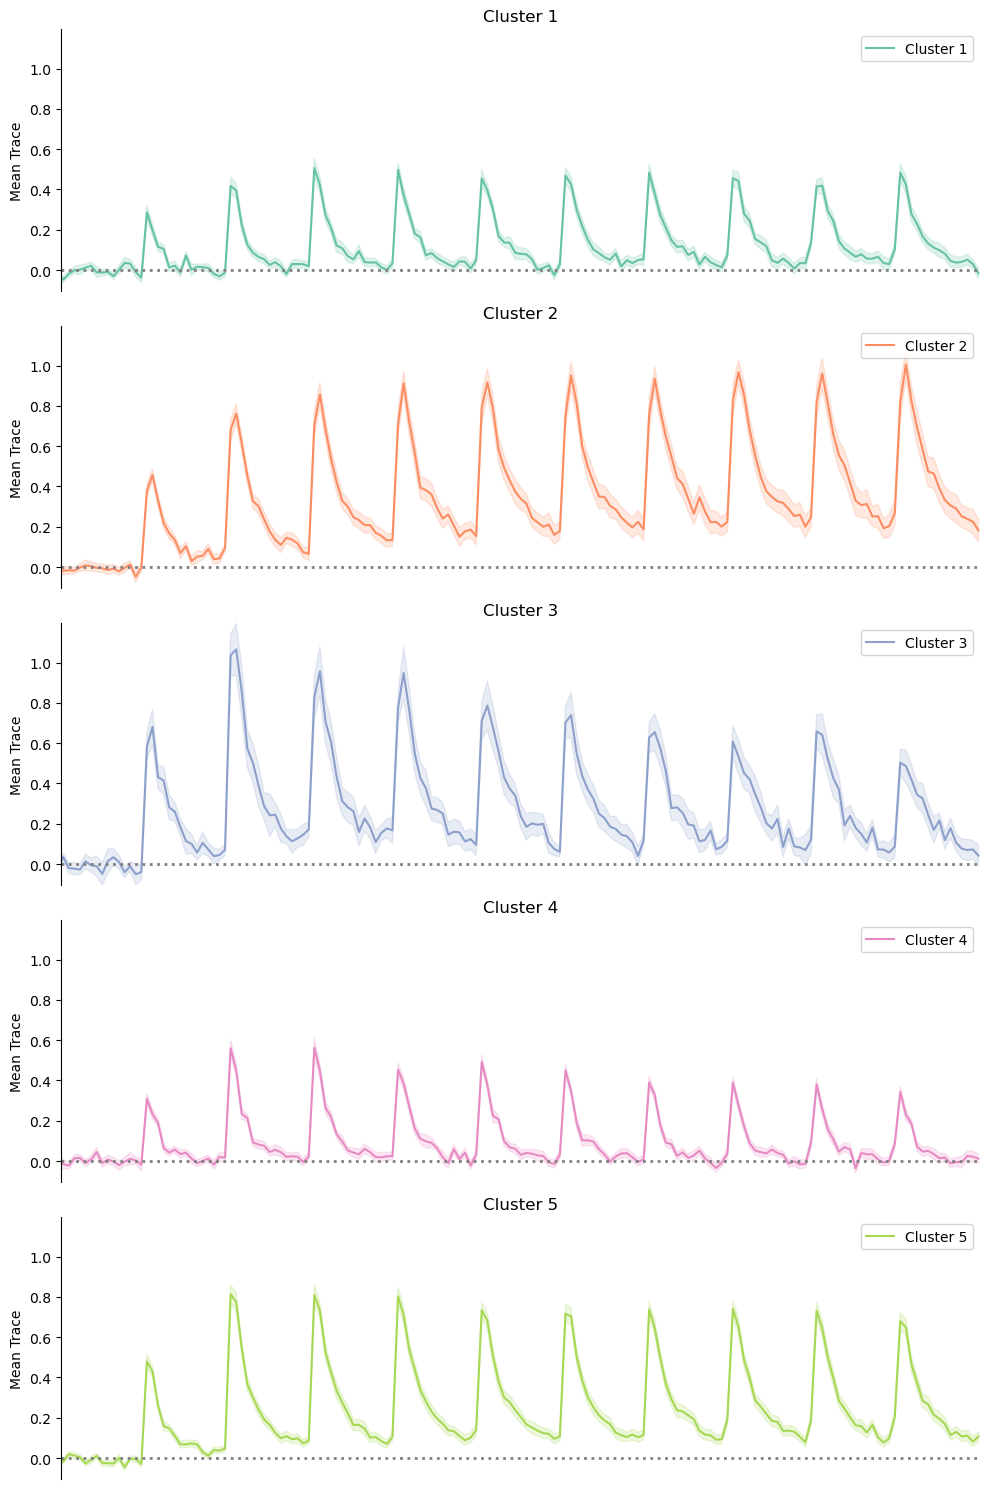

In [21]:
test  = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name=3)

# Extract time from the first column (ignoring the first row if it's an ID)
time = test.iloc[1:, 0].values
trace_ids = test.columns[1:]

# Associate each ID to its cluster via df_WT_poolclust
id_to_cluster = dict(zip(df_WT_poolclust['ID'], df_WT_poolclust['HC_UMAP']))
clusters = sorted(set(id_to_cluster.values()))
cmap = cm.get_cmap('Set2')

# Calculate global y-axis limits across all clusters
all_mean_traces = []
all_sem_traces = []
for cluster in clusters:
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    if len(cluster_ids) > 0:
        traces = test.loc[1:, cluster_ids].astype(float).values
        mean_trace = np.mean(traces, axis=1)
        sem_trace = np.std(traces, axis=1) / np.sqrt(traces.shape[1])
        all_mean_traces.extend(mean_trace)
        all_sem_traces.extend(sem_trace)

# Calculate global y-limits
global_min = np.min(np.array(all_mean_traces) - np.array(all_sem_traces))
global_max = np.max(np.array(all_mean_traces) + np.array(all_sem_traces))

# Create a figure with one subplot per cluster
fig, axes = plt.subplots(len(clusters), 1, figsize=(10, 3*len(clusters)), sharex=True)

# Verification of IDs associated with each cluster
for cluster in sorted(set(id_to_cluster.values())):
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    #print(f"Cluster {cluster}: {cluster_ids}")

plotted = False
for idx, cluster in enumerate(clusters):
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    if len(cluster_ids) > 0:
        traces = test.loc[1:, cluster_ids].astype(float).values
        mean_trace = np.mean(traces, axis=1)
        sem_trace = np.std(traces, axis=1) / np.sqrt(traces.shape[1])
        color = cmap(idx)
        axes[idx].plot(time, mean_trace, color=color, label=f'Cluster {cluster}')
        axes[idx].fill_between(time, mean_trace-sem_trace, mean_trace+sem_trace, color=color, alpha=0.2)
        axes[idx].axhline(0, color='gray', linestyle='dotted', linewidth=2)
        axes[idx].set_ylabel('Mean Trace')
        axes[idx].set_xlim(0.45, 1.0)
        axes[idx].legend(loc='upper right')
        axes[idx].set_title(f'Cluster {cluster}')
        
        # Set consistent y-axis limits for all subplots
        axes[idx].set_ylim(global_min, global_max)
        
        # Remove frame and x-axis
        axes[idx].spines['top'].set_visible(False)
        axes[idx].spines['right'].set_visible(False)
        axes[idx].spines['bottom'].set_visible(False)
        axes[idx].get_xaxis().set_visible(False)
        
        plotted = True
    else:
        axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "11_Traces_clust.pdf"))

if plotted:
    plt.show()
else:
    print('No traces found for any cluster.')



## 2.C - Release properties
Here are ploted the different properties of each classes of boutons.

### 2.C.a PPR profiles

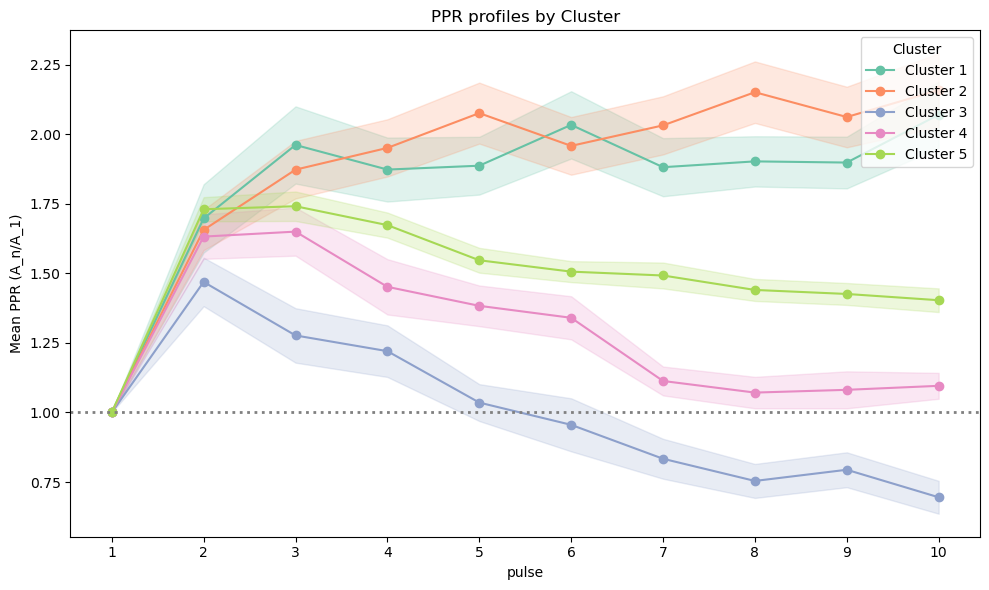

In [22]:
# Plot PPR profiles for each cluster with SEM and custom x-axis, using consistent Set2 colors
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_poolclust.columns]
x_pulses = list(range(1, len(ppr_cols)+2))  # 1 to 10
clusters = sorted(df_WT_poolclust['HC_UMAP'].unique())
cmap = cm.get_cmap('Set2')
plt.figure(figsize=(10, 6))
for idx, cluster in enumerate(clusters):
    cluster_data = df_WT_poolclust[df_WT_poolclust['HC_UMAP'] == cluster]
    means = [1] + cluster_data[ppr_cols].mean().tolist()  # pulse 1 is always 1
    sems = [0] + cluster_data[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0
    color = cmap(idx)
    plt.plot(x_pulses, means, marker='o', label=f'Cluster {cluster}', color=color)
    plt.fill_between(x_pulses, np.array(means)-np.array(sems), np.array(means)+np.array(sems), alpha=0.2, color=color)
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('Mean PPR (A_n/A_1)')
plt.xlabel('pulse')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.title('PPR profiles by Cluster')
plt.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "12_WT_clust_PPR_profiles.pdf"))
plt.show()

### 2.C.b PPR2 (A2/A1)

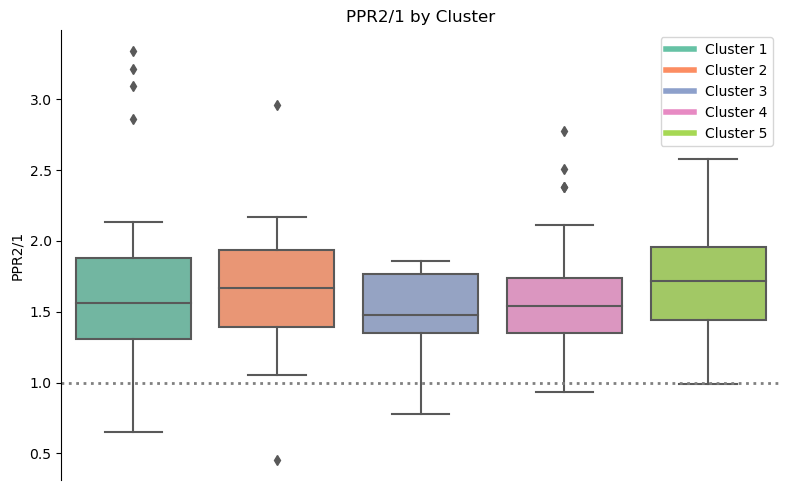

In [23]:
# Create a boxplot for PPR2/1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='PPR2/1', data=df_WT_poolclust, palette='Set2')
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('PPR2/1')
plt.title('PPR2/1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
# Legend with cluster labels
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "13_WT_clust_PPR2_1.pdf"))

### 2.C.c PPR3 (A3/A1)

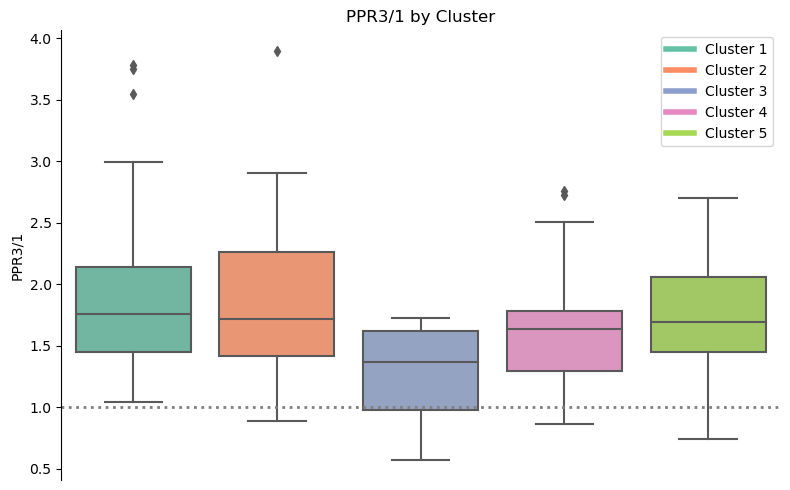

In [24]:
# Create a boxplot for PPR3/1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='PPR3/1', data=df_WT_poolclust, palette='Set2')
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('PPR3/1')
plt.title('PPR3/1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "14_WT_clust_PPR3_1.pdf"))


### AMP1

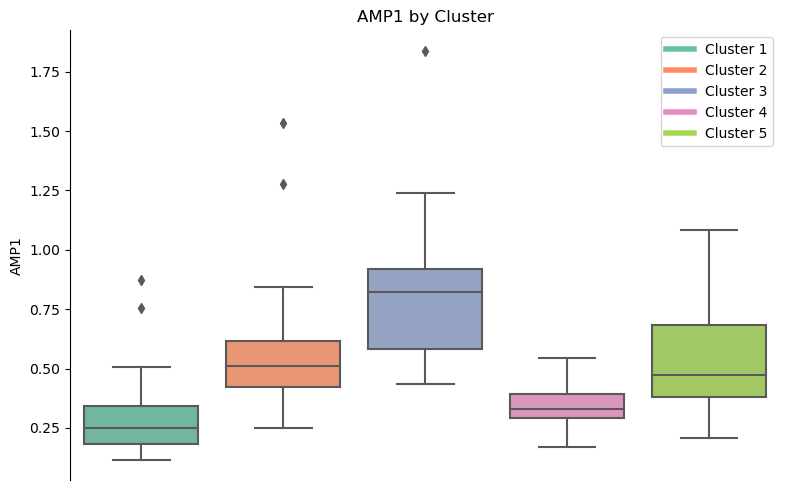

In [25]:
# Create a boxplot for AMP1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='AMP1', data=df_WT_poolclust, palette='Set2')
plt.ylabel('AMP1')
plt.title('AMP1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "15_WT_clust_AMP1.pdf"))

### %Fail1

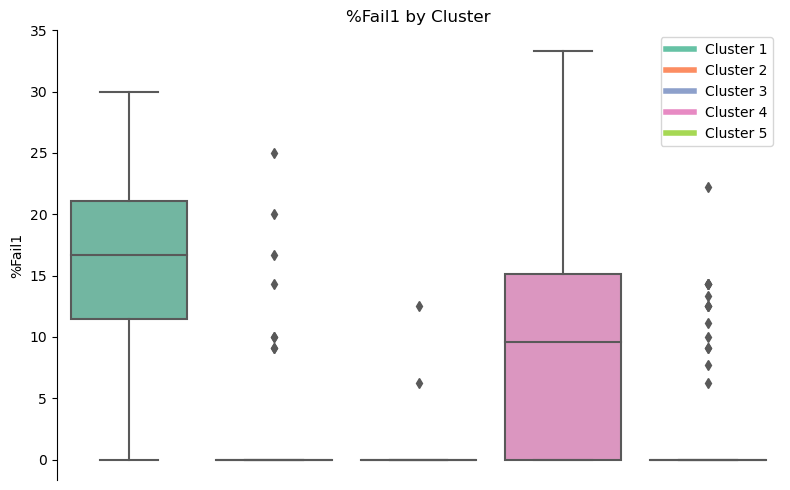

In [26]:
# Create a boxplot for %Fail1 grouped by cluster
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='HC_UMAP', y='%Fail1', data=df_WT_poolclust, palette='Set2')
plt.ylabel('%Fail1')
plt.title('%Fail1 by Cluster')
# Remove x-axis and frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.get_xaxis().set_visible(False)
handles = [plt.Line2D([0], [0], color=cm.get_cmap('Set2')(i), lw=4) for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
labels = [f'Cluster {i+1}' for i in range(df_WT_poolclust['HC_UMAP'].nunique())]
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "16_WT_clust_Fail1.pdf"))

# Figure 2 : SynII
## 1 - Projection des données SynII sur la PCA

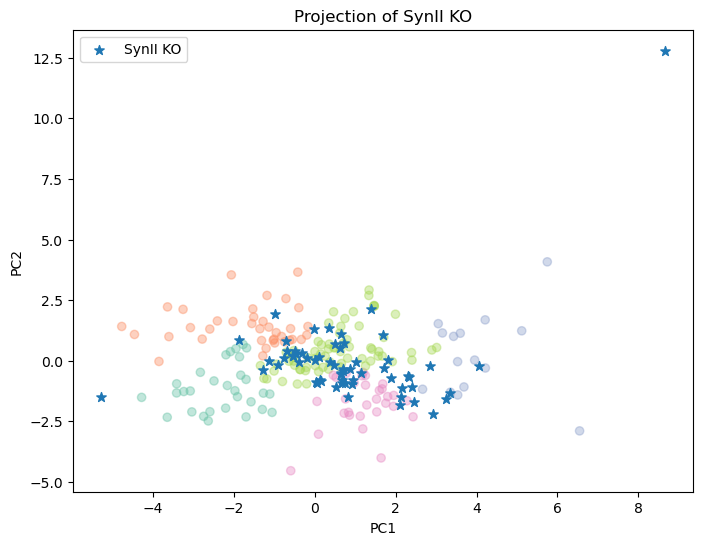

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=.4)
plt.scatter(transformed_SynII['PC1'], transformed_SynII['PC2'],marker='*', s=50, label='SynII KO')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projection of SynII KO')
plt.legend()
plt.show
plt.savefig(os.path.join(output_dir, "17_PCA_synII.pdf"))

# 2 - Proportion de SynII dans les clusters WT
## Proportion of SynII in WT Clusters

This analysis explores the distribution of SynII knockout data points across the clusters previously identified in wild-type (WT) samples. 

The visualization in the previous cell reveals that SynII knockout boutons have a distinct distribution pattern among the five functional classes identified in WT boutons. This suggests that the absence of Synapsin II alters specific aspects of synaptic transmission, potentially affecting some functional clusters more than others.

The bar chart compares the percentage of boutons belonging to each cluster between WT and SynII samples, highlighting shifts in the functional profile caused by the Synapsin II knockout. This comparison helps identify which specific functional classes of synaptic transmission are most affected by the loss of Synapsin II.

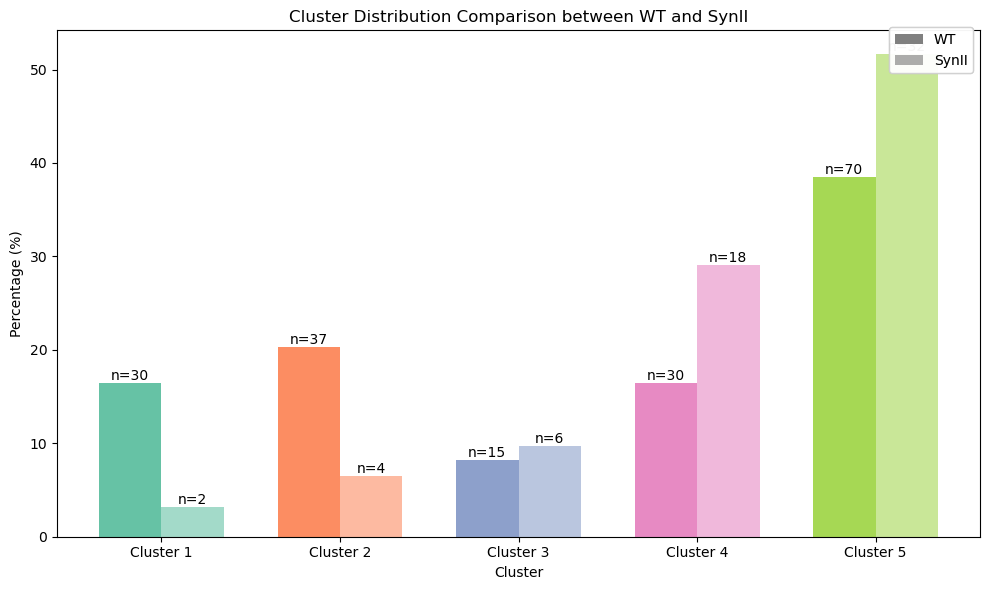

Cluster distribution in WT samples:
Cluster 1: 16.5% (n=30)
Cluster 2: 20.3% (n=37)
Cluster 3: 8.2% (n=15)
Cluster 4: 16.5% (n=30)
Cluster 5: 38.5% (n=70)

Cluster distribution in SynII samples:
Cluster 1: 3.2% (n=2)
Cluster 2: 6.5% (n=4)
Cluster 3: 9.7% (n=6)
Cluster 4: 29.0% (n=18)
Cluster 5: 51.6% (n=32)


In [28]:
from scipy.spatial.distance import cdist
import numpy as np

def assign_clusters_robust(X_existing, labels_existing, X_new, method='centroid'):
    unique_labels = np.unique(labels_existing)
    assigned_labels = []

    if method == 'centroid':
        # Compute centroids of existing clusters
        centroids = np.array([X_existing[labels_existing == label].mean(axis=0) for label in unique_labels])
        # Assign each new point to the nearest centroid
        distances = cdist(X_new, centroids)
        assigned_labels = unique_labels[np.argmin(distances, axis=1)]

    elif method == 'single':
        for x in X_new:
            min_dist = float('inf')
            best_label = None
            for label in unique_labels:
                cluster_points = X_existing[labels_existing == label]
                dist = np.min(cdist([x], cluster_points))
                if dist < min_dist:
                    min_dist = dist
                    best_label = label
            assigned_labels.append(best_label)

    elif method == 'average':
        for x in X_new:
            best_label = None
            best_dist = float('inf')
            for label in unique_labels:
                cluster_points = X_existing[labels_existing == label]
                dist = np.mean(cdist([x], cluster_points))
                if dist < best_dist:
                    best_dist = dist
                    best_label = label
            assigned_labels.append(best_label)

    return np.array(assigned_labels)

clusters_SynII = assign_clusters_robust(transformed_data_WT_pooled, hc_labels, transformed_data_SynII, method='single')

# Calculate counts and percentages for both datasets
wt_counts = pd.Series(hc_labels).value_counts().sort_index()
wt_counts = pd.DataFrame({
    'Cluster': wt_counts.index,
    'Count': wt_counts.values,
    'Percentage': 100 * wt_counts.values / len(hc_labels),
    'Dataset': 'WT'
})

# Ensure all clusters are represented in synii_counts
all_clusters = range(1, n_clust + 1)
synii_counts_series = pd.Series(clusters_SynII).value_counts()
synii_counts = pd.DataFrame({
    'Cluster': all_clusters,
    'Count': [synii_counts_series.get(c, 0) for c in all_clusters],
    'Percentage': [100 * synii_counts_series.get(c, 0) / len(clusters_SynII) for c in all_clusters],
    'Dataset': 'SynII'
})
synii_counts = synii_counts.sort_values('Cluster').reset_index(drop=True)

# Create figure and axis objects
plt.figure(figsize=(10, 6))

# Create color palette for clusters using Set2
cmap = cm.get_cmap('Set2')
n_clusters = len(wt_counts)
cluster_colors = [cmap(i) for i in range(n_clusters)]

# Setup for grouped bar plot
bar_width = 0.35
x = np.arange(n_clusters)

# Plot WT bars - solid colors
bars_wt = plt.bar(x - bar_width/2, wt_counts['Percentage'], bar_width,
                  label='WT', color=cluster_colors)

# Plot SynII bars - same colors but transparent
bars_synii = plt.bar(x + bar_width/2, synii_counts['Percentage'], bar_width,
                     label='SynII', color=cluster_colors, alpha=0.6)

# Add count labels on the bars
for bars, counts in [(bars_wt, wt_counts), (bars_synii, synii_counts)]:
    for bar, count in zip(bars, counts['Count']):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                f'n={int(count)}',
                ha='center', va='bottom')

plt.title('Cluster Distribution Comparison between WT and SynII')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.xticks(x, [f'Cluster {i}' for i in wt_counts['Cluster']])

# Add dataset type legend
wt_patch = plt.Rectangle((0,0),1,1, fc='gray')
synii_patch = plt.Rectangle((0,0),1,1, fc='gray', alpha=0.6)
l1 = plt.legend([wt_patch, synii_patch], ['WT', 'SynII'], 
                loc='upper right', bbox_to_anchor=(1, 1.02))
plt.gca().add_artist(l1)


plt.tight_layout()
plt.savefig(os.path.join(output_dir, "18_WT_SynII_cluster_comparison.pdf"))
plt.show()

# Print the distribution summary
print("Cluster distribution in WT samples:")
for i, row in wt_counts.iterrows():
    print(f"Cluster {row['Cluster']}: {row['Percentage']:.1f}% (n={int(row['Count'])})")

print("\nCluster distribution in SynII samples:")
for i, row in synii_counts.iterrows():
    print(f"Cluster {row['Cluster']}: {row['Percentage']:.1f}% (n={int(row['Count'])})")


### Other representation

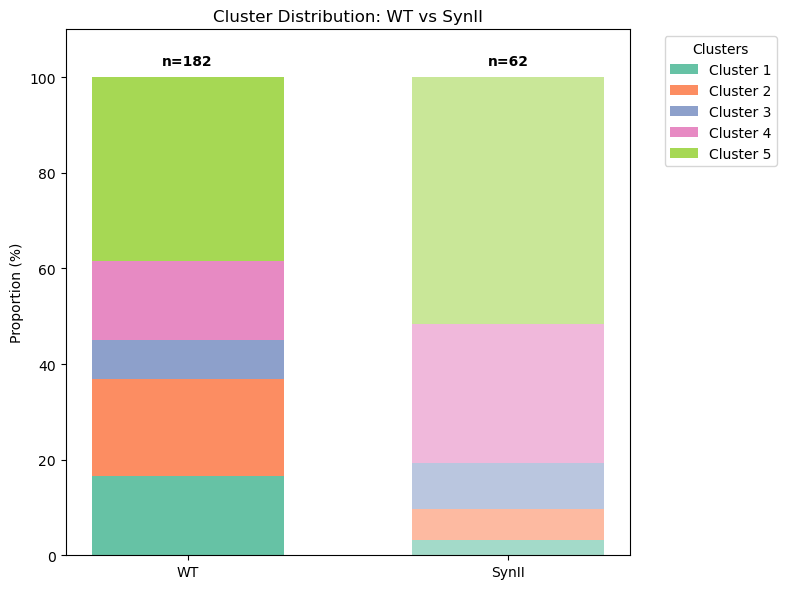

In [29]:
# Create a normalized stacked bar plot showing proportion of each cluster within WT and SynII
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate proportions for each dataset
wt_proportions = wt_counts['Percentage'].values
synii_proportions = synii_counts['Percentage'].values

# Create stacked bars for WT and SynII
datasets = ['WT', 'SynII']
proportions = [wt_proportions, synii_proportions]
bar_width = 0.6

# Use Set2 colormap for clusters
cmap = cm.get_cmap('Set2')
n_clusters = len(wt_counts)

# Create stacked bars
bottom_wt = 0
bottom_synii = 0

for i in range(n_clusters):
    cluster_color = cmap(i)
    
    # WT bar
    ax.bar(0, wt_proportions[i], bar_width, bottom=bottom_wt, 
           color=cluster_color, label=f'Cluster {i+1}')
    bottom_wt += wt_proportions[i]
    
    # SynII bar
    ax.bar(1, synii_proportions[i], bar_width, bottom=bottom_synii, 
           color=cluster_color, alpha=0.6)
    bottom_synii += synii_proportions[i]

# Add count labels on bars
for i, (dataset, counts) in enumerate(zip(['WT', 'SynII'], [wt_counts, synii_counts])):
    total_count = counts['Count'].sum()
    ax.text(i, 102, f'n={total_count}', ha='center', va='bottom', fontweight='bold')

# Customize plot
ax.set_ylabel('Proportion (%)')
ax.set_title('Cluster Distribution: WT vs SynII')
ax.set_xticks([0, 1])
ax.set_xticklabels(['WT', 'SynII'])
ax.set_ylim(0, 110)
ax.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "19_stacked_bar_WT_SynII_normalized.pdf"))
plt.show()

## 3 - Means values of the different parameters

In [30]:
# Calculate mean ± SD for Amp1, Amp2, and %Fail1 in SynII data
print("Mean ± SD for SynII data:")
print(f"AMP1: {df_SynII['AMP1'].mean():.3f} ± {df_SynII['AMP1'].std():.3f}")
print(f"AMP2: {df_SynII['AMP2'].mean():.3f} ± {df_SynII['AMP2'].std():.3f}")
print(f"%Fail1: {df_SynII['%Fail1'].mean():.3f} ± {df_SynII['%Fail1'].std():.3f}")

Mean ± SD for SynII data:
AMP1: 0.536 ± 0.736
AMP2: 0.650 ± 0.371
%Fail1: 0.842 ± 3.946


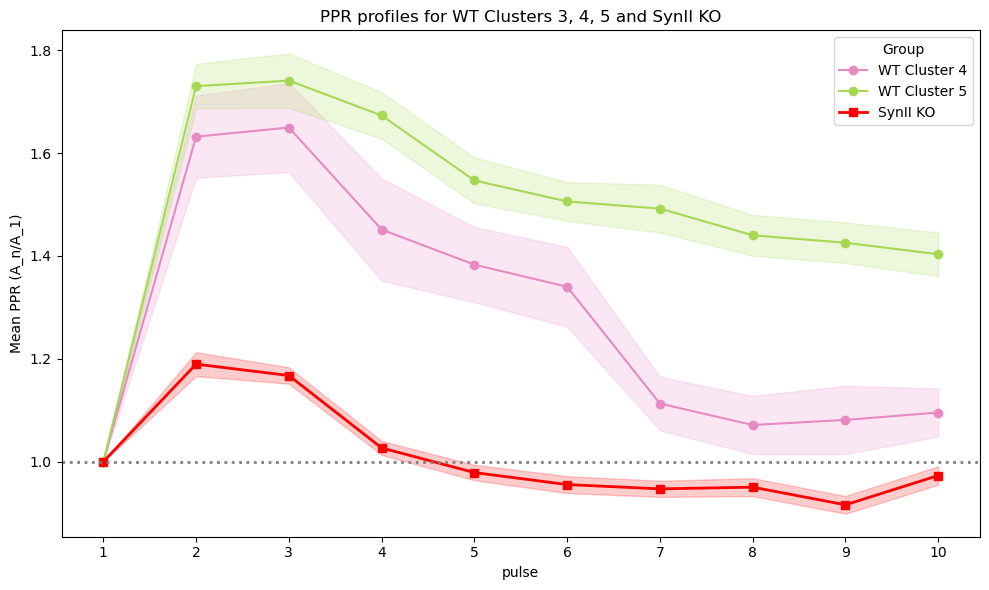

In [31]:
# Plot PPR profiles for clusters 3, 4, and 5 only
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_poolclust.columns]
x_pulses = list(range(1, len(ppr_cols)+2))  # 1 to 10
selected_clusters = [4, 5]
cmap = cm.get_cmap('Set2')

plt.figure(figsize=(10, 6))

# Plot WT clusters 3, 4, and 5
for cluster in selected_clusters:
    cluster_data = df_WT_poolclust[df_WT_poolclust['HC_UMAP'] == cluster]
    means = [1] + cluster_data[ppr_cols].mean().tolist()  # pulse 1 is always 1
    sems = [0] + cluster_data[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0
    color = cmap(cluster-1)  # Use cluster-1 for proper color indexing
    plt.plot(x_pulses, means, marker='o', label=f'WT Cluster {cluster}', color=color)
    plt.fill_between(x_pulses, np.array(means)-np.array(sems), np.array(means)+np.array(sems), alpha=0.2, color=color)

# Add SynII data
synii_means = [1] + df_SynII[ppr_cols].mean().tolist()  # pulse 1 is always 1
synii_sems = [0] + df_SynII[ppr_cols].sem().tolist()    # SEM for pulse 1 is 0
plt.plot(x_pulses, synii_means, marker='s', label='SynII KO', color='red', linewidth=2)
plt.fill_between(x_pulses, np.array(synii_means)-np.array(synii_sems), np.array(synii_means)+np.array(synii_sems), alpha=0.2, color='red')

plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.ylabel('Mean PPR (A_n/A_1)')
plt.xlabel('pulse')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.title('PPR profiles for WT Clusters 3, 4, 5 and SynII KO')
plt.legend(title='Group', loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "20_WT_clust_345_SynII_PPR_profiles.pdf"))
plt.show()

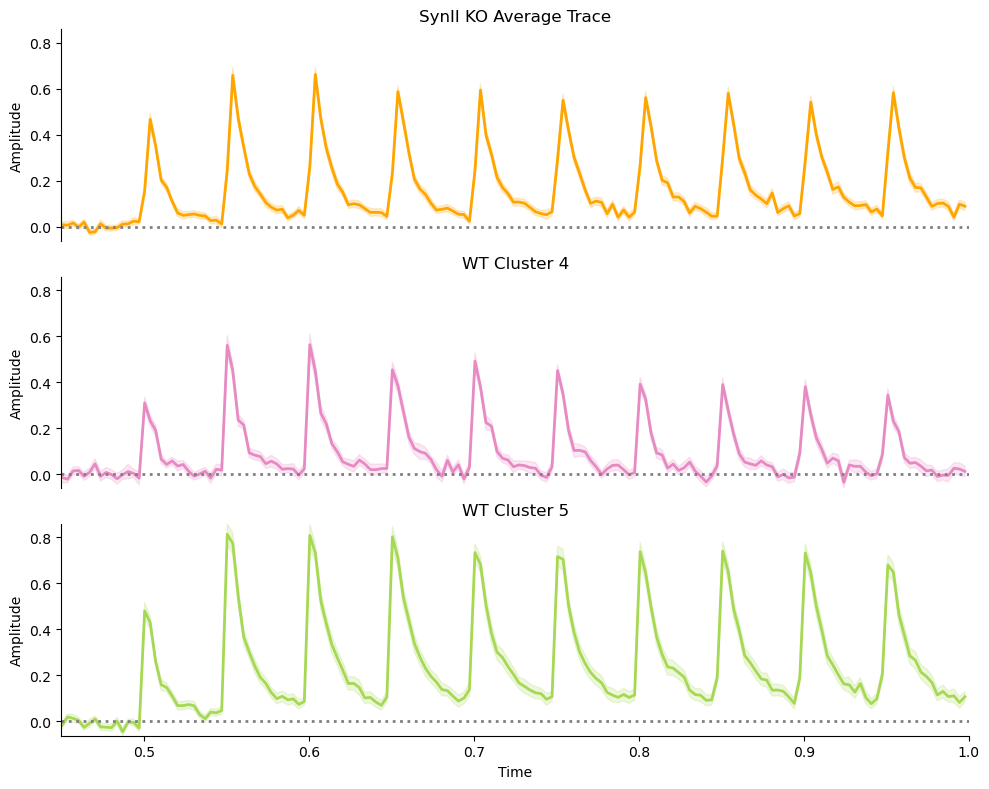

In [32]:
# Load SynII trace data
test_SynII = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name=0)
test_wt = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name=3)

# Extract time from the first column
time = test_SynII.iloc[1:, 0].values

# SynII traces
synii_trace_data = test_SynII.iloc[1:, 1:].astype(float).values
synii_mean_trace = np.mean(synii_trace_data, axis=1)
synii_sem_trace = np.std(synii_trace_data, axis=1) / np.sqrt(synii_trace_data.shape[1])

# Calculate peak amplitude for purple line (between 0.5s and 0.53s)
mask_peak = (time >= 0.5) & (time <= 0.53)
peak_amp_individual = synii_trace_data[mask_peak, :].max()

# WT cluster traces
trace_ids = test_wt.columns[1:]
id_to_cluster = dict(zip(df_WT_poolclust['ID'], df_WT_poolclust['HC_UMAP']))
selected_clusters = [4, 5]
cmap = cm.get_cmap('Set2')

# Calculate cluster traces
cluster_traces = {}
for cluster in selected_clusters:
    cluster_ids = [id for id in trace_ids if id_to_cluster.get(id) == cluster]
    if len(cluster_ids) > 0:
        traces = test_wt.loc[1:, cluster_ids].astype(float).values
        mean_trace = np.mean(traces, axis=1)
        sem_trace = np.std(traces, axis=1) / np.sqrt(traces.shape[1])
        cluster_traces[cluster] = {'mean': mean_trace, 'sem': sem_trace}

# Calculate global y-limits for consistent scaling
all_means = [synii_mean_trace]
all_sems = [synii_sem_trace]
for cluster_data in cluster_traces.values():
    all_means.append(cluster_data['mean'])
    all_sems.append(cluster_data['sem'])

all_means_flat = np.concatenate(all_means)
all_sems_flat = np.concatenate(all_sems)
global_min = np.min(all_means_flat - all_sems_flat)
global_max = np.max(all_means_flat + all_sems_flat)

# Create subplots: SynII on top, WT clusters below
fig, axes = plt.subplots(len(selected_clusters) + 1, 1, figsize=(10, 8), sharex=True)

# Plot SynII trace (top subplot)
axes[0].plot(time, synii_mean_trace, color='orange', linewidth=2, label='SynII KO')
axes[0].fill_between(time, synii_mean_trace-synii_sem_trace, synii_mean_trace+synii_sem_trace, 
                     color='orange', alpha=0.2)
axes[0].axhline(0, color='gray', linestyle='dotted', linewidth=2)
axes[0].set_ylabel('Amplitude')
axes[0].set_title('SynII KO Average Trace')
axes[0].set_xlim(0.45, 1.0)
axes[0].set_ylim(global_min, global_max)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].get_xaxis().set_visible(False)

# Plot WT cluster traces (bottom subplots)
for idx, cluster in enumerate(selected_clusters):
    ax_idx = idx + 1
    if cluster in cluster_traces:
        cluster_data = cluster_traces[cluster]
        color = cmap(cluster-1)
        axes[ax_idx].plot(time, cluster_data['mean'], color=color, linewidth=2, 
                         label=f'WT Cluster {cluster}')
        axes[ax_idx].fill_between(time, cluster_data['mean']-cluster_data['sem'], 
                                 cluster_data['mean']+cluster_data['sem'], 
                                 color=color, alpha=0.2)
        axes[ax_idx].axhline(0, color='gray', linestyle='dotted', linewidth=2)
        axes[ax_idx].set_ylabel('Amplitude')
        axes[ax_idx].set_title(f'WT Cluster {cluster}')
        axes[ax_idx].set_xlim(0.45, 1.0)
        axes[ax_idx].set_ylim(global_min, global_max)
        axes[ax_idx].spines['top'].set_visible(False)
        axes[ax_idx].spines['right'].set_visible(False)
        
        # Only show x-axis on the last subplot
        if idx < len(selected_clusters) - 1:
            axes[ax_idx].spines['bottom'].set_visible(False)
            axes[ax_idx].get_xaxis().set_visible(False)
        else:
            axes[ax_idx].set_xlabel('Time')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "21_SynII_vs_WT_clusters_345_traces.pdf"))
plt.show()

# Figure 3 : Diversité sur une même fibre
## 1 - Barplot of the proportion of PFs displaying 1 to 4 classes of boutons

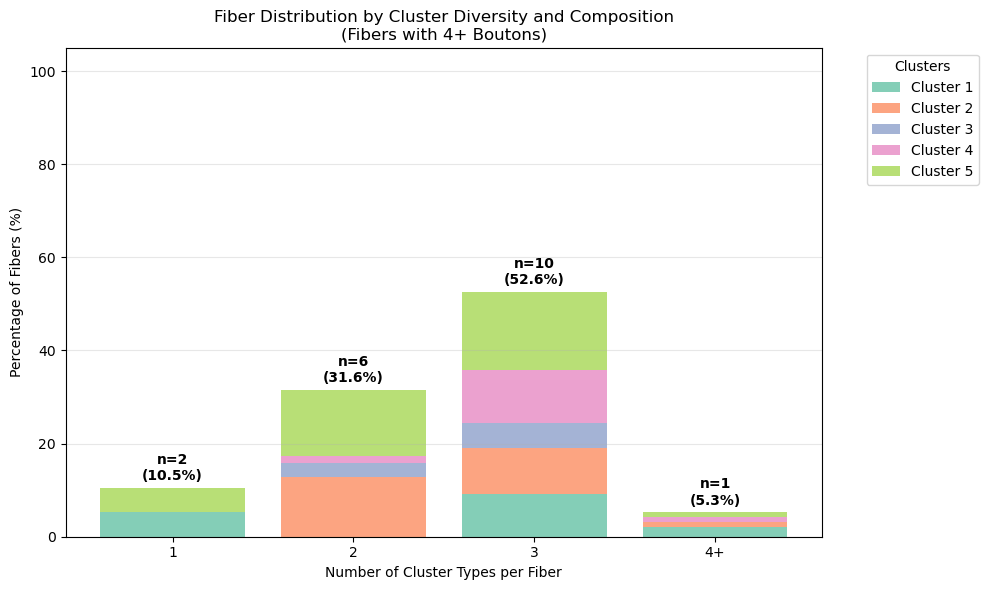

Fiber cluster diversity composition summary (fibers with 4+ boutons only):

Fibers with 1 cluster type(s): 2 fibers (10.5%)
  Cluster 1: 50.0% average proportion (1.0 fiber-equivalents)
  Cluster 5: 50.0% average proportion (1.0 fiber-equivalents)

Fibers with 2 cluster type(s): 6 fibers (31.6%)
  Cluster 2: 40.5% average proportion (2.4 fiber-equivalents)
  Cluster 3: 10.0% average proportion (0.6 fiber-equivalents)
  Cluster 4: 4.2% average proportion (0.2 fiber-equivalents)
  Cluster 5: 45.4% average proportion (2.7 fiber-equivalents)

Fibers with 3 cluster type(s): 10 fibers (52.6%)
  Cluster 1: 17.4% average proportion (1.7 fiber-equivalents)
  Cluster 2: 18.8% average proportion (1.9 fiber-equivalents)
  Cluster 3: 10.1% average proportion (1.0 fiber-equivalents)
  Cluster 4: 22.0% average proportion (2.2 fiber-equivalents)
  Cluster 5: 31.8% average proportion (3.2 fiber-equivalents)

Fibers with 4+ cluster type(s): 1 fibers (5.3%)
  Cluster 1: 40.0% average proportion (0.4 fibe

In [33]:
# Extract fiber ID from the full ID (first 22 characters)
df_WT_poolclust['Fiber_ID'] = df_WT_poolclust['ID'].str[:22]

# Count total number of boutons per fiber
fiber_bouton_counts = df_WT_poolclust.groupby('Fiber_ID').size().reset_index(name='Bouton_Count')

# Filter to keep only fibers with 4 or more boutons
fibers_with_enough_boutons = fiber_bouton_counts[fiber_bouton_counts['Bouton_Count'] >= 4]['Fiber_ID'].tolist()
df_filtered = df_WT_poolclust[df_WT_poolclust['Fiber_ID'].isin(fibers_with_enough_boutons)]

# Count number of different clusters per fiber
fiber_cluster_diversity = df_filtered.groupby('Fiber_ID')['HC_UMAP'].nunique().reset_index()
fiber_cluster_diversity.columns = ['Fiber_ID', 'Num_Cluster_Types']

# Add bouton count information
fiber_cluster_diversity = fiber_cluster_diversity.merge(
    fiber_bouton_counts, on='Fiber_ID', how='left'
)

# Categorize fibers by number of cluster types (cap at 4+)
fiber_cluster_diversity['Cluster_Diversity'] = fiber_cluster_diversity['Num_Cluster_Types'].apply(
    lambda x: f'{x}' if x <= 3 else '4+'
)

# Calculate cluster distribution for each diversity category
diversity_cluster_data = {}
for fiber_id in df_filtered['Fiber_ID'].unique():
    fiber_data = df_filtered[df_filtered['Fiber_ID'] == fiber_id]
    num_clusters = len(fiber_data['HC_UMAP'].unique())
    diversity_key = str(num_clusters) if num_clusters <= 3 else '4+'
    
    if diversity_key not in diversity_cluster_data:
        diversity_cluster_data[diversity_key] = []
    
    # Count clusters for this fiber
    cluster_counts = fiber_data['HC_UMAP'].value_counts()
    total_boutons = len(fiber_data)
    cluster_props = {cluster: count/total_boutons for cluster, count in cluster_counts.items()}
    diversity_cluster_data[diversity_key].append(cluster_props)

# Calculate average proportions and absolute counts for each cluster in each diversity category
diversity_order = ['1', '2', '3', '4+']
cmap = cm.get_cmap('Set2')
n_clusters_total = 5  # Total number of clusters

# Calculate mean proportions and fiber counts
diversity_means = {}
diversity_counts = {}
total_fibers = len(fiber_cluster_diversity)

for diversity in diversity_order:
    if diversity in diversity_cluster_data:
        diversity_counts[diversity] = len(diversity_cluster_data[diversity])
        cluster_means = {}
        for cluster in range(1, n_clusters_total + 1):
            proportions = [fiber_data.get(cluster, 0) for fiber_data in diversity_cluster_data[diversity]]
            cluster_means[cluster] = np.mean(proportions)
        diversity_means[diversity] = cluster_means
    else:
        diversity_counts[diversity] = 0
        diversity_means[diversity] = {cluster: 0 for cluster in range(1, n_clusters_total + 1)}

# Create stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))

x_positions = np.arange(len(diversity_order))
bottom = np.zeros(len(diversity_order))

# Create stacked bars with cluster colors - height = percentage of fibers * proportion
for cluster in range(1, n_clusters_total + 1):
    # Calculate percentage values: (number of fibers / total fibers) * 100 * proportion of that cluster
    percentage_values = [(diversity_counts[div] / total_fibers) * 100 * diversity_means[div][cluster] for div in diversity_order]
    bars = ax.bar(x_positions, percentage_values, bottom=bottom, 
                  color=cmap(cluster-1), label=f'Cluster {cluster}', alpha=0.8)
    bottom += percentage_values

# Add count and percentage labels on top of bars
for i, (diversity, count) in enumerate(zip(diversity_order, [diversity_counts[d] for d in diversity_order])):
    percentage_total = (count / total_fibers) * 100
    ax.text(i, percentage_total + 1, f'n={count}\n({percentage_total:.1f}%)', 
            ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Number of Cluster Types per Fiber')
ax.set_ylabel('Percentage of Fibers (%)')
ax.set_title('Fiber Distribution by Cluster Diversity and Composition\n(Fibers with 4+ Boutons)')
ax.set_xticks(x_positions)
ax.set_xticklabels(diversity_order)
ax.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Set y-axis to start at 0 and go to 100%
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "22_fiber_cluster_diversity_composition_4plus_boutons.pdf"))
plt.show()

# Print detailed summary statistics
print("Fiber cluster diversity composition summary (fibers with 4+ boutons only):")
for diversity in diversity_order:
    if diversity in diversity_counts and diversity_counts[diversity] > 0:
        percentage_of_total = (diversity_counts[diversity] / total_fibers) * 100
        print(f"\nFibers with {diversity} cluster type(s): {diversity_counts[diversity]} fibers ({percentage_of_total:.1f}%)")
        for cluster in range(1, n_clusters_total + 1):
            prop = diversity_means[diversity][cluster]
            if prop > 0:
                absolute_count = diversity_counts[diversity] * prop
                print(f"  Cluster {cluster}: {prop:.1%} average proportion ({absolute_count:.1f} fiber-equivalents)")

print(f"\nTotal number of fibers analyzed: {total_fibers}")
print(f"(filtered from {len(fiber_bouton_counts)} total fibers)")

# Calculate average number of boutons per fiber in the filtered dataset
avg_boutons = fiber_cluster_diversity['Bouton_Count'].mean()
print(f"Average boutons per fiber in filtered dataset: {avg_boutons:.1f}")

# Print list of fibers with exactly 3 cluster types
fibers_with_3_clusters = fiber_cluster_diversity[fiber_cluster_diversity['Num_Cluster_Types'] == 3]['Fiber_ID'].tolist()
print(f"\nList of fibers with exactly 3 cluster types ({len(fibers_with_3_clusters)} fibers):")
for fiber_id in fibers_with_3_clusters:
    print(f"  {fiber_id}")

## 2 - Potential SynII fibers vs potential non-SynII fibers

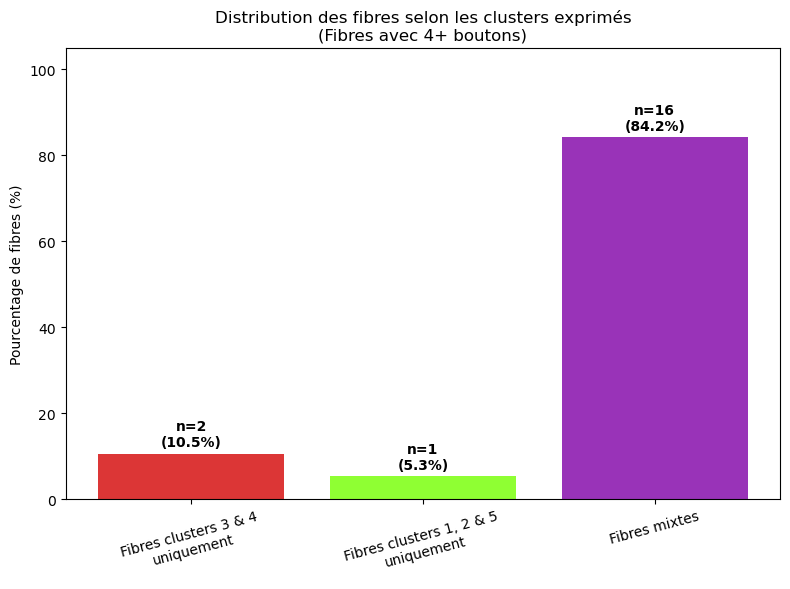

Classification des fibres par types de clusters exprimés (fibres avec 4+ boutons seulement):
- Fibres exprimant uniquement les clusters 3 et/ou 4: 2 fibres (10.5%)
- Fibres exprimant uniquement les clusters 1, 2 et/ou 5: 1 fibres (5.3%)
- Fibres mixtes (combinaison des deux groupes): 16 fibres (84.2%)
- Total: 19 fibres (avec 4+ boutons)

Exemples de fibres mixtes (si il y en a):
  20220425_linescan1_20H: clusters [3, 4, 5]
  20190801_linescan1_20H: clusters [2, 5]
  20210310_linescan1_20H: clusters [1, 2, 4, 5]
  20210128_linescan4_20H: clusters [3, 5]
  20220414_linescan1_20H: clusters [2, 5]
  ... et 11 autres fibres mixtes

Détail des fibres clusters 3 & 4 uniquement:
  20210304_linescan2_20H: clusters [4, 5]
  20220426_linescan2_20H: clusters [5]

Détail des fibres clusters 1, 2 & 5 uniquement:
  20201015_linescan4_20H: clusters [1]


In [34]:
# Classification des fibres selon les clusters exprimés
# Utiliser seulement les fibres avec 4+ boutons (comme dans l'analyse précédente)
fibers_clusters = df_filtered.groupby('Fiber_ID')['HC_UMAP'].apply(lambda x: set(x.unique()))

# Fibres n'exprimant QUE les clusters 3 et/ou 4 (aucun autre cluster)
fibers_only_3_4 = fibers_clusters[fibers_clusters.apply(lambda s: s.issubset({4, 5}) and len(s) > 0)]

# Fibres n'exprimant QUE les clusters 1, 2 et/ou 5 (aucun autre cluster)
fibers_only_1_2_5 = fibers_clusters[fibers_clusters.apply(lambda s: s.issubset({1, 2, 3}) and len(s) > 0)]

# Comptage
count_only_3_4 = len(fibers_only_3_4)
count_only_1_2_5 = len(fibers_only_1_2_5)

# Fibres mixtes (contenant des clusters des deux groupes)
all_fiber_ids = set(fibers_clusters.index)
exclusive_fiber_ids = set(fibers_only_3_4.index) | set(fibers_only_1_2_5.index)
mixed_fibers = all_fiber_ids - exclusive_fiber_ids
count_mixed = len(mixed_fibers)

# Calcul des pourcentages
total_fibers_filtered = len(fibers_clusters)
percentage_3_4 = (count_only_3_4 / total_fibers_filtered) * 100
percentage_1_2_5 = (count_only_1_2_5 / total_fibers_filtered) * 100
percentage_mixed = (count_mixed / total_fibers_filtered) * 100

# Création de l'histogramme avec 3 catégories
labels = ['Fibres clusters 3 & 4\nuniquement', 'Fibres clusters 1, 2 & 5\nuniquement', 'Fibres mixtes']
counts = [count_only_3_4, count_only_1_2_5, count_mixed]
percentages = [percentage_3_4, percentage_1_2_5, percentage_mixed]


plt.figure(figsize=(8,6))
bars = plt.bar(labels, percentages, color=["#d40404", "#73ff00", "#8000a7"], alpha=0.8)
for bar, count, pct in zip(bars, counts, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, pct + 1, 
             f'n={count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Pourcentage de fibres (%)')
plt.title('Distribution des fibres selon les clusters exprimés\n(Fibres avec 4+ boutons)')
plt.xticks(rotation=15)
plt.ylim(0, 105)  # Limiter l'axe Y de 0 à 105%
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "23_fiber_distribution_by_cluster_type.pdf"))
plt.show()

# Affichage des statistiques détaillées
print(f"Classification des fibres par types de clusters exprimés (fibres avec 4+ boutons seulement):")
print(f"- Fibres exprimant uniquement les clusters 3 et/ou 4: {count_only_3_4} fibres ({percentage_3_4:.1f}%)")
print(f"- Fibres exprimant uniquement les clusters 1, 2 et/ou 5: {count_only_1_2_5} fibres ({percentage_1_2_5:.1f}%)")
print(f"- Fibres mixtes (combinaison des deux groupes): {count_mixed} fibres ({percentage_mixed:.1f}%)")
print(f"- Total: {total_fibers_filtered} fibres (avec 4+ boutons)")

# Vérification que toutes les fibres sont bien comptées
assert count_only_3_4 + count_only_1_2_5 + count_mixed == total_fibers_filtered, "Erreur: toutes les fibres ne sont pas comptées"

print(f"\nExemples de fibres mixtes (si il y en a):")
if count_mixed > 0:
    for i, fiber_id in enumerate(list(mixed_fibers)[:5]):  # Afficher les 5 premières
        clusters_in_fiber = list(fibers_clusters[fiber_id])
        print(f"  {fiber_id}: clusters {clusters_in_fiber}")
    if count_mixed > 5:
        print(f"  ... et {count_mixed - 5} autres fibres mixtes")
else:
    print("  Aucune fibre mixte détectée")

# Affichage détaillé des fibres de chaque catégorie
print(f"\nDétail des fibres clusters 3 & 4 uniquement:")
for fiber_id in fibers_only_3_4.index:
    clusters_in_fiber = list(fibers_clusters[fiber_id])
    print(f"  {fiber_id}: clusters {clusters_in_fiber}")

print(f"\nDétail des fibres clusters 1, 2 & 5 uniquement:")
for fiber_id in fibers_only_1_2_5.index:
    clusters_in_fiber = list(fibers_clusters[fiber_id])
    print(f"  {fiber_id}: clusters {clusters_in_fiber}")

# Figure 5 : Calcium


Connecting 21 bouton pairs between 1.5Ca and 4Ca datasets using position matching


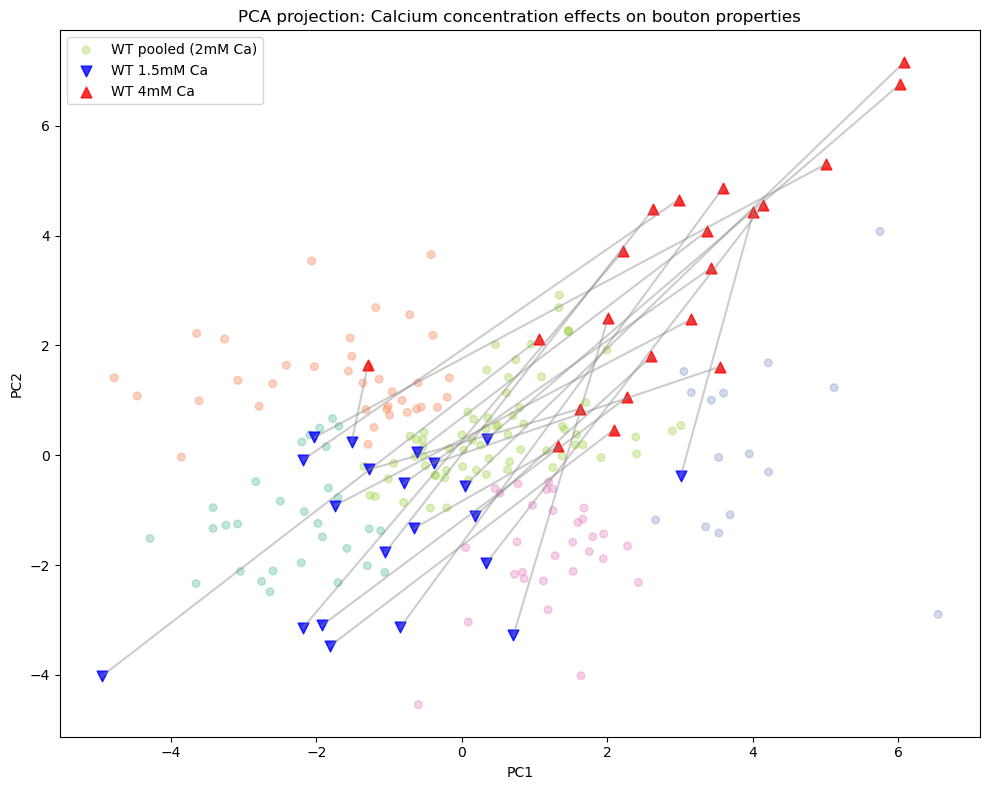

Mouvements dans l'espace PCA lors du changement de calcium:
1.5mM Ca (n=21):
  Distance moyenne: 2.657
  Écart-type: 1.345
  Min-Max: 0.618 - 5.591

4mM Ca (n=21):
  Distance moyenne: 5.932
  Écart-type: 3.097
  Min-Max: 0.818 - 12.127

Mouvements entre 1.5mM Ca et 4mM Ca (boutons appariés, n=21):
  Distance moyenne: 6.168
  Écart-type: 2.234
  Min-Max: 1.422 - 9.787


In [35]:
# Projection des données calcium sur la PCA - Figure unique
plt.figure(figsize=(10, 8))

# Plot background WT pooled data
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], 
           c=colors_umap, alpha=0.4, s=30, label='WT pooled (2mM Ca)')

# Plot 1.5mM Ca data with blue triangles (v)
plt.scatter(transformed_WT_1_5Ca['PC1'], transformed_WT_1_5Ca['PC2'], 
           marker='v', s=60, c='blue', alpha=0.8, label='WT 1.5mM Ca')

# Plot 4mM Ca data with red triangles (^)
plt.scatter(transformed_WT_4Ca['PC1'], transformed_WT_4Ca['PC2'], 
           marker='^', s=60, c='red', alpha=0.8, label='WT 4mM Ca')

# Draw lines connecting same boutons between 1.5Ca and 4Ca (purple lines)
# Use position-based matching since boutons are organized in the same order
n_boutons = min(len(transformed_WT_1_5Ca), len(transformed_WT_4Ca))
print(f"Connecting {n_boutons} bouton pairs between 1.5Ca and 4Ca datasets using position matching")

for i in range(n_boutons):
    plt.plot([transformed_WT_1_5Ca.iloc[i]['PC1'], transformed_WT_4Ca.iloc[i]['PC1']],
             [transformed_WT_1_5Ca.iloc[i]['PC2'], transformed_WT_4Ca.iloc[i]['PC2']],
             'grey', alpha=0.4, linewidth=1.5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection: Calcium concentration effects on bouton properties')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "30_calcium_trajectories_PCA.pdf"))
plt.show()

# Calculate and display movement statistics
movements_1_5Ca = []
movements_4Ca = []

for i in range(min(len(transformed_WT_pooled), len(transformed_WT_1_5Ca))):
    dist = np.sqrt((transformed_WT_pooled.iloc[i]['PC1'] - transformed_WT_1_5Ca.iloc[i]['PC1'])**2 + 
                   (transformed_WT_pooled.iloc[i]['PC2'] - transformed_WT_1_5Ca.iloc[i]['PC2'])**2)
    movements_1_5Ca.append(dist)

for i in range(min(len(transformed_WT_pooled), len(transformed_WT_4Ca))):
    dist = np.sqrt((transformed_WT_pooled.iloc[i]['PC1'] - transformed_WT_4Ca.iloc[i]['PC1'])**2 + 
                   (transformed_WT_pooled.iloc[i]['PC2'] - transformed_WT_4Ca.iloc[i]['PC2'])**2)
    movements_4Ca.append(dist)

print(f"Mouvements dans l'espace PCA lors du changement de calcium:")
print(f"1.5mM Ca (n={len(movements_1_5Ca)}):")
print(f"  Distance moyenne: {np.mean(movements_1_5Ca):.3f}")
print(f"  Écart-type: {np.std(movements_1_5Ca):.3f}")
print(f"  Min-Max: {np.min(movements_1_5Ca):.3f} - {np.max(movements_1_5Ca):.3f}")

print(f"\n4mM Ca (n={len(movements_4Ca)}):")
print(f"  Distance moyenne: {np.mean(movements_4Ca):.3f}")
print(f"  Écart-type: {np.std(movements_4Ca):.3f}")
print(f"  Min-Max: {np.min(movements_4Ca):.3f} - {np.max(movements_4Ca):.3f}")

# Calculate movement statistics for matched boutons between calcium conditions
calcium_movements = []
for i in range(n_boutons):
    dist = np.sqrt((transformed_WT_1_5Ca.iloc[i]['PC1'] - transformed_WT_4Ca.iloc[i]['PC1'])**2 + 
                   (transformed_WT_1_5Ca.iloc[i]['PC2'] - transformed_WT_4Ca.iloc[i]['PC2'])**2)
    calcium_movements.append(dist)

if calcium_movements:
    print(f"\nMouvements entre 1.5mM Ca et 4mM Ca (boutons appariés, n={len(calcium_movements)}):")
    print(f"  Distance moyenne: {np.mean(calcium_movements):.3f}")
    print(f"  Écart-type: {np.std(calcium_movements):.3f}")
    print(f"  Min-Max: {np.min(calcium_movements):.3f} - {np.max(calcium_movements):.3f}")

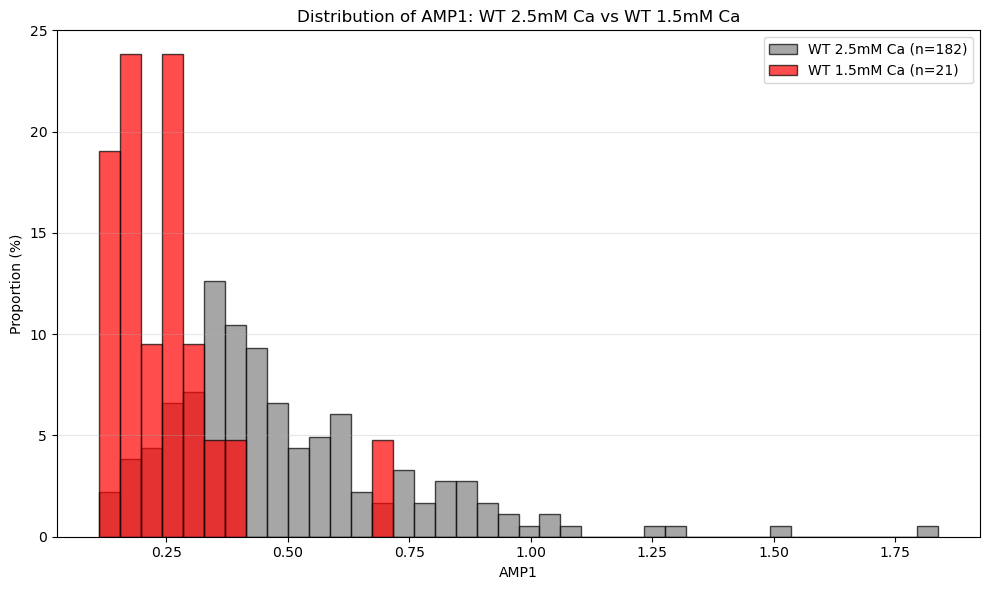

Summary statistics for AMP1:
WT 2.5mM Ca: Mean = 0.492 ± 0.260
WT 1.5mM Ca: Mean = 0.249 ± 0.130


In [36]:
# Histogram comparing AMP1 between WT_pooled (2mM Ca) and WT_1_5Ca (1.5mM Ca)
plt.figure(figsize=(10, 6))

# Calculate bin edges based on combined data
all_amp1_data = pd.concat([df_WT_pooled['AMP1'], df_WT_1_5Ca['AMP1']])
bins = np.linspace(all_amp1_data.min(), all_amp1_data.max(), 41)

# Plot histograms as proportions in percentage
weights_pooled = np.ones(len(df_WT_pooled['AMP1'])) / len(df_WT_pooled['AMP1']) * 100
weights_1_5Ca = np.ones(len(df_WT_1_5Ca['AMP1'])) / len(df_WT_1_5Ca['AMP1']) * 100

plt.hist(df_WT_pooled['AMP1'], bins=bins, alpha=0.7, color='gray', 
         label=f'WT 2.5mM Ca (n={len(df_WT_pooled)})', weights=weights_pooled, edgecolor='black')
plt.hist(df_WT_1_5Ca['AMP1'], bins=bins, alpha=0.7, color='red', 
         label=f'WT 1.5mM Ca (n={len(df_WT_1_5Ca)})', weights=weights_1_5Ca, edgecolor='black')

plt.xlabel('AMP1')
plt.ylabel('Proportion (%)')
plt.title('Distribution of AMP1: WT 2.5mM Ca vs WT 1.5mM Ca')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "31_AMP1_histogram_2_5mM_vs_1_5mM_Ca.pdf"))
plt.show()

# Print summary statistics
print("Summary statistics for AMP1:")
print(f"WT 2.5mM Ca: Mean = {df_WT_pooled['AMP1'].mean():.3f} ± {df_WT_pooled['AMP1'].std():.3f}")
print(f"WT 1.5mM Ca: Mean = {df_WT_1_5Ca['AMP1'].mean():.3f} ± {df_WT_1_5Ca['AMP1'].std():.3f}")

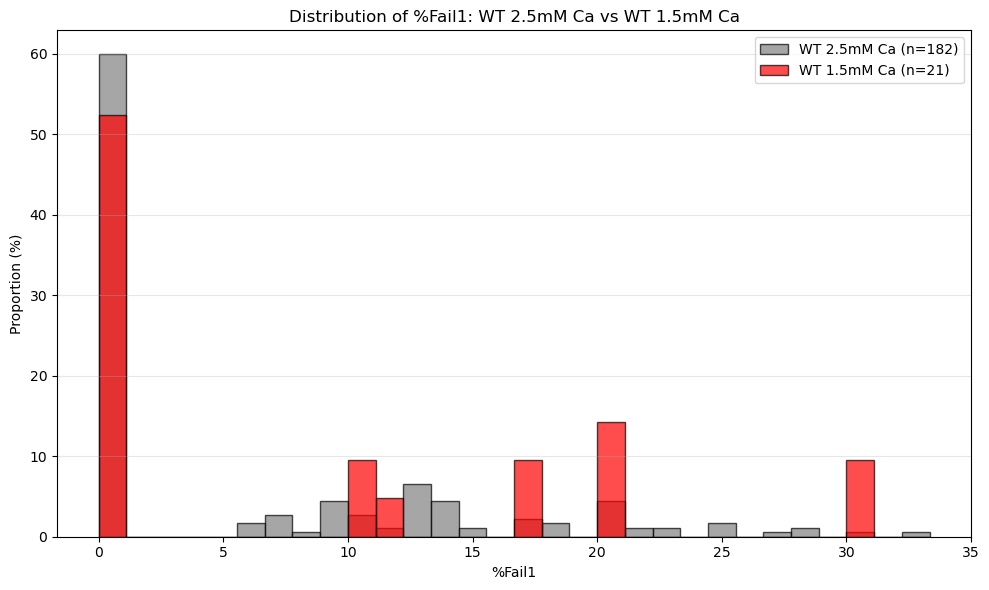

Summary statistics for %Fail1:
WT 2.5mM Ca: Mean = 6.031 ± 8.401
WT 1.5mM Ca: Mean = 8.783 ± 10.628


In [37]:
# Histogram comparing %Fail1 between WT_pooled (2mM Ca) and WT_1_5Ca (1.5mM Ca)
plt.figure(figsize=(10, 6))

# Calculate bin edges based on combined data
all_fail1_data = pd.concat([df_WT_pooled['%Fail1'], df_WT_1_5Ca['%Fail1']])
bins = np.linspace(all_fail1_data.min(), all_fail1_data.max(), 31)

# Plot histograms as proportions in percentage
weights_pooled = np.ones(len(df_WT_pooled['%Fail1'])) / len(df_WT_pooled['%Fail1']) * 100
weights_1_5Ca = np.ones(len(df_WT_1_5Ca['%Fail1'])) / len(df_WT_1_5Ca['%Fail1']) * 100

plt.hist(df_WT_pooled['%Fail1'], bins=bins, alpha=0.7, color='gray', 
         label=f'WT 2.5mM Ca (n={len(df_WT_pooled)})', weights=weights_pooled, edgecolor='black')
plt.hist(df_WT_1_5Ca['%Fail1'], bins=bins, alpha=0.7, color='red', 
         label=f'WT 1.5mM Ca (n={len(df_WT_1_5Ca)})', weights=weights_1_5Ca, edgecolor='black')

plt.xlabel('%Fail1')
plt.ylabel('Proportion (%)')
plt.title('Distribution of %Fail1: WT 2.5mM Ca vs WT 1.5mM Ca')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "32_Fail1_histogram_2_5mM_vs_1_5mM_Ca.pdf"))
plt.show()

# Print summary statistics
print("Summary statistics for %Fail1:")
print(f"WT 2.5mM Ca: Mean = {df_WT_pooled['%Fail1'].mean():.3f} ± {df_WT_pooled['%Fail1'].std():.3f}")
print(f"WT 1.5mM Ca: Mean = {df_WT_1_5Ca['%Fail1'].mean():.3f} ± {df_WT_1_5Ca['%Fail1'].std():.3f}")

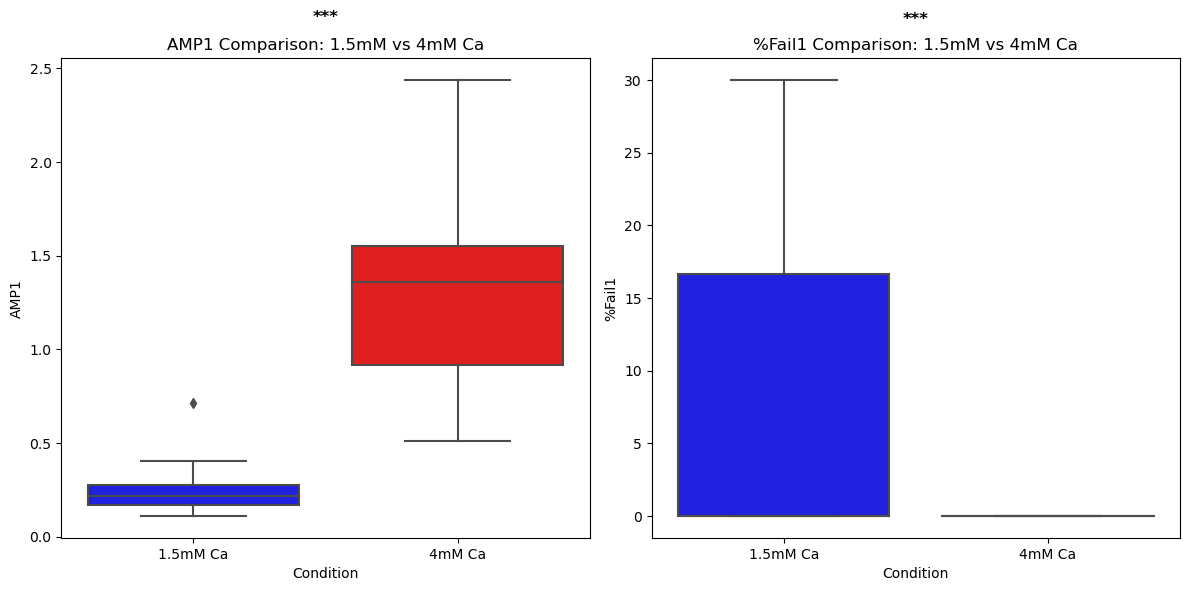

Statistical comparison between 1.5mM Ca and 4mM Ca conditions:

AMP1:
1.5mM Ca (n=21): 0.249 ± 0.130
4mM Ca (n=21): 1.325 ± 0.550
Mann-Whitney U test: U = 3.000, p = 4.793751861055e-08
Significance: ***

%Fail1:
1.5mM Ca (n=21): 8.783 ± 10.628
4mM Ca (n=21): 0.000 ± 0.000
Mann-Whitney U test: U = 325.500, p = 4.295093028219e-04
Significance: ***


In [38]:
from scipy.stats import mannwhitneyu

# Create box plots comparing AMP1 and %Fail1 between 1.5mM and 4mM Ca conditions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Prepare data for box plots
amp1_data = pd.DataFrame({
    'AMP1': list(df_WT_1_5Ca['AMP1']) + list(df_WT_4Ca['AMP1']),
    'Condition': ['1.5mM Ca'] * len(df_WT_1_5Ca) + ['4mM Ca'] * len(df_WT_4Ca)
})

fail1_data = pd.DataFrame({
    '%Fail1': list(df_WT_1_5Ca['%Fail1']) + list(df_WT_4Ca['%Fail1']),
    'Condition': ['1.5mM Ca'] * len(df_WT_1_5Ca) + ['4mM Ca'] * len(df_WT_4Ca)
})

# Box plot for AMP1
sns.boxplot(data=amp1_data, x='Condition', y='AMP1', ax=ax1, palette=['blue', 'red'])
ax1.set_title('AMP1 Comparison: 1.5mM vs 4mM Ca')
ax1.set_ylabel('AMP1')

# Box plot for %Fail1
sns.boxplot(data=fail1_data, x='Condition', y='%Fail1', ax=ax2, palette=['blue', 'red'])
ax2.set_title('%Fail1 Comparison: 1.5mM vs 4mM Ca')
ax2.set_ylabel('%Fail1')

# Statistical tests (Mann-Whitney U test for non-parametric comparison)
amp1_stat, amp1_p = mannwhitneyu(df_WT_1_5Ca['AMP1'], df_WT_4Ca['AMP1'], alternative='two-sided')
fail1_stat, fail1_p = mannwhitneyu(df_WT_1_5Ca['%Fail1'], df_WT_4Ca['%Fail1'], alternative='two-sided')

# Add significance annotations
def add_significance_annotation(ax, p_value, y_pos):
    """Add significance annotation to plot"""
    if p_value < 0.001:
        sig_text = '***'
    elif p_value < 0.01:
        sig_text = '**'
    elif p_value < 0.05:
        sig_text = '*'
    else:
        sig_text = 'ns'
    
    ax.annotate('', xy=(0, y_pos), xytext=(1, y_pos),
                arrowprops=dict(arrowstyle='-', color='black', lw=1))
    ax.text(0.5, y_pos + 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0]), 
            sig_text, ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add significance annotations
amp1_y_max = max(amp1_data['AMP1']) * 1.1
fail1_y_max = max(fail1_data['%Fail1']) * 1.1

add_significance_annotation(ax1, amp1_p, amp1_y_max)
add_significance_annotation(ax2, fail1_p, fail1_y_max)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "33_calcium_boxplot_comparison.pdf"))
plt.show()

# Print statistical results and save to file
results_text = []
results_text.append("Statistical comparison between 1.5mM Ca and 4mM Ca conditions:")
results_text.append("=" * 60)

results_text.append(f"\nAMP1:")
results_text.append(f"1.5mM Ca (n={len(df_WT_1_5Ca)}): {df_WT_1_5Ca['AMP1'].mean():.3f} ± {df_WT_1_5Ca['AMP1'].std():.3f}")
results_text.append(f"4mM Ca (n={len(df_WT_4Ca)}): {df_WT_4Ca['AMP1'].mean():.3f} ± {df_WT_4Ca['AMP1'].std():.3f}")
results_text.append(f"Mann-Whitney U test: U = {amp1_stat:.3f}, p = {amp1_p:.12e}")
results_text.append(f"Significance: {'***' if amp1_p < 0.001 else '**' if amp1_p < 0.01 else '*' if amp1_p < 0.05 else 'ns'}")

results_text.append(f"\n%Fail1:")
results_text.append(f"1.5mM Ca (n={len(df_WT_1_5Ca)}): {df_WT_1_5Ca['%Fail1'].mean():.3f} ± {df_WT_1_5Ca['%Fail1'].std():.3f}")
results_text.append(f"4mM Ca (n={len(df_WT_4Ca)}): {df_WT_4Ca['%Fail1'].mean():.3f} ± {df_WT_4Ca['%Fail1'].std():.3f}")
results_text.append(f"Mann-Whitney U test: U = {fail1_stat:.3f}, p = {fail1_p:.12e}")
results_text.append(f"Significance: {'***' if fail1_p < 0.001 else '**' if fail1_p < 0.01 else '*' if fail1_p < 0.05 else 'ns'}")

# Print to console
for line in results_text:
    print(line)

# Save to text file
with open(os.path.join(output_dir, "33_calcium_boxplot_comparison_statistics.txt"), 'w', encoding='utf-8') as f:
    f.write('\n'.join(results_text))

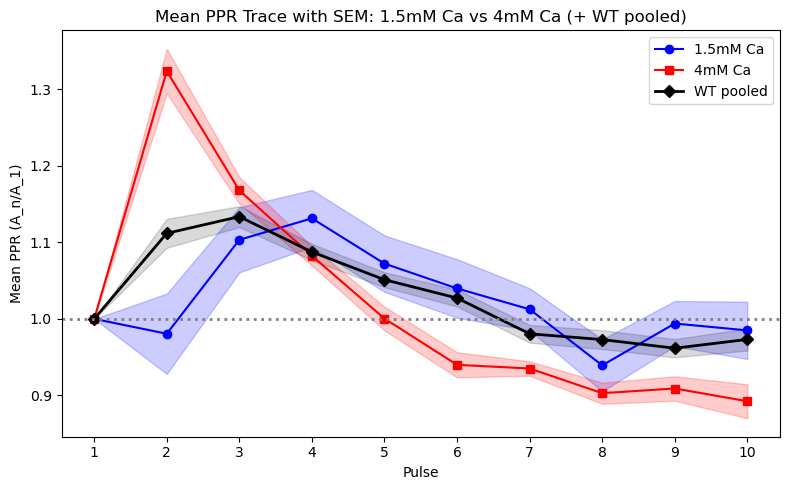

In [39]:
# Plot mean PPR trace with SEM for 4Ca and 1.5Ca, and add WT_pooled in black
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_WT_1_5Ca.columns]
x_pulses = list(range(1, len(ppr_cols) + 2))  # 1 to 10

# Calculate means and SEMs for 1.5Ca
means_1_5Ca = [1] + df_WT_1_5Ca[ppr_cols].mean().tolist()
sems_1_5Ca = [0] + df_WT_1_5Ca[ppr_cols].sem().tolist()

# Calculate means and SEMs for 4Ca
means_4Ca = [1] + df_WT_4Ca[ppr_cols].mean().tolist()
sems_4Ca = [0] + df_WT_4Ca[ppr_cols].sem().tolist()

# Calculate means and SEMs for WT_pooled
means_pooled = [1] + df_WT_pooled[ppr_cols].mean().tolist()
sems_pooled = [0] + df_WT_pooled[ppr_cols].sem().tolist()

plt.figure(figsize=(8, 5))
plt.plot(x_pulses, means_1_5Ca, marker='o', color='blue', label='1.5mM Ca')
plt.fill_between(x_pulses, np.array(means_1_5Ca) - np.array(sems_1_5Ca),
                 np.array(means_1_5Ca) + np.array(sems_1_5Ca), color='blue', alpha=0.2)
plt.plot(x_pulses, means_4Ca, marker='s', color='red', label='4mM Ca')
plt.fill_between(x_pulses, np.array(means_4Ca) - np.array(sems_4Ca),
                 np.array(means_4Ca) + np.array(sems_4Ca), color='red', alpha=0.2)
plt.plot(x_pulses, means_pooled, marker='D', color='black', label='WT pooled', linewidth=2)
plt.fill_between(x_pulses, np.array(means_pooled) - np.array(sems_pooled),
                 np.array(means_pooled) + np.array(sems_pooled), color='black', alpha=0.15)
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.xlabel('Pulse')
plt.ylabel('Mean PPR (A_n/A_1)')
plt.title('Mean PPR Trace with SEM: 1.5mM Ca vs 4mM Ca (+ WT pooled)')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.legend()
plt.tight_layout()
# Save figure and values
fig_path = os.path.join(output_dir, "34_PPR_trace_1_5mM_vs_4mM_Ca.pdf")
plt.savefig(fig_path)
plt.show()

# Save means and SEMs to text file
txt_path = os.path.join(output_dir, "34_PPR_trace_1_5mM_vs_4mM_Ca.txt")
with open(txt_path, "w", encoding="utf-8") as f_txt:
    f_txt.write("Pulse\tMean_1.5mM_Ca\tSEM_1.5mM_Ca\tMean_4mM_Ca\tSEM_4mM_Ca\tMean_WT_pooled\tSEM_WT_pooled\n")
    for i in range(len(x_pulses)):
        f_txt.write(f"{x_pulses[i]}\t{means_1_5Ca[i]:.4f}\t{sems_1_5Ca[i]:.4f}\t{means_4Ca[i]:.4f}\t{sems_4Ca[i]:.4f}\t{means_pooled[i]:.4f}\t{sems_pooled[i]:.4f}\n")

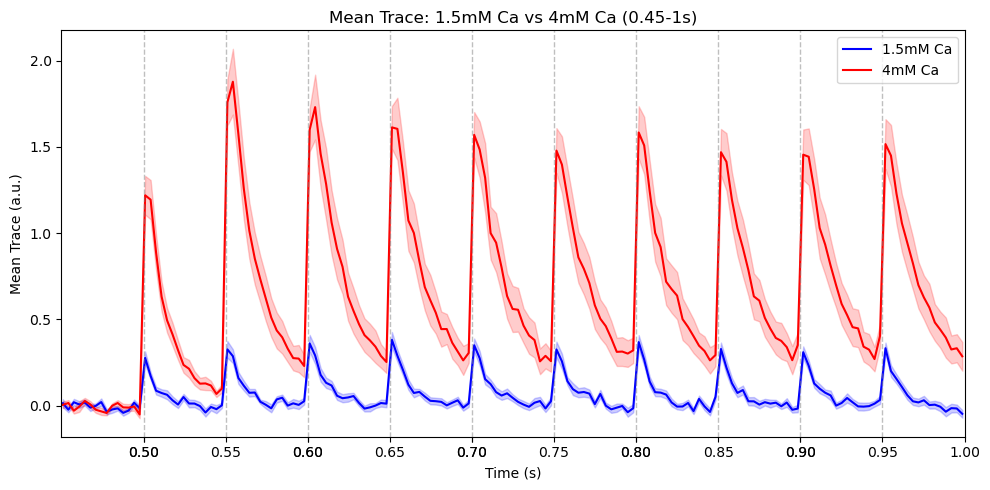

In [40]:
trace_1_5Ca = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="Theo_1_5Ca")
trace_4Ca   = pd.read_excel(r"C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx", sheet_name="Theo_4Ca")

# Plot mean trace between 0.45 and 1s for both conditions, with ticks every 0.05s from 0.5s (10 ticks)
# Extract time and traces (ignore first row if it's an ID)
time = trace_1_5Ca.iloc[1:, 0].astype(float).values
traces_1_5Ca = trace_1_5Ca.iloc[1:, 1:].astype(float).values
traces_4Ca = trace_4Ca.iloc[1:, 1:].astype(float).values

mean_1_5Ca = np.mean(traces_1_5Ca, axis=1)
sem_1_5Ca = np.std(traces_1_5Ca, axis=1) / np.sqrt(traces_1_5Ca.shape[1])
mean_4Ca = np.mean(traces_4Ca, axis=1)
sem_4Ca = np.std(traces_4Ca, axis=1) / np.sqrt(traces_4Ca.shape[1])

# Restrict to 0.45-1s
mask = (time >= 0.45) & (time <= 1.0)
time_plot = time[mask]
mean_1_5Ca_plot = mean_1_5Ca[mask]
sem_1_5Ca_plot = sem_1_5Ca[mask]
mean_4Ca_plot = mean_4Ca[mask]
sem_4Ca_plot = sem_4Ca[mask]

plt.figure(figsize=(10, 5))
plt.plot(time_plot, mean_1_5Ca_plot, color='blue', label='1.5mM Ca')
plt.fill_between(time_plot, mean_1_5Ca_plot - sem_1_5Ca_plot, mean_1_5Ca_plot + sem_1_5Ca_plot, color='blue', alpha=0.2)
plt.plot(time_plot, mean_4Ca_plot, color='red', label='4mM Ca')
plt.fill_between(time_plot, mean_4Ca_plot - sem_4Ca_plot, mean_4Ca_plot + sem_4Ca_plot, color='red', alpha=0.2)

# Add ticks every 0.05s from 0.5s (10 ticks)
stim_times = [0.5 + 0.05 * i for i in range(10)]
for stim in stim_times:
    plt.axvline(stim, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.xticks(list(plt.xticks()[0]) + stim_times)
plt.xlim(0.45, 1.0)
plt.xlabel('Time (s)')
plt.ylabel('Mean Trace (a.u.)')
plt.title('Mean Trace: 1.5mM Ca vs 4mM Ca (0.45-1s)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "35_mean_trace_1_5mM_vs_4mM_Ca.pdf"))
plt.show()

# Figure 6 : manip stabilité


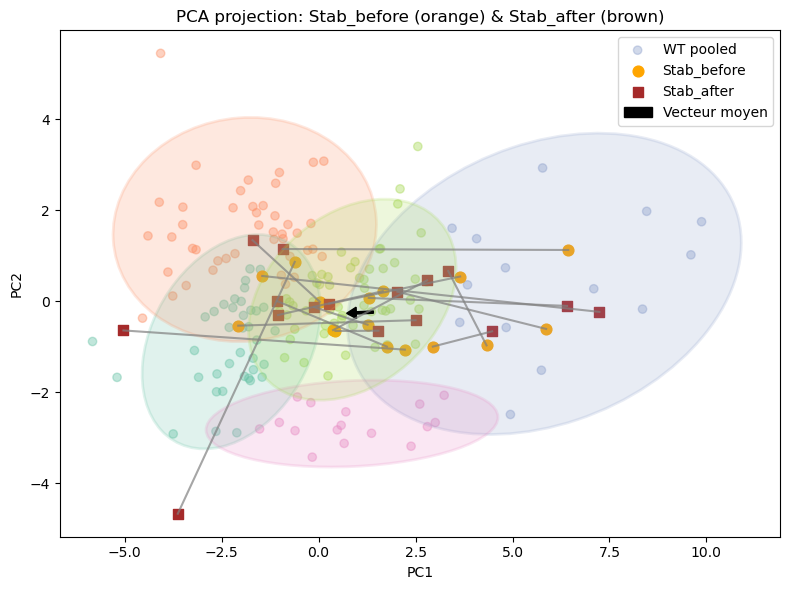

In [170]:
from matplotlib.patches import Ellipse
from scipy.stats import chi2

def draw_ellipse(position, covariance, ax, color, alpha=0.2, linewidth=2):
    # 95% confidence ellipse for 2D data
    chi2_val = chi2.ppf(0.95, df=2)
    U, s, _ = np.linalg.svd(covariance)
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
    width, height = 2 * np.sqrt(chi2_val * s)
    ellipse = Ellipse(position, width, height, angle, facecolor=color, edgecolor=color, alpha=alpha, linewidth=linewidth)
    ax.add_patch(ellipse)

plt.figure(figsize=(8, 6))
ax = plt.gca()
# Plot WT pooled background with cluster colors
ax.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')

# Plot Stab_before (orange)
ax.scatter(transformed_stab_before['PC1'], transformed_stab_before['PC2'], marker='o', s=60, c='orange', label='Stab_before')

# Plot Stab_after (brown)
ax.scatter(transformed_stab_after['PC1'], transformed_stab_after['PC2'], marker='s', s=60, c='brown', label='Stab_after')

# Add lines connecting same boutons
for i in range(min(len(transformed_stab_before), len(transformed_stab_after))):
    ax.plot(
        [transformed_stab_before.iloc[i]['PC1'], transformed_stab_after.iloc[i]['PC1']],
        [transformed_stab_before.iloc[i]['PC2'], transformed_stab_after.iloc[i]['PC2']],
        color='gray', alpha=0.7, linewidth=1.5
    )

# Confidence ellipses for each cluster
cmap = cm.get_cmap('Set2')
n_clust = len(set(hc_labels))
for cluster_id in range(1, n_clust + 1):
    mask = hc_labels == cluster_id
    cluster_points = transformed_WT_pooled.loc[mask, ['PC1', 'PC2']].values
    if len(cluster_points) > 2:
        center = cluster_points.mean(axis=0)
        cov = np.cov(cluster_points.T)
        draw_ellipse(center, cov, ax, color=cmap(cluster_id-1))

# Mean displacement vector
delta = transformed_stab_after.values - transformed_stab_before.values
mean_delta = delta.mean(axis=0)
all_points = np.vstack([transformed_stab_before.values, transformed_stab_after.values])
center = all_points.mean(axis=0)
ax.arrow(center[0], center[1], mean_delta[0], mean_delta[1], 
         color='black', width=0.05, head_width=0.25, head_length=0.25, length_includes_head=True, label='Vecteur moyen')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection: Stab_before (orange) & Stab_after (brown)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "PCA_stab_before_after.pdf"))
plt.show()

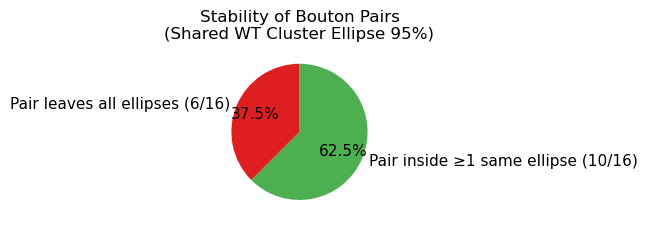

Total pairs evaluated: 16
Pairs staying in at least one same ellipse: 10 (62.5%)
Pairs leaving all ellipses: 6 (37.5%)

Pairs leaving all ellipses (index, before_clusters -> after_clusters):
  1: [3] -> [2, 5] (common=[])
  2: [3] -> [1, 2] (common=[])
  4: [1, 2, 5] -> [] (common=[])
  5: [1, 2] -> [3] (common=[])
  7: [3, 5] -> [] (common=[])
  12: [1, 2] -> [3, 5] (common=[])


In [171]:
from scipy.stats import chi2

# Evaluate if each BEFORE/AFTER pair stays inside at least one same WT cluster 95% ellipse
# and display a pie chart of the proportion.


# 1. Build 95% confidence ellipses (Mahalanobis) for WT pooled clusters (same logic as in cell 78)
chi2_thr = chi2.ppf(0.95, df=2)
ellipse_models = []  # list of dicts: {'cluster': id, 'center': center, 'inv_cov': inv_cov}

for cluster_id in range(1, n_clust + 1):
    mask = hc_labels == cluster_id
    cluster_points = transformed_WT_pooled.loc[mask, ['PC1', 'PC2']].values
    if cluster_points.shape[0] > 2:
        center = cluster_points.mean(axis=0)
        cov = np.cov(cluster_points.T)
        # Use pseudo-inverse for numerical stability
        inv_cov = np.linalg.pinv(cov)
        ellipse_models.append({
            'cluster': cluster_id,
            'center': center,
            'inv_cov': inv_cov
        })

def point_clusters(point, models, thr):
    """Return set of cluster IDs whose ellipses contain the point."""
    pcs = set()
    for m in models:
        d = point - m['center']
        md2 = float(d.T @ m['inv_cov'] @ d)
        if md2 <= thr:
            pcs.add(m['cluster'])
    return pcs

before_pts = transformed_stab_before[['PC1','PC2']].values
after_pts  = transformed_stab_after[['PC1','PC2']].values
n_pairs = min(len(before_pts), len(after_pts))

same_count = 0
diff_count = 0
details = []

for i in range(n_pairs):
    cb = point_clusters(before_pts[i], ellipse_models, chi2_thr)
    ca = point_clusters(after_pts[i], ellipse_models, chi2_thr)
    common = cb.intersection(ca)
    stays = len(common) > 0
    if stays:
        same_count += 1
    else:
        diff_count += 1
    details.append({
        'pair_index': i,
        'before_clusters': sorted(cb),
        'after_clusters': sorted(ca),
        'common': sorted(common),
        'stays_in_any_same_ellipse': stays
    })

# 2. Pie chart
labels_pie = [
    f"Pair inside ≥1 same ellipse ({same_count}/{n_pairs})",
    f"Pair leaves all ellipses ({diff_count}/{n_pairs})"
]
sizes = [same_count, diff_count]
colors_pie = ['#4CAF50', '#DF1F1F']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels_pie, colors=colors_pie, autopct='%.1f%%',
        startangle=90, counterclock=False, pctdistance=0.7, textprops={'fontsize':11})
plt.title("Stability of Bouton Pairs\n(Shared WT Cluster Ellipse 95%)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "PCA_stab_before_after_same_ellipse_pie.pdf"))
plt.show()

# 3. Print summary + list of pairs that do NOT stay
print(f"Total pairs evaluated: {n_pairs}")
print(f"Pairs staying in at least one same ellipse: {same_count} ({same_count/n_pairs*100:.1f}%)")
print(f"Pairs leaving all ellipses: {diff_count} ({diff_count/n_pairs*100:.1f}%)\n")

if diff_count > 0:
    print("Pairs leaving all ellipses (index, before_clusters -> after_clusters):")
    for d in details:
        if not d['stays_in_any_same_ellipse']:
            print(f"  {d['pair_index']}: {d['before_clusters']} -> {d['after_clusters']} (common={d['common']})")
else:
    print("All pairs remained within at least one common ellipse.")



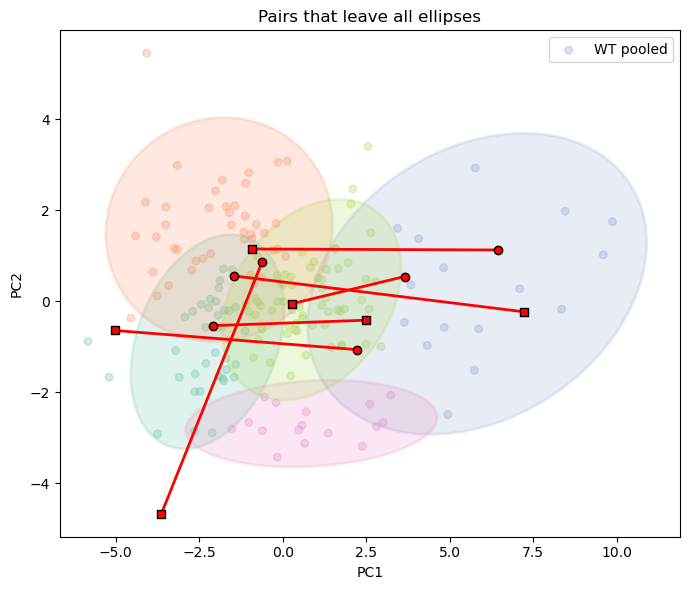

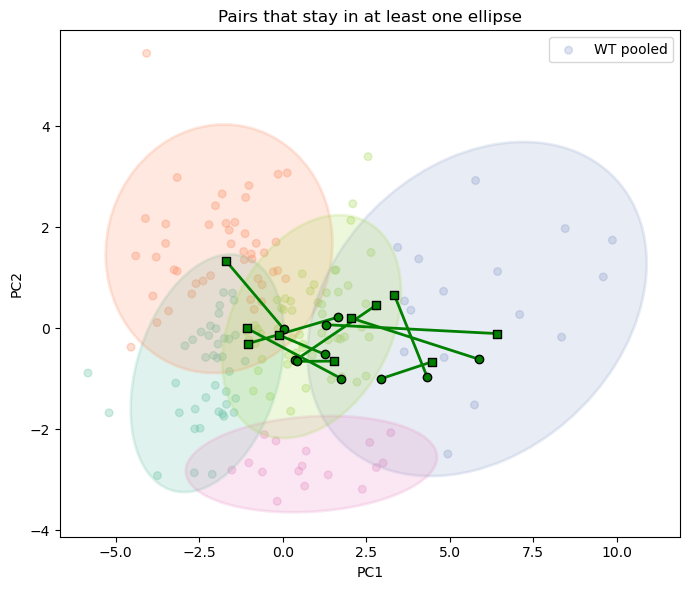

In [175]:
# Identify indices of pairs that leave all ellipses and those that stay in at least one
leave_indices = [d['pair_index'] for d in details if not d['stays_in_any_same_ellipse']]
stay_indices = [d['pair_index'] for d in details if d['stays_in_any_same_ellipse']]

# Function to plot ellipses for clusters
def plot_cluster_ellipses(ax):
    cmap = cm.get_cmap('Set2')
    for cluster_id in range(1, n_clust + 1):
        mask = hc_labels == cluster_id
        cluster_points = transformed_WT_pooled.loc[mask, ['PC1', 'PC2']].values
        if len(cluster_points) > 2:
            center = cluster_points.mean(axis=0)
            cov = np.cov(cluster_points.T)
            draw_ellipse(center, cov, ax, color=cmap(cluster_id-1))

# Graph 1: Pairs that leave all ellipses
fig1, ax1 = plt.subplots(figsize=(7, 6))
ax1.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.3, s=30, label='WT pooled')
for i in leave_indices:
    x0, y0 = transformed_stab_before.iloc[i][['PC1', 'PC2']]
    x1, y1 = transformed_stab_after.iloc[i][['PC1', 'PC2']]
    ax1.plot([x0, x1], [y0, y1], color='red', linewidth=2)
    ax1.scatter([x0], [y0], color='red', edgecolor='k', zorder=5)
    ax1.scatter([x1], [y1], color='red', marker='s', edgecolor='k', zorder=5)
plot_cluster_ellipses(ax1)
ax1.set_title('Pairs that leave all ellipses')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "PCA_stab_pairs_leave_ellipses.pdf"))
plt.show()

# Graph 2: Pairs that stay in at least one ellipse
fig2, ax2 = plt.subplots(figsize=(7, 6))
ax2.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.3, s=30, label='WT pooled')
for i in stay_indices:
    x0, y0 = transformed_stab_before.iloc[i][['PC1', 'PC2']]
    x1, y1 = transformed_stab_after.iloc[i][['PC1', 'PC2']]
    ax2.plot([x0, x1], [y0, y1], color='green', linewidth=2)
    ax2.scatter([x0], [y0], color='green', edgecolor='k', zorder=5)
    ax2.scatter([x1], [y1], color='green', marker='s', edgecolor='k', zorder=5)
plot_cluster_ellipses(ax2)
ax2.set_title('Pairs that stay in at least one ellipse')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "PCA_stab_pairs_stay_ellipses.pdf"))
plt.show()

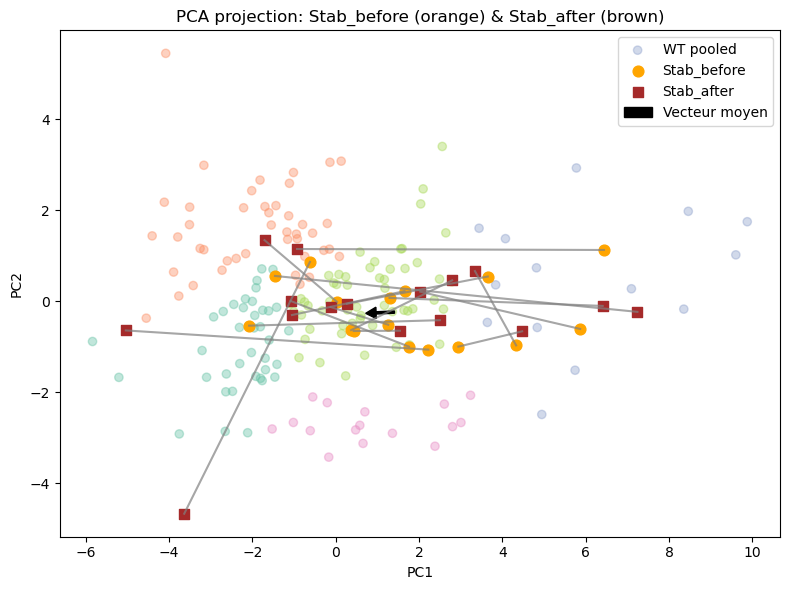

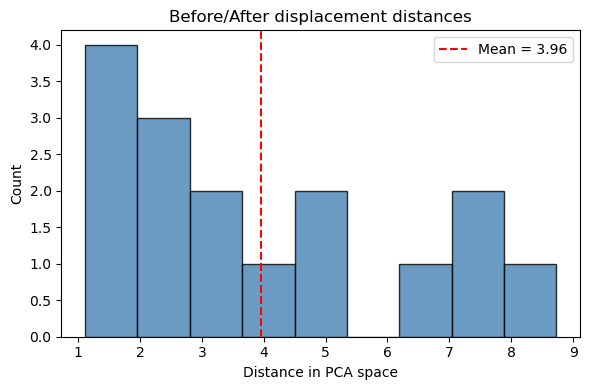

Distances (n=16):
[2.202 3.433 7.363 2.751 6.302 8.731 1.566 7.271 5.118 3.921 2.659 3.012
 4.576 1.909 1.434 1.11 ]
Mean ± SD: 3.960 ± 2.296
Top 5 displacement indices (0-based) and distances:
Index 5: distance = 8.731
Index 2: distance = 7.363
Index 7: distance = 7.271
Index 4: distance = 6.302
Index 8: distance = 5.118


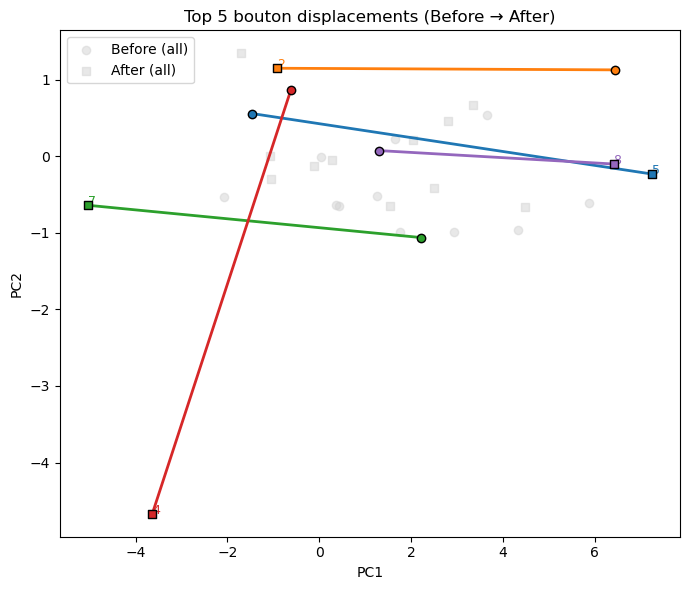

Raw trace DataFrames 'stab_before_traces' and 'stab_after_traces' not found; only PCA movement plotted.


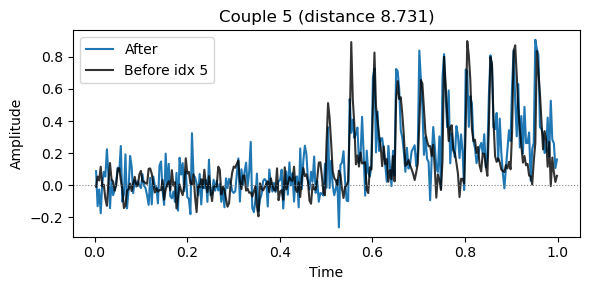

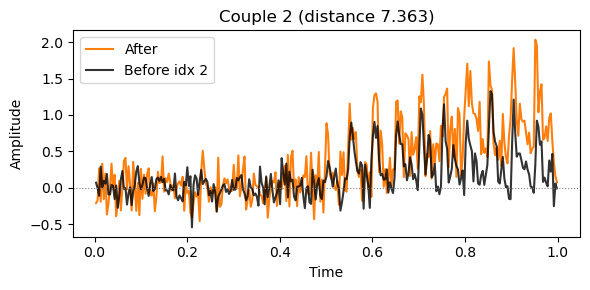

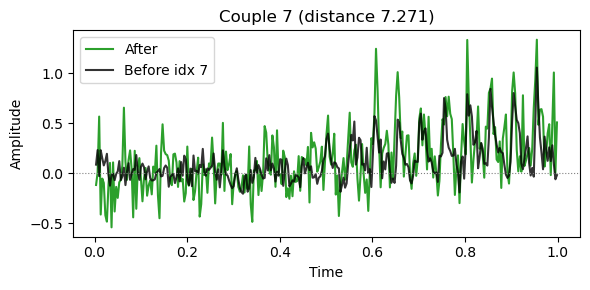

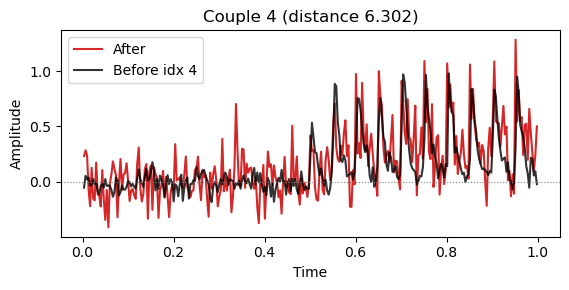

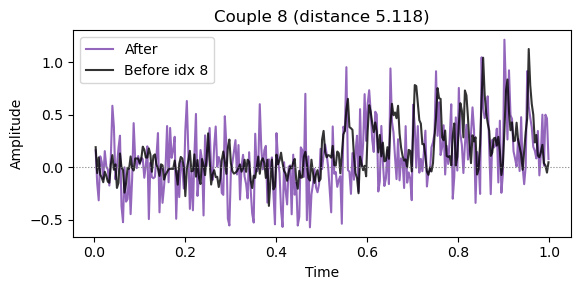

In [169]:
plt.figure(figsize=(8, 6))
# Plot WT pooled background with cluster colors
plt.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], c=colors_umap, alpha=0.4, label='WT pooled')

# Plot Stab_before (orange)
plt.scatter(transformed_stab_before['PC1'], transformed_stab_before['PC2'], marker='o', s=60, c='orange', label='Stab_before')

# Plot Stab_after (brown)
plt.scatter(transformed_stab_after['PC1'], transformed_stab_after['PC2'], marker='s', s=60, c='brown', label='Stab_after')

# Ajoute des lignes reliant les mêmes boutons (même ID dans before et after)
for i in range(min(len(transformed_stab_before), len(transformed_stab_after))):
    plt.plot(
        [transformed_stab_before.iloc[i]['PC1'], transformed_stab_after.iloc[i]['PC1']],
        [transformed_stab_before.iloc[i]['PC2'], transformed_stab_after.iloc[i]['PC2']],
        color='gray', alpha=0.7, linewidth=1.5
    )

# Calcul du vecteur moyen de déplacement
delta = transformed_stab_after.values - transformed_stab_before.values
mean_delta = delta.mean(axis=0)

# Calcul du centre moyen (tous points before+after)
all_points = np.vstack([transformed_stab_before.values, transformed_stab_after.values])
center = all_points.mean(axis=0)

# Ajoute le vecteur moyen centré sur la position moyenne
plt.arrow(center[0], center[1], mean_delta[0], mean_delta[1], 
          color='black', width=0.05, head_width=0.25, head_length=0.25, length_includes_head=True, label='Vecteur moyen')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection: Stab_before (orange) & Stab_after (brown)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "PCA_stab_before_after.pdf"))
plt.show()

# Histogram of per-bouton displacement distances (before -> after)
distances = np.linalg.norm(delta, axis=1)

plt.figure(figsize=(6,4))
plt.hist(distances, bins=9, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(distances.mean(), color='red', linestyle='dashed', linewidth=1.5, label=f"Mean = {distances.mean():.2f}")
plt.xlabel('Distance in PCA space')
plt.ylabel('Count')
plt.title('Before/After displacement distances')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "PCA_stab_before_after_distances_hist.pdf"))
plt.show()

print(f"Distances (n={len(distances)}):")
print(np.round(distances, 3))
print(f"Mean ± SD: {distances.mean():.3f} ± {distances.std():.3f}")

# Indices of the 5 largest displacements
top5_idx = np.argsort(distances)[-5:][::-1]

print("Top 5 displacement indices (0-based) and distances:")
for i in top5_idx:
    print(f"Index {i}: distance = {distances[i]:.3f}")

# Highlight these 5 pairs on a dedicated PCA movement plot
plt.figure(figsize=(7,6))
plt.scatter(transformed_stab_before['PC1'], transformed_stab_before['PC2'], c='lightgray', label='Before (all)', alpha=0.5)
plt.scatter(transformed_stab_after['PC1'], transformed_stab_after['PC2'], c='lightgray', marker='s', label='After (all)', alpha=0.5)

colors_top = plt.cm.tab10.colors
for j, i in enumerate(top5_idx):
    c = colors_top[j % len(colors_top)]
    x0, y0 = transformed_stab_before.iloc[i][['PC1','PC2']]
    x1, y1 = transformed_stab_after.iloc[i][['PC1','PC2']]
    plt.plot([x0, x1], [y0, y1], color=c, linewidth=2)
    plt.scatter([x0], [y0], color=c, edgecolor='k', zorder=5)
    plt.scatter([x1], [y1], color=c, marker='s', edgecolor='k', zorder=5)
    plt.text(x1, y1, f"{i}", color=c, fontsize=9)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Top 5 bouton displacements (Before → After)')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "PCA_stab_top5_displacements.pdf"))
plt.show()

# If raw traces DataFrames exist (expected format: first column time, subsequent columns boutons in same order)
if 'stab_before_traces' in locals() and 'stab_after_traces' in locals():
    try:
        time_stab = stab_before_traces.iloc[1:, 0].astype(float).values
        for j, i in enumerate(top5_idx):
            fig, ax = plt.subplots(figsize=(6,3))
            trace_before = stab_before_traces.iloc[1:, i+1].astype(float).values
            trace_after  = stab_after_traces.iloc[1:, i+1].astype(float).values
            ax.plot(time_stab, trace_before, label=f'Before (idx {i})', color=colors_top[j % len(colors_top)], alpha=0.7)
            ax.plot(time_stab, trace_after, label='After', color=colors_top[j % len(colors_top)], linestyle='--')
            ax.axhline(0, color='gray', linewidth=1, linestyle='dotted')
            ax.set_xlabel('Time')
            ax.set_ylabel('Amplitude')
            ax.set_title(f'Bouton {i} trace (distance {distances[i]:.3f})')
            ax.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f"PCA_stab_trace_before_after_idx{i}.pdf"))
            plt.show()
    except Exception as e:
        print(f"Trace plotting skipped due to error: {e}")
else:
    print("Raw trace DataFrames 'stab_before_traces' and 'stab_after_traces' not found; only PCA movement plotted.")


test_before = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name=6)
test_after = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name=7)
# Traces individuelles des couples (top5) before vs after avec même code couleur
if 'test_before' in locals() and 'test_after' in locals():
    try:
        time_test = test_before.iloc[1:, 0].astype(float).values
        n_cols_before = test_before.shape[1] - 1
        n_cols_after = test_after.shape[1] - 1
        for j, i in enumerate(top5_idx):
            if i >= n_cols_before or i >= n_cols_after:
                print(f"Index {i} ignoré (colonnes insuffisantes).")
                continue
            c = colors_top[j % len(colors_top)]
            trace_b = test_before.iloc[1:, i+1].astype(float).values
            trace_a = test_after.iloc[1:, i+1].astype(float).values
            fig, ax = plt.subplots(figsize=(6,3))
            ax.plot(time_test, trace_a, color=c, label='After')
            ax.plot(time_test, trace_b, color='k', label=f'Before idx {i}', alpha=0.8)
            
            ax.axhline(0, color='gray', linewidth=0.8, linestyle='dotted')
            ax.set_xlabel('Time')
            ax.set_ylabel('Amplitude')
            ax.set_title(f'Couple {i} (distance {distances[i]:.3f})')
            ax.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f"PCA_stab_test_trace_idx{i}.pdf"))
            plt.show()
    except Exception as e:
        print(f"Erreur tracés test_before/test_after: {e}")
else:
    print("Variables test_before/test_after non trouvées.")




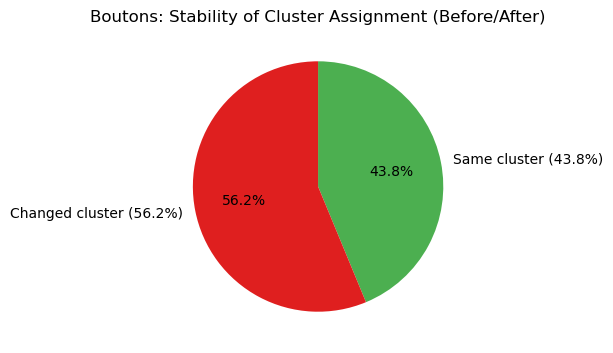

In [42]:
clusters_before = assign_clusters_robust(transformed_data_WT_pooled, hc_labels, transformed_stab_before.values, method='single')
clusters_after = assign_clusters_robust(transformed_data_WT_pooled, hc_labels, transformed_stab_after.values, method='single')

# Calculate percentage of boutons that remain in the same cluster vs those that change (before/after)
same_cluster = np.sum(clusters_before == clusters_after)
diff_cluster = np.sum(clusters_before != clusters_after)
total = len(clusters_before)

percent_same = 100 * same_cluster / total
percent_diff = 100 * diff_cluster / total

# Pie chart (camembert)
labels = [f"Same cluster ({percent_same:.1f}%)", f"Changed cluster ({percent_diff:.1f}%)"]
sizes = [percent_same, percent_diff]
colors = ['#4CAF50', "#DF1F1F"]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%.1f%%', startangle=90, counterclock=False)
plt.title("Boutons: Stability of Cluster Assignment (Before/After)")
plt.tight_layout()
plt.show()


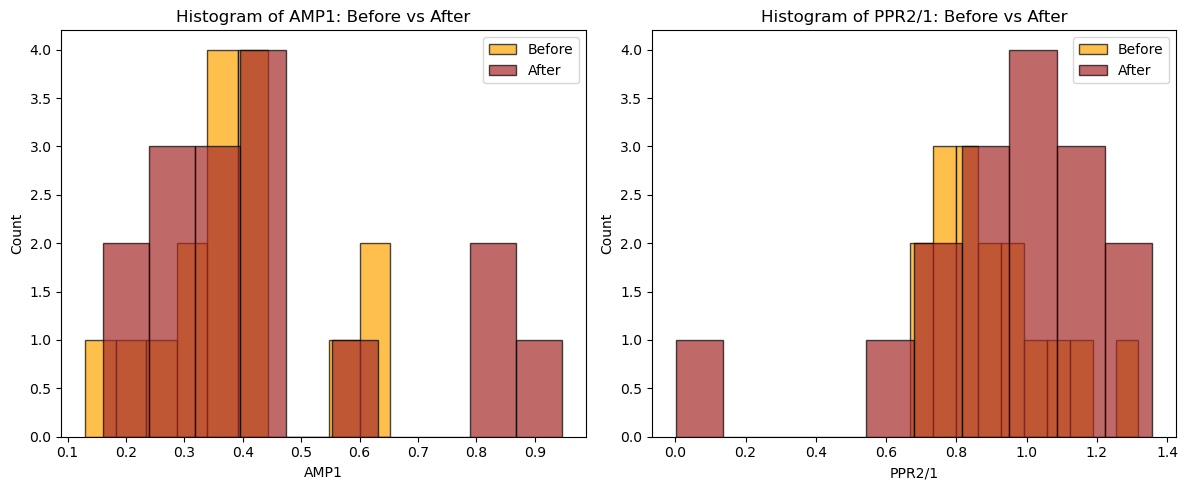

In [43]:
# Plot histograms of AMP1 and PPR2/1 values before and after
plt.figure(figsize=(12, 5))

# AMP1 histogram
plt.subplot(1, 2, 1)
plt.hist(df_stab_before['AMP1'], bins=10, alpha=0.7, label='Before', color='orange', edgecolor='black')
plt.hist(df_stab_after['AMP1'], bins=10, alpha=0.7, label='After', color='brown', edgecolor='black')
plt.xlabel('AMP1')
plt.ylabel('Count')
plt.title('Histogram of AMP1: Before vs After')
plt.legend()

# PPR2/1 histogram
plt.subplot(1, 2, 2)
plt.hist(df_stab_before['PPR2/1'], bins=10, alpha=0.7, label='Before', color='orange', edgecolor='black')
plt.hist(df_stab_after['PPR2/1'], bins=10, alpha=0.7, label='After', color='brown', edgecolor='black')
plt.xlabel('PPR2/1')
plt.ylabel('Count')
plt.title('Histogram of PPR2/1: Before vs After')
plt.legend()

plt.tight_layout()
plt.show()

Paired t-test AMP1: p = 0.3525
 * p < 0.05: False
 ** p < 0.01: False
 *** p < 0.001: False
Paired t-test PPR2/1: p = 0.9521
 * p < 0.05: False
 ** p < 0.01: False
 *** p < 0.001: False


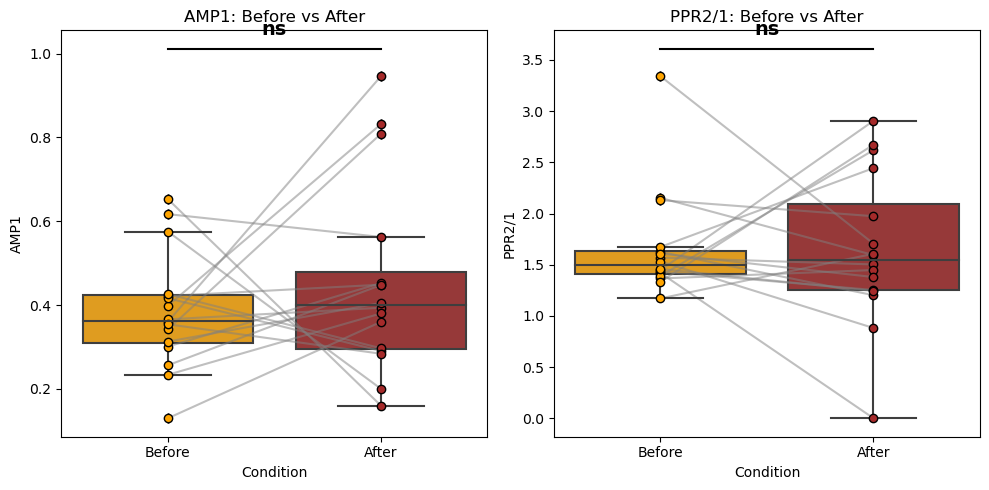

In [44]:
from scipy.stats import ttest_rel

# Boxplots comparing AMP1 and PPR2/1 before vs after, with all points and linking lines + paired t-test

# Load the original data for stability experiments (with AMP1 and PPR2/1 columns)
df_stab_before_full = pd.read_excel(
    r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx",
    sheet_name="Stability_Before"
)
df_stab_after_full = pd.read_excel(
    r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx",
    sheet_name="Stability_After"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Boxplot for AMP1
sns.boxplot(
    data=pd.DataFrame({
        'AMP1': pd.concat([df_stab_before_full['AMP1'], df_stab_after_full['AMP1']]).values,
        'Condition': ['Before'] * len(df_stab_before_full) + ['After'] * len(df_stab_after_full)
    }),
    x='Condition', y='AMP1', ax=ax1, palette=['orange', 'brown']
)
ax1.set_title('AMP1: Before vs After')
ax1.set_ylabel('AMP1')

# Overlay all points and link them
for i in range(min(len(df_stab_before_full), len(df_stab_after_full))):
    ax1.plot([0, 1], [df_stab_before_full['AMP1'].iloc[i], df_stab_after_full['AMP1'].iloc[i]],
             color='gray', alpha=0.5, zorder=1)
ax1.scatter(np.zeros(len(df_stab_before_full)), df_stab_before_full['AMP1'], color='orange', edgecolor='k', zorder=2)
ax1.scatter(np.ones(len(df_stab_after_full)), df_stab_after_full['AMP1'], color='brown', edgecolor='k', zorder=2)

# Paired t-test for AMP1
stat_amp1, p_amp1 = ttest_rel(df_stab_before_full['AMP1'], df_stab_after_full['AMP1'])
print(f"Paired t-test AMP1: p = {p_amp1:.4g}")
print(f" * p < 0.05: {p_amp1 < 0.05}")
print(f" ** p < 0.01: {p_amp1 < 0.01}")
print(f" *** p < 0.001: {p_amp1 < 0.001}")

def get_sigstars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

y_max_amp1 = max(df_stab_before_full['AMP1'].max(), df_stab_after_full['AMP1'].max())
y_min_amp1 = min(df_stab_before_full['AMP1'].min(), df_stab_after_full['AMP1'].min())
y_sig_amp1 = y_max_amp1 + 0.08 * (y_max_amp1 - y_min_amp1)
ax1.plot([0, 1], [y_sig_amp1, y_sig_amp1], color='black', lw=1.5)
ax1.text(0.5, y_sig_amp1 + 0.03 * (y_max_amp1 - y_min_amp1), get_sigstars(p_amp1),
         ha='center', va='bottom', fontsize=14, fontweight='bold')

# Boxplot for PPR2/1
sns.boxplot(
    data=pd.DataFrame({
        'PPR2/1': pd.concat([df_stab_before_full['PPR2/1'], df_stab_after_full['PPR2/1']]).values,
        'Condition': ['Before'] * len(df_stab_before_full) + ['After'] * len(df_stab_after_full)
    }),
    x='Condition', y='PPR2/1', ax=ax2, palette=['orange', 'brown']
)
ax2.set_title('PPR2/1: Before vs After')
ax2.set_ylabel('PPR2/1')

for i in range(min(len(df_stab_before_full), len(df_stab_after_full))):
    ax2.plot([0, 1], [df_stab_before_full['PPR2/1'].iloc[i], df_stab_after_full['PPR2/1'].iloc[i]],
             color='gray', alpha=0.5, zorder=1)
ax2.scatter(np.zeros(len(df_stab_before_full)), df_stab_before_full['PPR2/1'], color='orange', edgecolor='k', zorder=2)
ax2.scatter(np.ones(len(df_stab_after_full)), df_stab_after_full['PPR2/1'], color='brown', edgecolor='k', zorder=2)

# Paired t-test for PPR2/1
stat_ppr, p_ppr = ttest_rel(df_stab_before_full['PPR2/1'], df_stab_after_full['PPR2/1'])
print(f"Paired t-test PPR2/1: p = {p_ppr:.4g}")
print(f" * p < 0.05: {p_ppr < 0.05}")
print(f" ** p < 0.01: {p_ppr < 0.01}")
print(f" *** p < 0.001: {p_ppr < 0.001}")

y_max_ppr = max(df_stab_before_full['PPR2/1'].max(), df_stab_after_full['PPR2/1'].max())
y_min_ppr = min(df_stab_before_full['PPR2/1'].min(), df_stab_after_full['PPR2/1'].min())
y_sig_ppr = y_max_ppr + 0.08 * (y_max_ppr - y_min_ppr)
ax2.plot([0, 1], [y_sig_ppr, y_sig_ppr], color='black', lw=1.5)
ax2.text(0.5, y_sig_ppr + 0.03 * (y_max_ppr - y_min_ppr), get_sigstars(p_ppr),
         ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

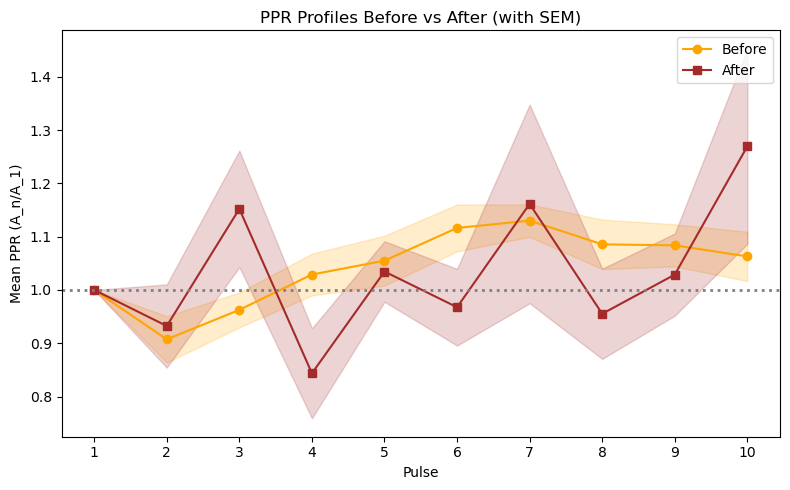

In [45]:
# Plot PPR profiles (with SEM) for before and after conditions using PCA-transformed data

# Define PPR columns (assume same as used elsewhere)
ppr_cols = [f'PPR{i}/1' for i in range(2, 11) if f'PPR{i}/1' in df_stab_before.columns]
x_pulses = list(range(1, len(ppr_cols) + 2))  # 1 to 10

# Calculate means and SEMs for before
means_before = [1] + df_stab_before[ppr_cols].mean().tolist()
sems_before = [0] + df_stab_before[ppr_cols].sem().tolist()

# Calculate means and SEMs for after
means_after = [1] + df_stab_after[ppr_cols].mean().tolist()
sems_after = [0] + df_stab_after[ppr_cols].sem().tolist()

plt.figure(figsize=(8, 5))
plt.plot(x_pulses, means_before, marker='o', color='orange', label='Before')
plt.fill_between(x_pulses, np.array(means_before) - np.array(sems_before),
                 np.array(means_before) + np.array(sems_before), color='orange', alpha=0.2)
plt.plot(x_pulses, means_after, marker='s', color='brown', label='After')
plt.fill_between(x_pulses, np.array(means_after) - np.array(sems_after),
                 np.array(means_after) + np.array(sems_after), color='brown', alpha=0.2)
plt.axhline(1, color='gray', linestyle='dotted', linewidth=2)
plt.xlabel('Pulse')
plt.ylabel('Mean PPR (A_n/A_1)')
plt.title('PPR Profiles Before vs After (with SEM)')
plt.xticks(x_pulses, [str(i) for i in x_pulses])
plt.legend()
plt.tight_layout()
plt.show()


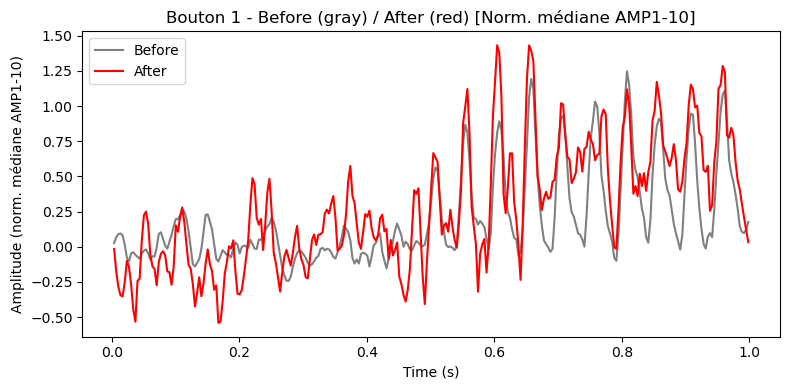

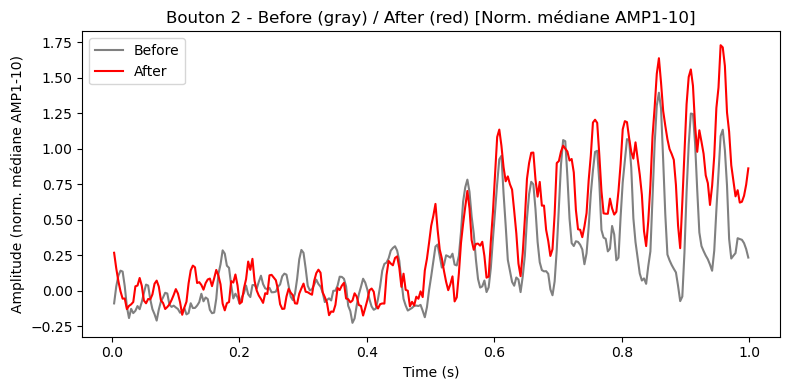

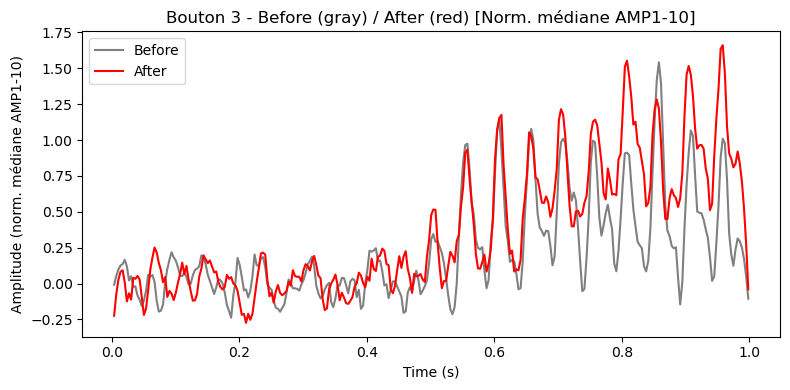

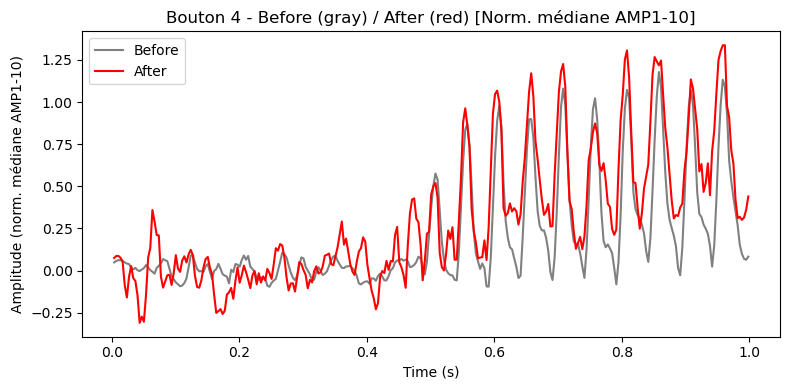

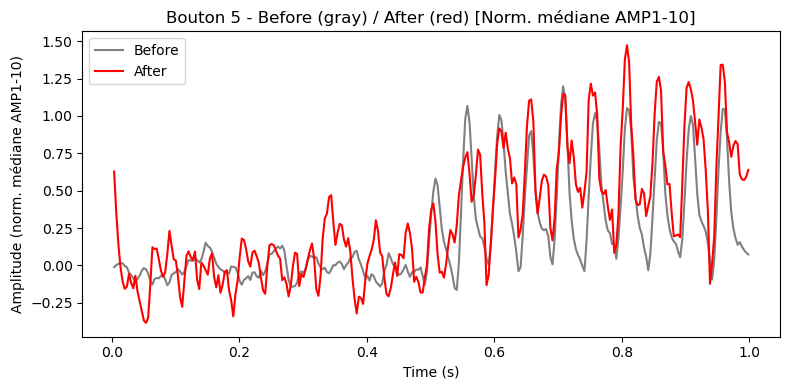

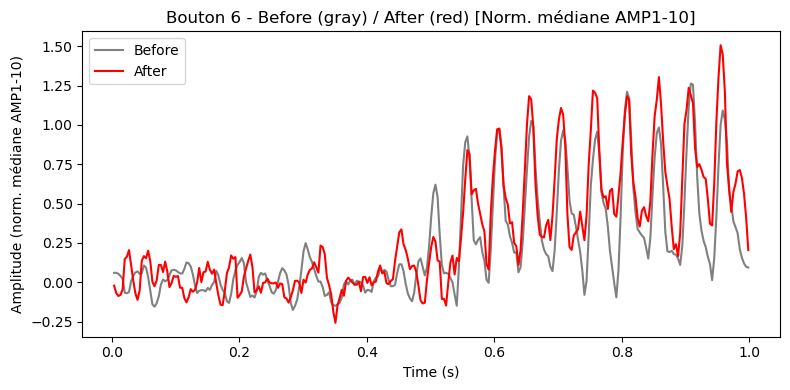

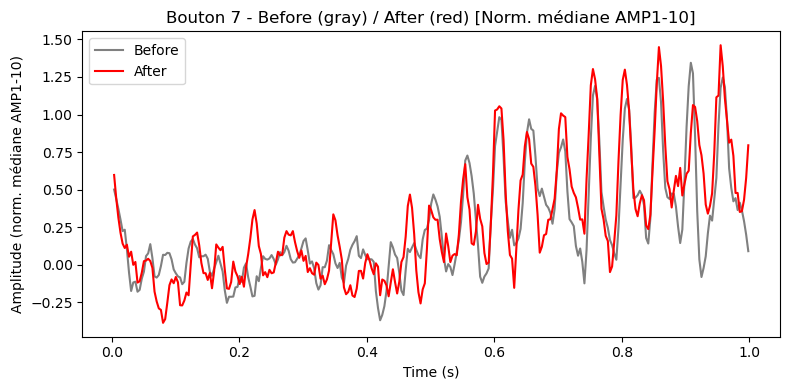

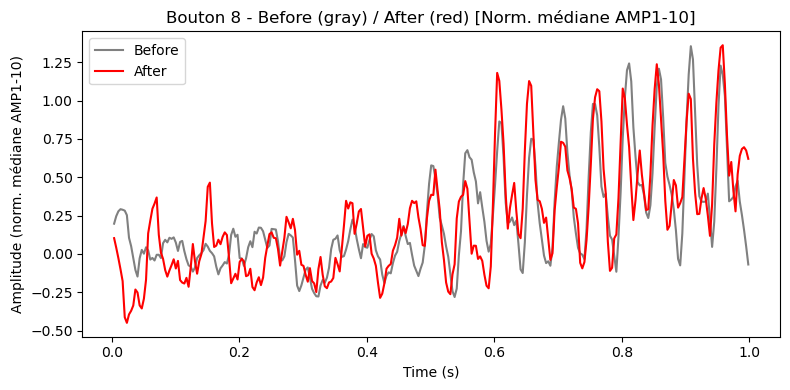

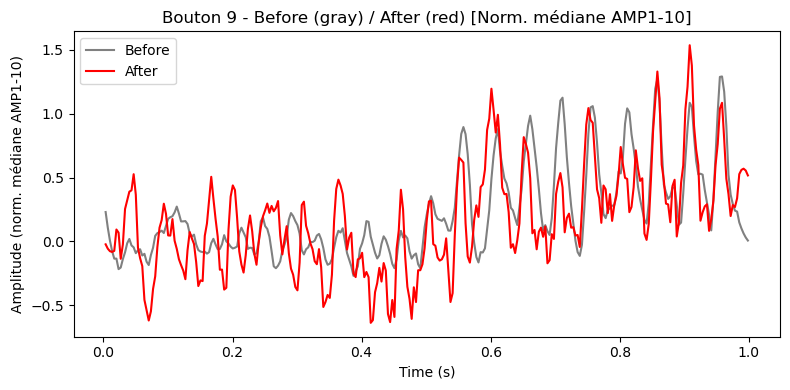

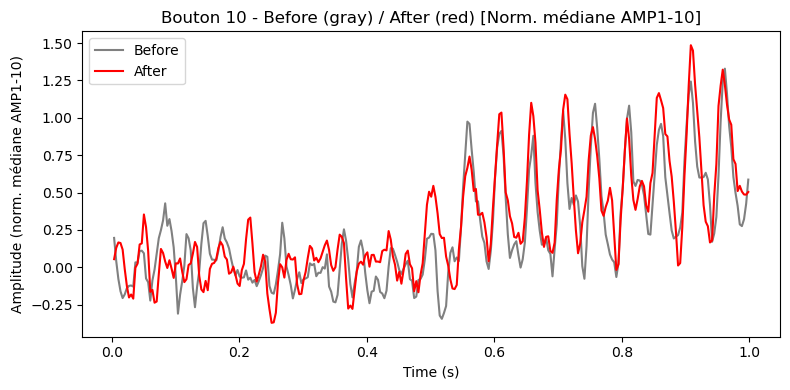

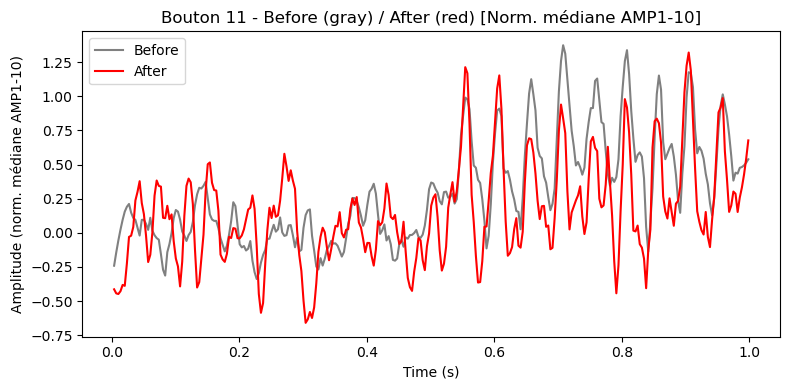

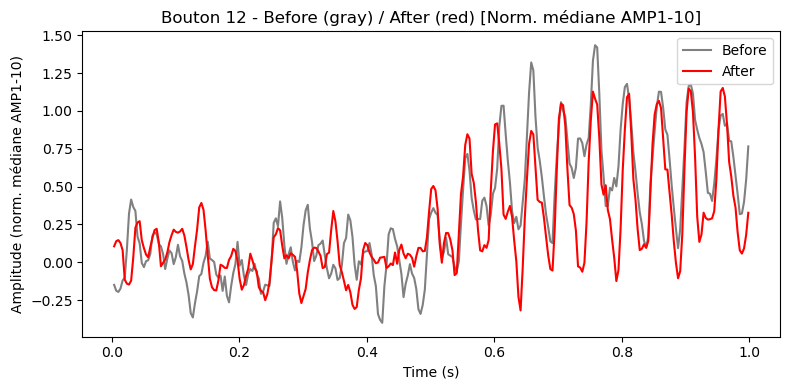

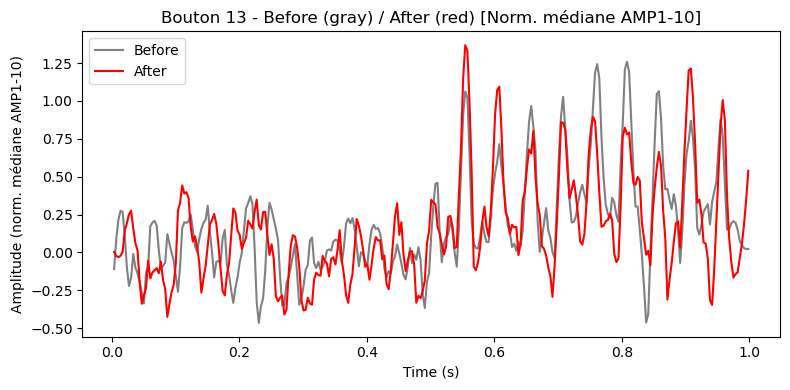

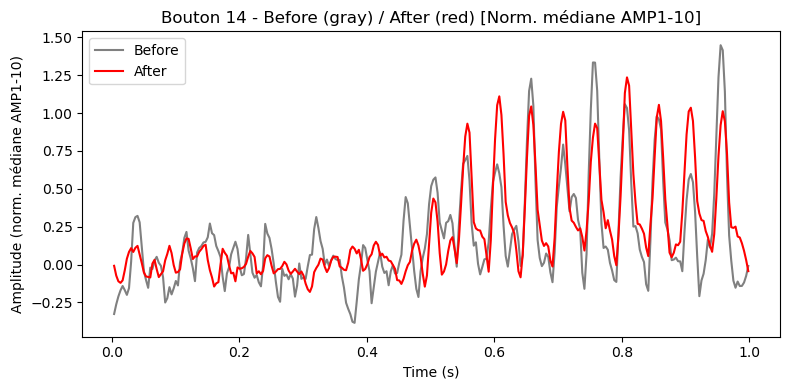

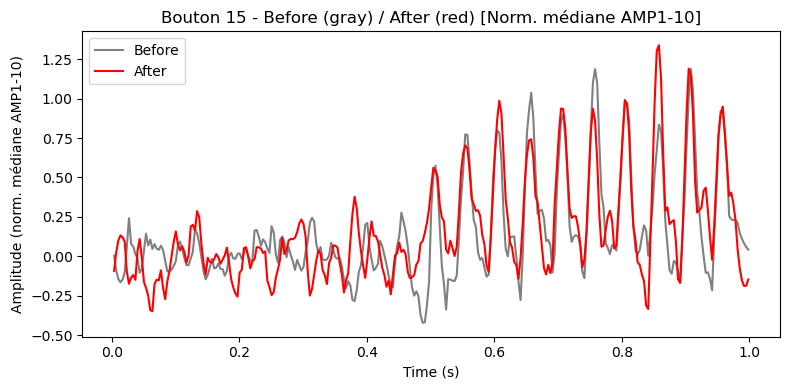

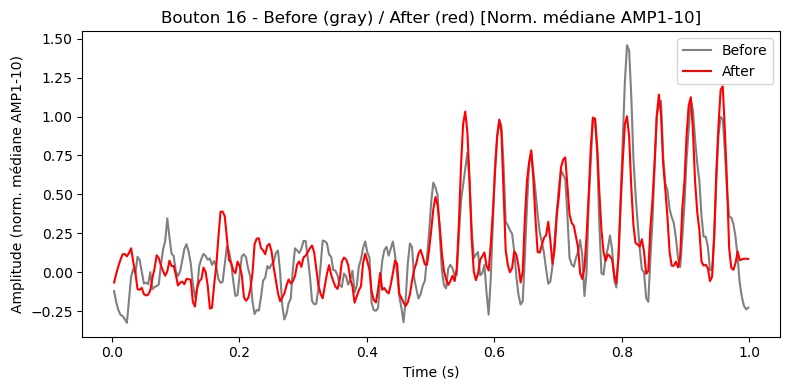

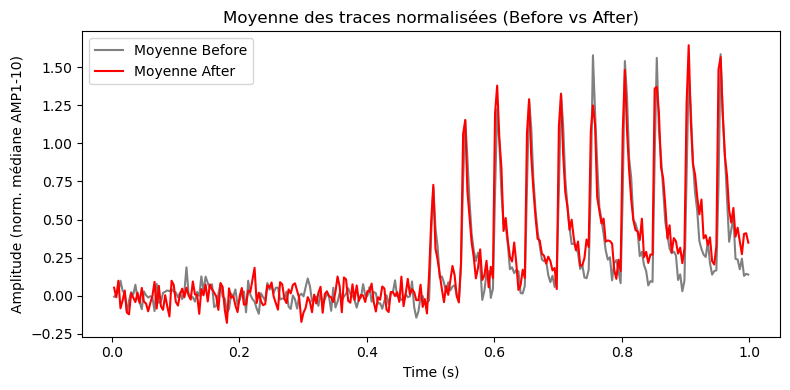

In [46]:
from scipy.signal import savgol_filter

# Charger les fichiers de traces et d'amplitudes
test_before = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name='Stability_Before')
test_after = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\All_traces.xlsx', sheet_name='Stability_After')
amp_before = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Data_Anthime_no_boot.xlsx', sheet_name='Stability_Before')
amp_after = pd.read_excel(r'C:\Anthime.PERROT\1_Thèse\1_Manip\5_Glusnf_Théo\2_Revision\Final_Files\Data_Anthime_no_boot.xlsx', sheet_name='Stability_After')

# Extraire le vecteur temps
time = test_before.iloc[1:, 0].astype(float).values
n_pairs = min(test_before.shape[1] - 1, test_after.shape[1] - 1, amp_before.shape[0], amp_after.shape[0])

amp_cols = [f'AMP{i}' for i in range(1, 11)]

for i in range(n_pairs):
    trace_before = test_before.iloc[1:, i + 1].astype(float).values
    trace_after = test_after.iloc[1:, i + 1].astype(float).values

    # Normalisation par la médiane des 10 amplitudes
    norm_b = np.mean(amp_before.loc[i, amp_cols])
    norm_a = np.mean(amp_after.loc[i, amp_cols])
    if norm_b != 0:
        trace_before = trace_before / norm_b
    if norm_a != 0:
        trace_after = trace_after / norm_a

    # Lissage
    trace_before_smooth = savgol_filter(trace_before, window_length=9, polyorder=2)
    trace_after_smooth = savgol_filter(trace_after, window_length=9, polyorder=2)

    plt.figure(figsize=(8, 4))
    plt.plot(time, trace_before_smooth, color='gray', label='Before')
    plt.plot(time, trace_after_smooth, color='red', label='After')
    plt.title(f'Bouton {i+1} - Before (gray) / After (red) [Norm. médiane AMP1-10]')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (norm. médiane AMP1-10)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Calculer la moyenne des traces normalisées pour chaque condition
    if i == 0:
        all_traces_before = []
        all_traces_after = []
    all_traces_before.append(trace_before)
    all_traces_after.append(trace_after)

    # À la fin de la boucle, afficher la moyenne des traces normalisées
    if i == n_pairs - 1:
        mean_before = np.mean(np.stack(all_traces_before), axis=0)
        mean_after = np.mean(np.stack(all_traces_after), axis=0)
        plt.figure(figsize=(8, 4))
        plt.plot(time, mean_before, color='gray', label='Moyenne Before')
        plt.plot(time, mean_after, color='red', label='Moyenne After')
        plt.title("Moyenne des traces normalisées (Before vs After)")
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude (norm. médiane AMP1-10)')
        plt.legend()
        plt.tight_layout()
        plt.show()


# Chaines de boutons.

Pour voir la répartition des boutons d'une même fibre dans les clusters.

In [47]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
import numpy as np

# Use the already imported dataframes with fiber ID columns
# Add fiber ID columns to each dataset
def get_fiber_id(full_id, dataset_type):
    if dataset_type == 'SynII':
        return full_id[:13]
    elif dataset_type == 'WT_Anthime':
        return full_id[:22]
    elif dataset_type == 'WT_Theo':
        return full_id[:18]
    else:
        return full_id

# Reload original dataframes with ID columns intact (since they were dropped earlier)
df_SynII_with_fiber = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="SynII")
df_WT_Anthime_with_fiber = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="WT_Anthime")
df_WT_Theo_with_fiber = pd.read_excel(r"C:\Users\Anthime.PERROT\Downloads\ppr_results.xlsx", sheet_name="WT_Theo")

# Add fiber ID columns
df_SynII_with_fiber['Fiber_ID'] = df_SynII_with_fiber['ID'].apply(lambda x: get_fiber_id(x, 'SynII'))
df_WT_Anthime_with_fiber['Fiber_ID'] = df_WT_Anthime_with_fiber['ID'].apply(lambda x: get_fiber_id(x, 'WT_Anthime'))
df_WT_Theo_with_fiber['Fiber_ID'] = df_WT_Theo_with_fiber['ID'].apply(lambda x: get_fiber_id(x, 'WT_Theo'))

# Combine all datasets with their types
all_data = []

# Add SynII data
for i, row in df_SynII_with_fiber.iterrows():
    if i < transformed_data_SynII.shape[0]:  # Check bounds
        all_data.append({
            'ID': row['ID'],
            'PC1': transformed_data_SynII[i, 0],
            'PC2': transformed_data_SynII[i, 1],
            'dataset': 'SynII',
            'fiber_id': row['Fiber_ID'],
            'color': 'orange',
            'marker': '*'
        })

# Add WT_Anthime data
for i, row in df_WT_Anthime_with_fiber.iterrows():
    if i < transformed_data_WT_Anthime.shape[0]:  # Check bounds
        all_data.append({
            'ID': row['ID'],
            'PC1': transformed_data_WT_Anthime[i, 0],
            'PC2': transformed_data_WT_Anthime[i, 1],
            'dataset': 'WT_Anthime',
            'fiber_id': row['Fiber_ID'],
            'color': 'lightgreen',
            'marker': 's'
        })

# Add WT_Theo data
for i, row in df_WT_Theo_with_fiber.iterrows():
    if i < transformed_data_WT_Theo.shape[0]:  # Check bounds
        all_data.append({
            'ID': row['ID'],
            'PC1': transformed_data_WT_Theo[i, 0],
            'PC2': transformed_data_WT_Theo[i, 1],
            'dataset': 'WT_Theo',
            'fiber_id': row['Fiber_ID'],
            'color': 'blue',
            'marker': 'o'
        })

# Group by fiber ID
fibers = {}
for data_point in all_data:
    fiber_id = data_point['fiber_id']
    if fiber_id not in fibers:
        fibers[fiber_id] = []
    fibers[fiber_id].append(data_point)

# Filter fibers with more than 1 bouton
fibers_multi = {k: v for k, v in fibers.items() if len(v) > 1}
fiber_list = list(fibers_multi.keys())

print(f"Found {len(fiber_list)} fibers with multiple boutons")

# Create interactive plot
class FiberNavigator:
    def __init__(self, fibers_dict, fiber_list):
        self.fibers = fibers_dict
        self.fiber_list = fiber_list
        self.current_index = 0
        
        # Create figure and axis
        self.fig, self.ax = plt.subplots(figsize=(12, 8))
        self.fig.subplots_adjust(bottom=0.2)
        
        # Add navigation buttons
        ax_prev = plt.axes([0.3, 0.05, 0.1, 0.075])
        ax_next = plt.axes([0.6, 0.05, 0.1, 0.075])
        self.btn_prev = Button(ax_prev, 'Previous')
        self.btn_next = Button(ax_next, 'Next')
        
        self.btn_prev.on_clicked(self.prev_fiber)
        self.btn_next.on_clicked(self.next_fiber)
        
        # Connect keyboard events
        self.fig.canvas.mpl_connect('key_press_event', self.on_key_press)
        
        # Initial plot
        self.update_plot()
        
    def prev_fiber(self, event=None):
        if self.current_index > 0:
            self.current_index -= 1
            self.update_plot()
    
    def next_fiber(self, event=None):
        if self.current_index < len(self.fiber_list) - 1:
            self.current_index += 1
            self.update_plot()
    
    def on_key_press(self, event):
        if event.key == 'left':
            self.prev_fiber()
        elif event.key == 'right':
            self.next_fiber()
    
    def update_plot(self):
        self.ax.clear()
        
        # Plot background PCA data (WT pooled)
        self.ax.scatter(transformed_WT_pooled['PC1'], transformed_WT_pooled['PC2'], 
                       c=colors_umap, alpha=0.3, s=30, label='WT pooled background')
        
        # Get current fiber data
        current_fiber_id = self.fiber_list[self.current_index]
        current_fiber_data = self.fibers[current_fiber_id]
        
        # Sort boutons by ID to maintain order along the fiber
        current_fiber_data.sort(key=lambda x: x['ID'])
        
        # Extract coordinates
        x_coords = [point['PC1'] for point in current_fiber_data]
        y_coords = [point['PC2'] for point in current_fiber_data]
        
        # Plot connection lines
        self.ax.plot(x_coords, y_coords, 'r-', linewidth=2, alpha=0.8, label='Fiber connection')
        
        # Plot boutons with numbers
        for i, point in enumerate(current_fiber_data):
            self.ax.scatter(point['PC1'], point['PC2'], 
                           c=point['color'], marker=point['marker'], 
                           s=100, edgecolor='black', linewidth=1, zorder=5)
            
            # Add number annotation
            self.ax.annotate(str(i+1), (point['PC1'], point['PC2']), 
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=10, fontweight='bold', 
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Set labels and title
        self.ax.set_xlabel('PC1')
        self.ax.set_ylabel('PC2')
        self.ax.set_title(f'Fiber {self.current_index + 1}/{len(self.fiber_list)}: {current_fiber_id}\n'
                         f'Dataset: {current_fiber_data[0]["dataset"]} | '
                         f'Boutons: {len(current_fiber_data)}')
        
        # Add legend
        self.ax.legend(loc='upper right')
        
        # Add navigation info
        self.fig.suptitle('Use LEFT/RIGHT arrows or buttons to navigate between fibers', 
                         fontsize=12, y=0.95)
        
        # Refresh plot
        self.fig.canvas.draw()

# Create and show the navigator in a new window
if len(fiber_list) > 0:
    # Force matplotlib to use a GUI backend for interactive window
    import matplotlib
    matplotlib.use('Qt5Agg')  # or 'TkAgg' if Qt5Agg is not available
    
    navigator = FiberNavigator(fibers_multi, fiber_list)
    
    # Set window title (handle different backends)
    try:
        # For Qt5Agg backend
        navigator.fig.canvas.manager.set_window_title("Fiber Navigator - Interactive Bouton Visualization")
    except AttributeError:
        try:
            # Alternative for other backends
            navigator.fig.canvas.manager.window.setWindowTitle("Fiber Navigator - Interactive Bouton Visualization")
        except AttributeError:
            # If neither works, just continue without setting title
            print("Window title could not be set, but the interactive window will still work")
    
    # Show the figure in a new window
    navigator.fig.show()
    
    # Keep the window open
    plt.show(block=True)
else:
    print("No fibers with multiple boutons found")

Found 55 fibers with multiple boutons


In [48]:
# Fix matplotlib backend to enable figure display
import matplotlib
import matplotlib.pyplot as plt
import warnings

# Set matplotlib to use a GUI backend that can display figures
matplotlib.use('Qt5Agg')  # Use Qt5Agg backend for interactive display

# Configure matplotlib for notebook display
%matplotlib inline

# Re-enable interactive mode and clear warnings
plt.ion()
plt.close('all')
plt.rcdefaults()
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

print("✓ Matplotlib backend configured for figure display")
print(f"✓ Current backend: {matplotlib.get_backend()}")
print("✓ Figures should now display properly in the notebook")

✓ Matplotlib backend configured for figure display
✓ Current backend: module://matplotlib_inline.backend_inline
✓ Figures should now display properly in the notebook


## Analyse des distances entre boutons dans l'espace PCA

Cette section compare les distributions de distances entre boutons pour évaluer si les boutons adjacents le long d'une même fibre présentent des propriétés fonctionnelles plus similaires que des boutons choisis au hasard.

### Hypothèse testée

L'hypothèse est que les boutons adjacents sur une même fibre axonale devraient avoir des propriétés fonctionnelles plus similaires (distances plus courtes dans l'espace PCA) que des boutons pris au hasard, reflétant une organisation fonctionnelle locale le long des fibres.

### Méthodologie

**Distances analysées :**
- **Distances toutes paires** : Distances euclidiennes entre tous les boutons dans l'espace PCA (distribution de référence)
- **Distances adjacentes** : Distances entre boutons consécutifs le long de chaque fibre (triés par ID)

**Test statistique :** Test de Kolmogorov-Smirnov pour comparer les deux distributions de distances.

Cette analyse permet de déterminer si l'organisation spatiale des boutons le long des fibres reflète une organisation fonctionnelle, avec des boutons adjacents partageant des propriétés de libération similaires.

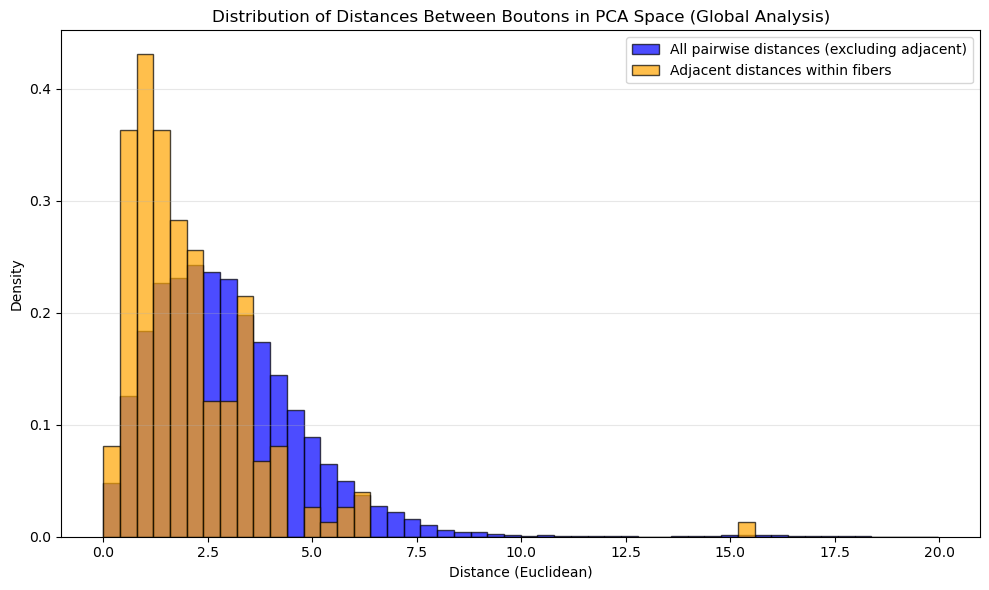

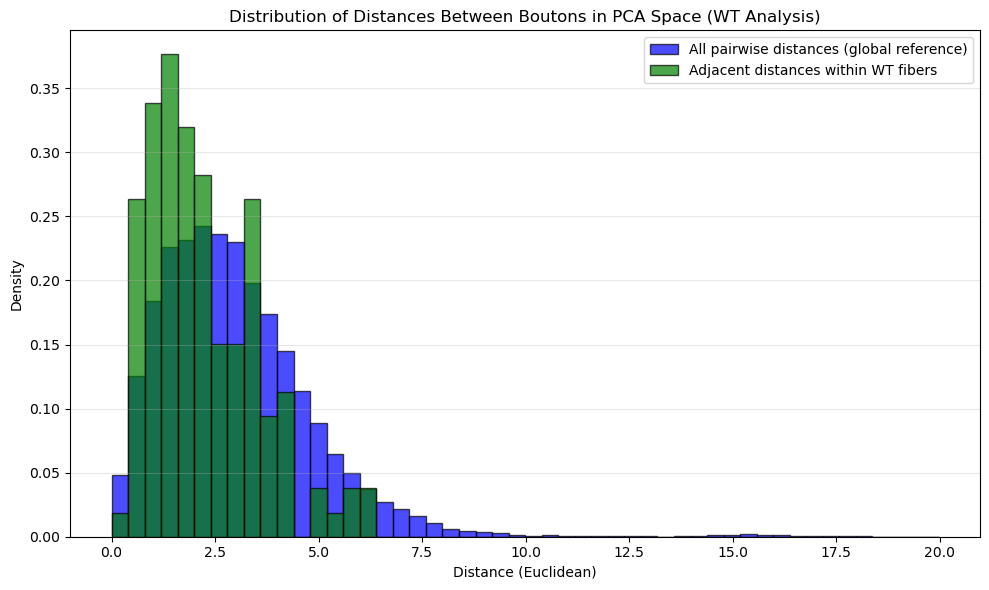

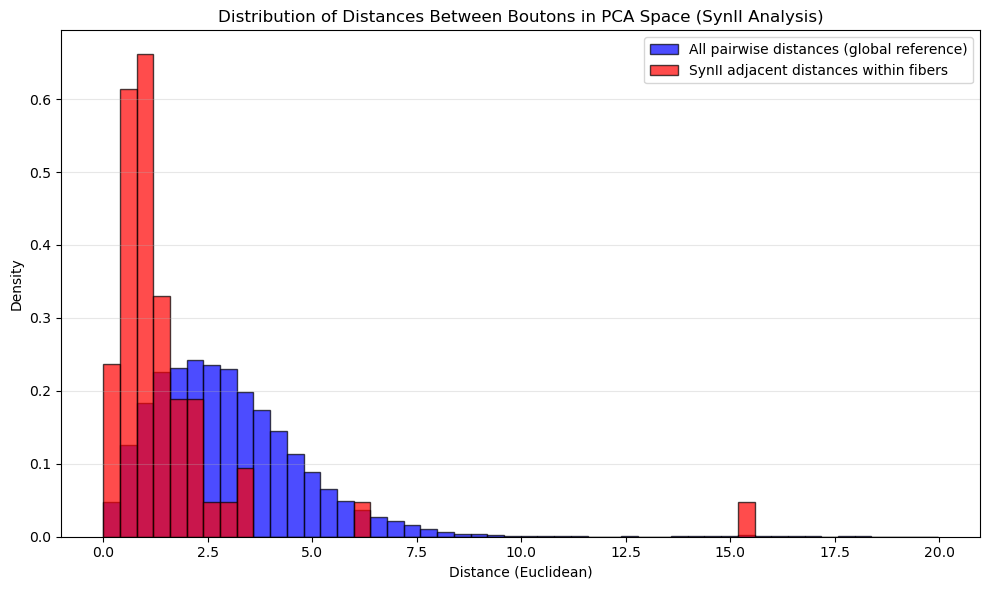

Analyses des distances terminées. Figures et résultats sauvegardés.
Fichiers sauvegardés:
  - 24_global_distance_analysis.txt
  - 25_wt_distance_analysis.txt
  - 26_synii_distance_analysis.txt


In [49]:
# Analyse des distances entre boutons dans l'espace PCA
from scipy.spatial import distance
from scipy.stats import ks_2samp
import io
import sys

def calculate_distance_distribution_excluding_adjacent(coordinates, fiber_info=None):
    """
    Calculate distances between all boutons excluding adjacent ones within same fiber.
    """
    n_samples = coordinates.shape[0]
    distances = []
    
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            skip_pair = False
            if fiber_info is not None:
                fiber_i = fiber_info.get(i)
                fiber_j = fiber_info.get(j)
                if fiber_i == fiber_j and fiber_i is not None and abs(i - j) == 1:
                    skip_pair = True
            
            if not skip_pair:
                dist = np.linalg.norm(coordinates[j] - coordinates[i])
                distances.append(dist)
    
    return np.array(distances)

def calculate_adjacent_distances(datasets_info):
    """
    Calculate distances between adjacent boutons within fibers.
    datasets_info: list of (dataframe, coordinates, name) tuples
    """
    all_adjacent = []
    wt_adjacent = []
    
    for df, coords, name in datasets_info:
        for fiber_id, fiber_group in df.groupby('Fiber_ID'):
            if len(fiber_group) > 1:
                indices = fiber_group.index.tolist()
                for i in range(len(indices) - 1):
                    coord1 = coords[indices[i]]
                    coord2 = coords[indices[i + 1]]
                    dist = np.linalg.norm(coord2 - coord1)
                    all_adjacent.append(dist)
                    if 'WT' in name:
                        wt_adjacent.append(dist)
    
    return all_adjacent, wt_adjacent

# Prepare data
datasets_info = [
    (df_SynII_with_fiber, transformed_data_SynII, 'SynII'),
    (df_WT_Anthime_with_fiber, transformed_data_WT_Anthime, 'WT_Anthime'),
    (df_WT_Theo_with_fiber, transformed_data_WT_Theo, 'WT_Theo')
]

# Calculate distances
all_adjacent_distances, wt_adjacent_distances = calculate_adjacent_distances(datasets_info)

# Create combined coordinates for global reference
all_coordinates = np.vstack([
    transformed_data_WT_pooled,
    transformed_data_SynII,
    transformed_data_WT_Anthime,
    transformed_data_WT_Theo
])

# Create combined fiber info
all_fiber_info = {}
idx = 0
for coords, df, prefix in [(transformed_data_WT_pooled, df_WT_poolclust, 'WT_pooled'),
                           (transformed_data_SynII, df_SynII_with_fiber, 'SynII'),
                           (transformed_data_WT_Anthime, df_WT_Anthime_with_fiber, 'WT_Anthime'),
                           (transformed_data_WT_Theo, df_WT_Theo_with_fiber, 'WT_Theo')]:
    for i, fiber_id in enumerate(df['Fiber_ID']):
        if idx + i < len(all_coordinates):
            all_fiber_info[idx + i] = f"{prefix}_{fiber_id}"
    idx += len(coords)

# Calculate global pairwise distances (excluding adjacent)
global_pairwise_distances = calculate_distance_distribution_excluding_adjacent(all_coordinates, all_fiber_info)

# Calculate SynII adjacent distances
synii_adjacent_distances = []
for fiber_id, fiber_group in df_SynII_with_fiber.groupby('Fiber_ID'):
    if len(fiber_group) > 1:
        indices = fiber_group.index.tolist()
        for i in range(len(indices) - 1):
            coord1 = transformed_data_SynII[indices[i]]
            coord2 = transformed_data_SynII[indices[i + 1]]
            dist = np.linalg.norm(coord2 - coord1)
            synii_adjacent_distances.append(dist)

# Calculate bin edges for consistent plotting
all_distances_combined = np.concatenate([
    global_pairwise_distances, all_adjacent_distances, 
    wt_adjacent_distances, synii_adjacent_distances
])
bin_edges = np.linspace(np.min(all_distances_combined), np.max(all_distances_combined), 51)

# Function to save results
def save_results_to_file(filename, results_text):
    """Save analysis results to text file"""
    with open(os.path.join(output_dir, filename), 'w', encoding='utf-8') as f:
        f.write(results_text)

# Function to capture print output
def capture_prints(func):
    """Capture print statements from a function"""
    old_stdout = sys.stdout
    sys.stdout = buffer = io.StringIO()
    try:
        result = func()
        output = buffer.getvalue()
    finally:
        sys.stdout = old_stdout
    return result, output

# ============================================================================
# FIGURE 24: Analyse globale des distances (tous datasets)
# ============================================================================

def analyze_global_distances():
    results = []
    
    plt.figure(figsize=(10, 6))
    
    # Plot global pairwise distances
    plt.hist(global_pairwise_distances, bins=bin_edges, color='blue', alpha=0.7, 
             edgecolor='black', label='All pairwise distances (excluding adjacent)', density=True)
    
    # Plot adjacent distances
    plt.hist(all_adjacent_distances, bins=bin_edges, color='orange', alpha=0.7, 
             edgecolor='black', label='Adjacent distances within fibers', density=True)
    
    plt.title('Distribution of Distances Between Boutons in PCA Space (Global Analysis)')
    plt.xlabel('Distance (Euclidean)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "24_global_distance_analysis.pdf"))
    plt.show()
    
    # Statistical analysis
    results.append("=== ANALYSE GLOBALE DES DISTANCES ===")
    results.append(f"Distances toutes paires (excluant adjacentes): n={len(global_pairwise_distances)}")
    results.append(f"  Moyenne: {np.mean(global_pairwise_distances):.3f}")
    results.append(f"  Écart-type: {np.std(global_pairwise_distances):.3f}")
    results.append(f"  Min-Max: {np.min(global_pairwise_distances):.3f} - {np.max(global_pairwise_distances):.3f}")
    
    results.append(f"\nDistances adjacentes dans fibres: n={len(all_adjacent_distances)}")
    results.append(f"  Moyenne: {np.mean(all_adjacent_distances):.3f}")
    results.append(f"  Écart-type: {np.std(all_adjacent_distances):.3f}")
    results.append(f"  Min-Max: {np.min(all_adjacent_distances):.3f} - {np.max(all_adjacent_distances):.3f}")
    
    # Statistical test
    ks_stat, ks_p = ks_2samp(global_pairwise_distances, all_adjacent_distances)
    results.append(f"\nTest de Kolmogorov-Smirnov:")
    results.append(f"  Statistique: {ks_stat:.3f}")
    results.append(f"  p-value: {ks_p:.3e}")
    results.append(f"  Significatif: {'Oui' if ks_p < 0.05 else 'Non'} (p < 0.05)")
    
    return "\n".join(results)

# Execute analysis and save results
results_global = analyze_global_distances()
save_results_to_file("24_global_distance_analysis.txt", results_global)


# ============================================================================
# FIGURE 25: Analyse WT seulement
# ============================================================================

def analyze_wt_distances():
    results = []
    
    plt.figure(figsize=(10, 6))
    
    # Plot global reference distances
    plt.hist(global_pairwise_distances, bins=bin_edges, color='blue', alpha=0.7, 
             edgecolor='black', label='All pairwise distances (global reference)', density=True)
    
    # Plot WT adjacent distances
    plt.hist(wt_adjacent_distances, bins=bin_edges, color='green', alpha=0.7, 
             edgecolor='black', label='Adjacent distances within WT fibers', density=True)
    
    plt.title('Distribution of Distances Between Boutons in PCA Space (WT Analysis)')
    plt.xlabel('Distance (Euclidean)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "25_wt_distance_analysis.pdf"))
    plt.show()
    
    # Statistical analysis
    results.append("=== ANALYSE WT SEULEMENT ===")
    results.append(f"Distances de référence globales: n={len(global_pairwise_distances)}")
    results.append(f"  Moyenne: {np.mean(global_pairwise_distances):.3f}")
    results.append(f"  Écart-type: {np.std(global_pairwise_distances):.3f}")
    
    results.append(f"\nDistances adjacentes WT: n={len(wt_adjacent_distances)}")
    results.append(f"  Moyenne: {np.mean(wt_adjacent_distances):.3f}")
    results.append(f"  Écart-type: {np.std(wt_adjacent_distances):.3f}")
    results.append(f"  Min-Max: {np.min(wt_adjacent_distances):.3f} - {np.max(wt_adjacent_distances):.3f}")
    
    # Statistical test
    ks_stat, ks_p = ks_2samp(global_pairwise_distances, wt_adjacent_distances)
    results.append(f"\nTest de Kolmogorov-Smirnov:")
    results.append(f"  Statistique: {ks_stat:.3f}")
    results.append(f"  p-value: {ks_p:.3e}")
    results.append(f"  Significatif: {'Oui' if ks_p < 0.05 else 'Non'} (p < 0.05)")
    
    return "\n".join(results)

# Execute analysis and save results
results_wt = analyze_wt_distances()
save_results_to_file("25_wt_distance_analysis.txt", results_wt)


# ============================================================================
# FIGURE 26: Analyse SynII
# ============================================================================

def analyze_synii_distances():
    results = []
    
    plt.figure(figsize=(10, 6))
    
    # Plot global reference distances
    plt.hist(global_pairwise_distances, bins=bin_edges, color='blue', alpha=0.7, 
             edgecolor='black', label='All pairwise distances (global reference)', density=True)
    
    # Plot SynII adjacent distances (if any)
    if len(synii_adjacent_distances) > 0:
        plt.hist(synii_adjacent_distances, bins=bin_edges, color='red', alpha=0.7, 
                 edgecolor='black', label='SynII adjacent distances within fibers', density=True)
    
    plt.title('Distribution of Distances Between Boutons in PCA Space (SynII Analysis)')
    plt.xlabel('Distance (Euclidean)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "26_synii_distance_analysis.pdf"))
    plt.show()
    
    # Statistical analysis
    results.append("=== ANALYSE SynII ===")
    results.append(f"Distances de référence globales: n={len(global_pairwise_distances)}")
    results.append(f"  Moyenne: {np.mean(global_pairwise_distances):.3f}")
    results.append(f"  Écart-type: {np.std(global_pairwise_distances):.3f}")
    
    if len(synii_adjacent_distances) > 0:
        results.append(f"\nDistances adjacentes SynII: n={len(synii_adjacent_distances)}")
        results.append(f"  Moyenne: {np.mean(synii_adjacent_distances):.3f}")
        results.append(f"  Écart-type: {np.std(synii_adjacent_distances):.3f}")
        results.append(f"  Min-Max: {np.min(synii_adjacent_distances):.3f} - {np.max(synii_adjacent_distances):.3f}")
        
        # Statistical test
        ks_stat, ks_p = ks_2samp(global_pairwise_distances, synii_adjacent_distances)
        results.append(f"\nTest de Kolmogorov-Smirnov:")
        results.append(f"  Statistique: {ks_stat:.3f}")
        results.append(f"  p-value: {ks_p:.3e}")
        results.append(f"  Significatif: {'Oui' if ks_p < 0.05 else 'Non'} (p < 0.05)")
    else:
        results.append("\nAucune distance adjacente SynII trouvée")
        results.append("(Pas de fibres SynII avec boutons multiples)")
    
    return "\n".join(results)

# Execute analysis and save results
results_synii = analyze_synii_distances()
save_results_to_file("26_synii_distance_analysis.txt", results_synii)

print("Analyses des distances terminées. Figures et résultats sauvegardés.")
print(f"Fichiers sauvegardés:")
print(f"  - 24_global_distance_analysis.txt")
print(f"  - 25_wt_distance_analysis.txt") 
print(f"  - 26_synii_distance_analysis.txt")


    


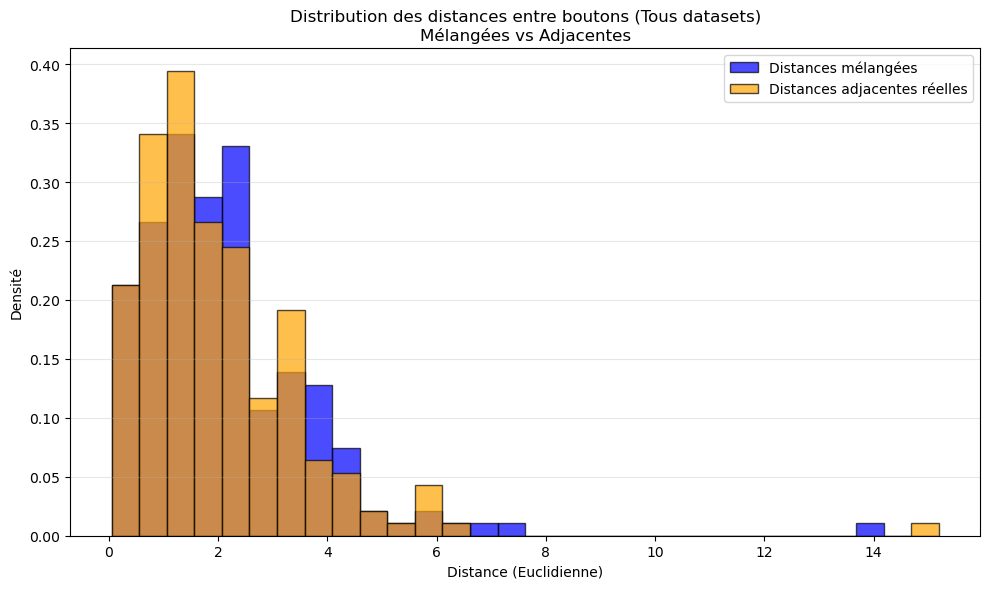

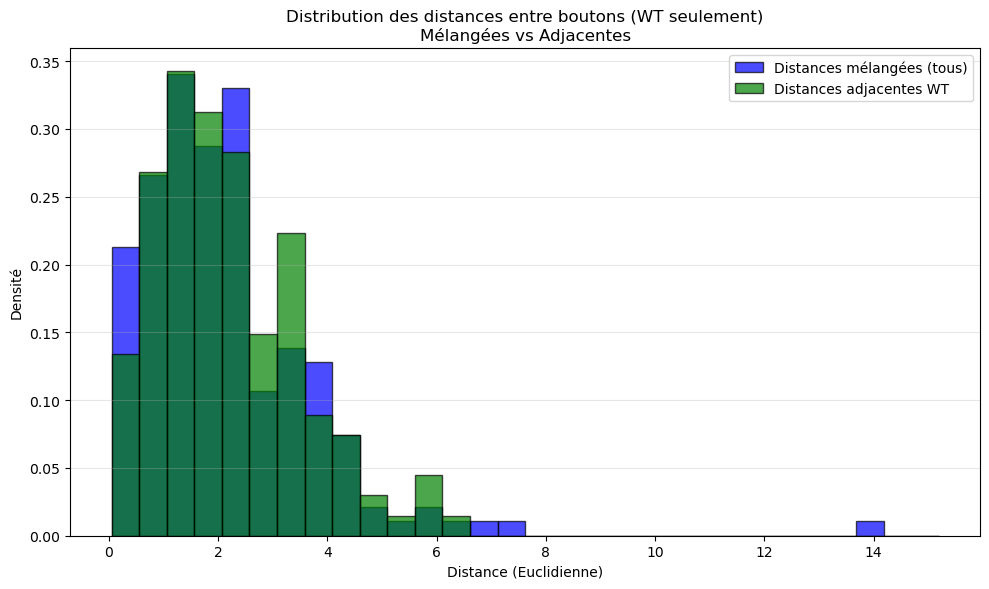

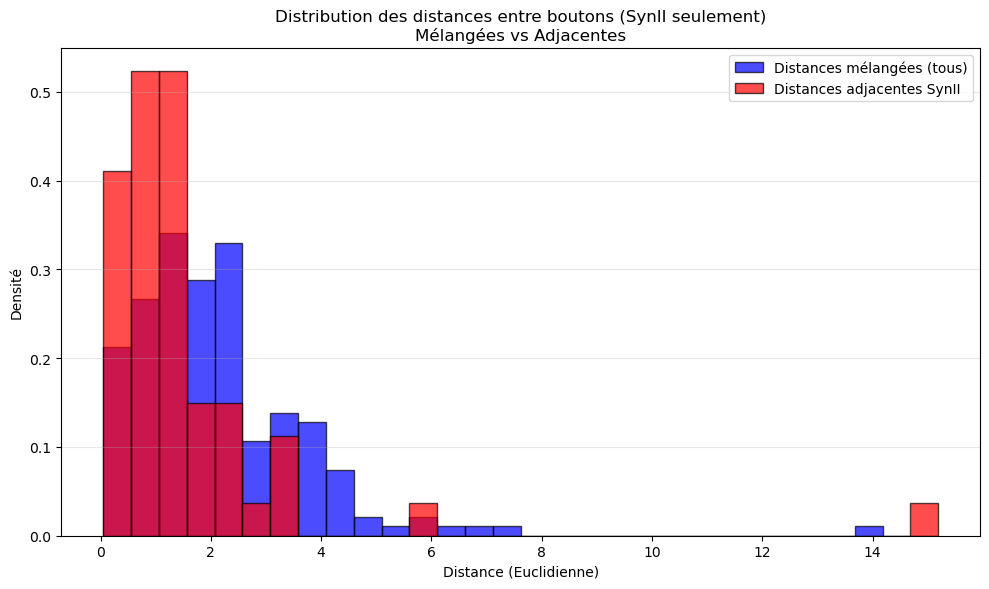

=== ANALYSE DES DISTANCES MÉLANGÉES VS ADJACENTES ===

TOUS DATASETS:
Distances mélangées: n=186
  Moyenne: 2.145
  Écart-type: 1.635
  Min-Max: 0.048 - 14.169

Distances adjacentes réelles: n=186
  Moyenne: 2.014
  Écart-type: 1.619
  Min-Max: 0.048 - 15.192

Test de Kolmogorov-Smirnov (tous datasets):
  Statistique: 0.086
  p-value: 4.980e-01
  Significatif: Non (p < 0.05)

WT SEULEMENT:
Fibres WT avec boutons multiples: 46
Total boutons WT en fibres multiples: 179
Distances adjacentes WT: n=133
  Moyenne: 2.193
  Écart-type: 1.304
  Min-Max: 0.388 - 6.185

Test de Kolmogorov-Smirnov (WT):
  Statistique: 0.070
  p-value: 8.056e-01
  Significatif: Non (p < 0.05)

SynII SEULEMENT:
Fibres SynII avec boutons multiples: 9
Total boutons SynII en fibres multiples: 62
Distances adjacentes SynII: n=53
  Moyenne: 1.564
  Écart-type: 2.156
  Min-Max: 0.048 - 15.192

Test de Kolmogorov-Smirnov (SynII):
  Statistique: 0.327
  p-value: 1.951e-04
  Significatif: Oui (p < 0.05)

Analyse terminée. Fi

In [50]:
# ============================================================================
# FIGURE 27: Analyse des distances mélangées vs adjacentes (tous datasets)
# ============================================================================

import random
from scipy.stats import ks_2samp
import io
import sys

def capture_and_save_prints(func, filename):
    """Capture print statements and save to file"""
    old_stdout = sys.stdout
    sys.stdout = buffer = io.StringIO()
    try:
        func()
        output = buffer.getvalue()
    finally:
        sys.stdout = old_stdout
    
    # Save to file
    with open(os.path.join(output_dir, filename), 'w', encoding='utf-8') as f:
        f.write(output)
    
    # Print to console
    print(output)

def calculate_scrambled_distances(datasets_info):
    """Calculate distances between adjacent boutons with scrambled order within fibers"""
    random.seed(42)
    scrambled_distances = []
    
    for df, transformed_coords, dataset_name in datasets_info:
        for fiber_id, fiber_group in df.groupby('Fiber_ID'):
            if len(fiber_group) > 1:
                indices = fiber_group.index.tolist()
                fiber_coords = [transformed_coords[idx] for idx in indices]
                
                # Scramble the order
                scrambled_coords = fiber_coords.copy()
                random.shuffle(scrambled_coords)
                
                # Calculate distances between consecutive scrambled boutons
                for i in range(len(scrambled_coords) - 1):
                    dist = np.linalg.norm(scrambled_coords[i+1] - scrambled_coords[i])
                    scrambled_distances.append(dist)
    
    return scrambled_distances

def calculate_actual_adjacent_distances(datasets_info, dataset_filter=None):
    """Calculate actual distances between adjacent boutons within fibers"""
    adjacent_distances = []
    fiber_counts = []
    
    for df, transformed_coords, dataset_name in datasets_info:
        if dataset_filter and dataset_name not in dataset_filter:
            continue
            
        for fiber_id, fiber_group in df.groupby('Fiber_ID'):
            if len(fiber_group) > 1:
                indices = fiber_group.index.tolist()
                fiber_counts.append(len(fiber_group))
                
                # Calculate distances between consecutive boutons
                for i in range(len(indices) - 1):
                    coord1 = transformed_coords[indices[i]]
                    coord2 = transformed_coords[indices[i + 1]]
                    dist = np.linalg.norm(coord2 - coord1)
                    adjacent_distances.append(dist)
    
    return adjacent_distances, fiber_counts

def analyze_scrambled_vs_adjacent():
    """Main analysis function for scrambled vs adjacent distances"""
    
    # Prepare datasets
    datasets_info = [
        (df_SynII_with_fiber, transformed_data_SynII, 'SynII'),
        (df_WT_Anthime_with_fiber, transformed_data_WT_Anthime, 'WT_Anthime'),
        (df_WT_Theo_with_fiber, transformed_data_WT_Theo, 'WT_Theo')
    ]
    
    # Calculate distances
    scrambled_distances = calculate_scrambled_distances(datasets_info)
    actual_distances_all, fiber_counts_all = calculate_actual_adjacent_distances(datasets_info)
    actual_distances_wt, fiber_counts_wt = calculate_actual_adjacent_distances(
        datasets_info, dataset_filter=['WT_Anthime', 'WT_Theo'])
    actual_distances_synii, fiber_counts_synii = calculate_actual_adjacent_distances(
        datasets_info, dataset_filter=['SynII'])
    
    # Calculate bin edges for consistent plotting
    all_distances = scrambled_distances + actual_distances_all
    if actual_distances_synii:
        all_distances.extend(actual_distances_synii)
    bin_edges = np.linspace(np.min(all_distances), np.max(all_distances), 31)
    
    print("=== ANALYSE DES DISTANCES MÉLANGÉES VS ADJACENTES ===\n")
    
    # ============================================================================
    # FIGURE 27: Tous datasets
    # ============================================================================
    
    plt.figure(figsize=(10, 6))
    plt.hist(scrambled_distances, bins=bin_edges, color='blue', alpha=0.7, 
             edgecolor='black', label='Distances mélangées', density=True)
    plt.hist(actual_distances_all, bins=bin_edges, color='orange', alpha=0.7, 
             edgecolor='black', label='Distances adjacentes réelles', density=True)
    
    plt.title('Distribution des distances entre boutons (Tous datasets)\nMélangées vs Adjacentes')
    plt.xlabel('Distance (Euclidienne)')
    plt.ylabel('Densité')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "27_scrambled_vs_adjacent_all.pdf"))
    plt.show()
    
    # Statistiques tous datasets
    print("TOUS DATASETS:")
    print(f"Distances mélangées: n={len(scrambled_distances)}")
    print(f"  Moyenne: {np.mean(scrambled_distances):.3f}")
    print(f"  Écart-type: {np.std(scrambled_distances):.3f}")
    print(f"  Min-Max: {np.min(scrambled_distances):.3f} - {np.max(scrambled_distances):.3f}")
    
    print(f"\nDistances adjacentes réelles: n={len(actual_distances_all)}")
    print(f"  Moyenne: {np.mean(actual_distances_all):.3f}")
    print(f"  Écart-type: {np.std(actual_distances_all):.3f}")
    print(f"  Min-Max: {np.min(actual_distances_all):.3f} - {np.max(actual_distances_all):.3f}")
    
    ks_stat_all, ks_p_all = ks_2samp(scrambled_distances, actual_distances_all)
    print(f"\nTest de Kolmogorov-Smirnov (tous datasets):")
    print(f"  Statistique: {ks_stat_all:.3f}")
    print(f"  p-value: {ks_p_all:.3e}")
    print(f"  Significatif: {'Oui' if ks_p_all < 0.05 else 'Non'} (p < 0.05)")
    
    # ============================================================================
    # FIGURE 28: WT seulement
    # ============================================================================
    
    plt.figure(figsize=(10, 6))
    plt.hist(scrambled_distances, bins=bin_edges, color='blue', alpha=0.7, 
             edgecolor='black', label='Distances mélangées (tous)', density=True)
    plt.hist(actual_distances_wt, bins=bin_edges, color='green', alpha=0.7, 
             edgecolor='black', label='Distances adjacentes WT', density=True)
    
    plt.title('Distribution des distances entre boutons (WT seulement)\nMélangées vs Adjacentes')
    plt.xlabel('Distance (Euclidienne)')
    plt.ylabel('Densité')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "28_scrambled_vs_adjacent_wt.pdf"))
    plt.show()
    
    # Statistiques WT
    print(f"\nWT SEULEMENT:")
    print(f"Fibres WT avec boutons multiples: {len(fiber_counts_wt)}")
    print(f"Total boutons WT en fibres multiples: {sum(fiber_counts_wt)}")
    print(f"Distances adjacentes WT: n={len(actual_distances_wt)}")
    print(f"  Moyenne: {np.mean(actual_distances_wt):.3f}")
    print(f"  Écart-type: {np.std(actual_distances_wt):.3f}")
    print(f"  Min-Max: {np.min(actual_distances_wt):.3f} - {np.max(actual_distances_wt):.3f}")
    
    ks_stat_wt, ks_p_wt = ks_2samp(scrambled_distances, actual_distances_wt)
    print(f"\nTest de Kolmogorov-Smirnov (WT):")
    print(f"  Statistique: {ks_stat_wt:.3f}")
    print(f"  p-value: {ks_p_wt:.3e}")
    print(f"  Significatif: {'Oui' if ks_p_wt < 0.05 else 'Non'} (p < 0.05)")
    
    # ============================================================================
    # FIGURE 29: SynII seulement
    # ============================================================================
    
    plt.figure(figsize=(10, 6))
    plt.hist(scrambled_distances, bins=bin_edges, color='blue', alpha=0.7, 
             edgecolor='black', label='Distances mélangées (tous)', density=True)
    
    if actual_distances_synii:
        plt.hist(actual_distances_synii, bins=bin_edges, color='red', alpha=0.7, 
                 edgecolor='black', label='Distances adjacentes SynII', density=True)
    
    plt.title('Distribution des distances entre boutons (SynII seulement)\nMélangées vs Adjacentes')
    plt.xlabel('Distance (Euclidienne)')
    plt.ylabel('Densité')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "29_scrambled_vs_adjacent_synii.pdf"))
    plt.show()
    
    # Statistiques SynII
    print(f"\nSynII SEULEMENT:")
    print(f"Fibres SynII avec boutons multiples: {len(fiber_counts_synii)}")
    if actual_distances_synii:
        print(f"Total boutons SynII en fibres multiples: {sum(fiber_counts_synii)}")
        print(f"Distances adjacentes SynII: n={len(actual_distances_synii)}")
        print(f"  Moyenne: {np.mean(actual_distances_synii):.3f}")
        print(f"  Écart-type: {np.std(actual_distances_synii):.3f}")
        print(f"  Min-Max: {np.min(actual_distances_synii):.3f} - {np.max(actual_distances_synii):.3f}")
        
        ks_stat_synii, ks_p_synii = ks_2samp(scrambled_distances, actual_distances_synii)
        print(f"\nTest de Kolmogorov-Smirnov (SynII):")
        print(f"  Statistique: {ks_stat_synii:.3f}")
        print(f"  p-value: {ks_p_synii:.3e}")
        print(f"  Significatif: {'Oui' if ks_p_synii < 0.05 else 'Non'} (p < 0.05)")
    else:
        print("Aucune fibre SynII avec boutons multiples trouvée")
    
    print(f"\nAnalyse terminée. Figures 27-29 sauvegardées.")

# Execute analysis and save results
capture_and_save_prints(analyze_scrambled_vs_adjacent, "27_28_29_scrambled_vs_adjacent_analysis.txt")

# Alternative 24/25/26
Ici on prend un nombre aléatoire équivalent de bouton pour la comparaison sur l'histogramme. Plus, il faut l'intégrer à une boucle (100x) et regarder combien de fois (en %) le résultat est significatif.
Cependant pour que le code soit vraiment exploitable il faudrait que je le re-écrive avec une double boucle (une pour la condition, une pour les 100x). Le code est trop lourd tel quel et l'IA n'arrive plus à suivre.

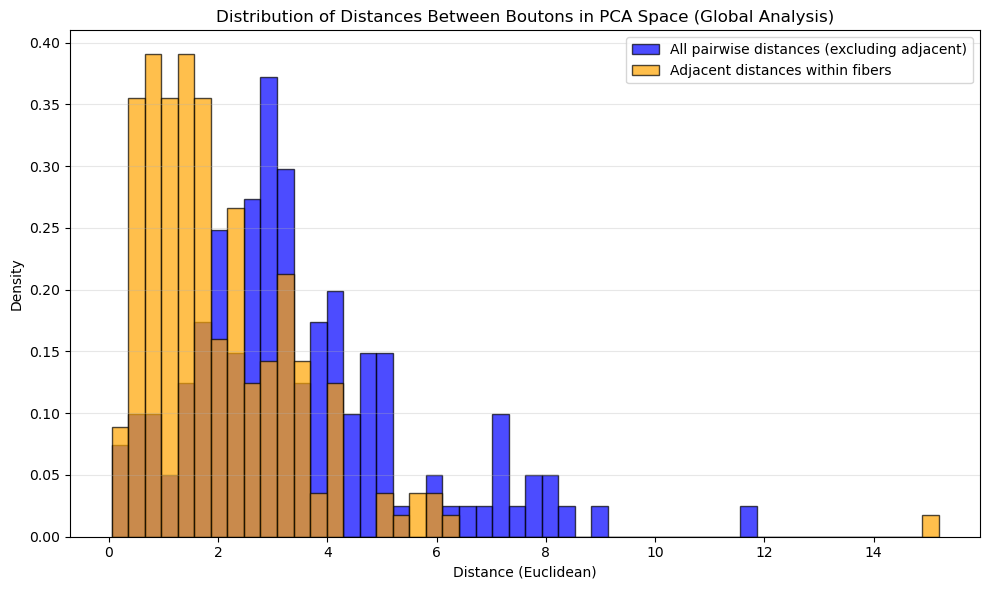

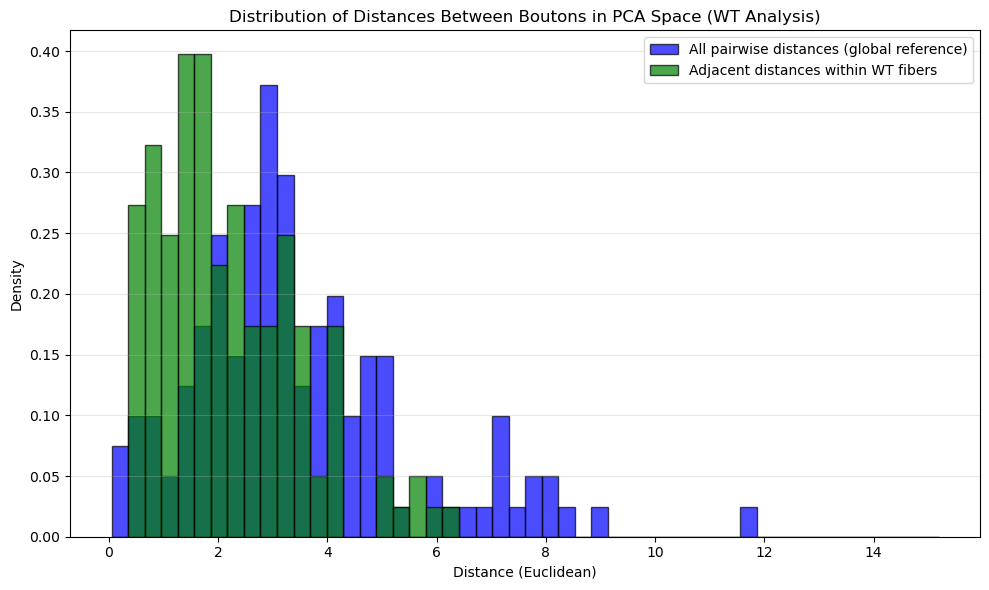

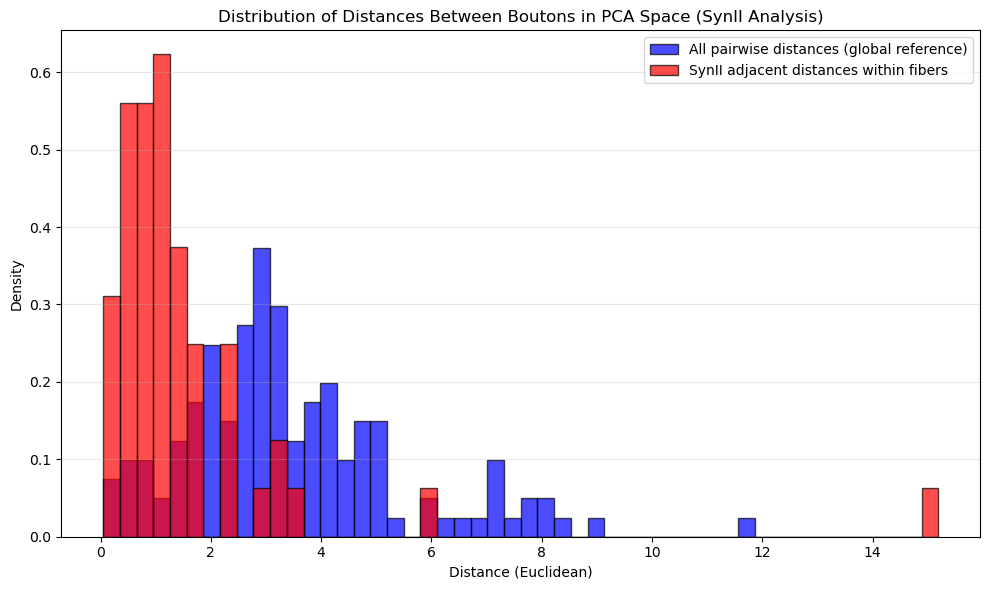

Analyses des distances terminées. Figures et résultats sauvegardés.
Fichiers sauvegardés:
  - 24_global_distance_analysis.txt
  - 25_wt_distance_analysis.txt
  - 26_synii_distance_analysis.txt


In [51]:
# Analyse des distances entre boutons dans l'espace PCA
from scipy.spatial import distance
from scipy.stats import ks_2samp
import io
import sys

def calculate_distance_distribution_excluding_adjacent(coordinates, fiber_info=None):
    """
    Calculate distances between all boutons excluding adjacent ones within same fiber.
    """
    n_samples = coordinates.shape[0]
    distances = []
    
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            skip_pair = False
            if fiber_info is not None:
                fiber_i = fiber_info.get(i)
                fiber_j = fiber_info.get(j)
                if fiber_i == fiber_j and fiber_i is not None and abs(i - j) == 1:
                    skip_pair = True
            
            if not skip_pair:
                dist = np.linalg.norm(coordinates[j] - coordinates[i])
                distances.append(dist)
    
    return np.array(distances)

def calculate_adjacent_distances(datasets_info):
    """
    Calculate distances between adjacent boutons within fibers.
    datasets_info: list of (dataframe, coordinates, name) tuples
    """
    all_adjacent = []
    wt_adjacent = []
    
    for df, coords, name in datasets_info:
        for fiber_id, fiber_group in df.groupby('Fiber_ID'):
            if len(fiber_group) > 1:
                indices = fiber_group.index.tolist()
                for i in range(len(indices) - 1):
                    coord1 = coords[indices[i]]
                    coord2 = coords[indices[i + 1]]
                    dist = np.linalg.norm(coord2 - coord1)
                    all_adjacent.append(dist)
                    if 'WT' in name:
                        wt_adjacent.append(dist)
    
    return all_adjacent, wt_adjacent

# Prepare data
datasets_info = [
    (df_SynII_with_fiber, transformed_data_SynII, 'SynII'),
    (df_WT_Anthime_with_fiber, transformed_data_WT_Anthime, 'WT_Anthime'),
    (df_WT_Theo_with_fiber, transformed_data_WT_Theo, 'WT_Theo')
]

# Calculate distances
all_adjacent_distances, wt_adjacent_distances = calculate_adjacent_distances(datasets_info)

# Create combined coordinates for global reference
all_coordinates = np.vstack([
    transformed_data_WT_pooled,
    transformed_data_SynII,
    transformed_data_WT_Anthime,
    transformed_data_WT_Theo
])

# Create combined fiber info
all_fiber_info = {}
idx = 0
for coords, df, prefix in [(transformed_data_WT_pooled, df_WT_poolclust, 'WT_pooled'),
                           (transformed_data_SynII, df_SynII_with_fiber, 'SynII'),
                           (transformed_data_WT_Anthime, df_WT_Anthime_with_fiber, 'WT_Anthime'),
                           (transformed_data_WT_Theo, df_WT_Theo_with_fiber, 'WT_Theo')]:
    for i, fiber_id in enumerate(df['Fiber_ID']):
        if idx + i < len(all_coordinates):
            all_fiber_info[idx + i] = f"{prefix}_{fiber_id}"
    idx += len(coords)

# Calculate global pairwise distances (excluding adjacent)
# Déterminer le nombre de distances adjacentes WT (pour équilibrer l'échantillonnage)
n_wt_adjacent = len(wt_adjacent_distances)


# Calculer toutes les distances pairwise (hors adjacentes) pour WT_pooled uniquement
pooled_distances = calculate_distance_distribution_excluding_adjacent(transformed_data_WT_pooled)

# Tirer au hasard (sans doublon) autant de distances que n_wt_adjacent
rng = np.random.default_rng(seed=42)
if len(pooled_distances) >= n_wt_adjacent:
    global_pairwise_distances = rng.choice(pooled_distances, size=n_wt_adjacent, replace=False)
else:
    global_pairwise_distances = pooled_distances  # fallback si pas assez de distances

# Calculate SynII adjacent distances
synii_adjacent_distances = []
for fiber_id, fiber_group in df_SynII_with_fiber.groupby('Fiber_ID'):
    if len(fiber_group) > 1:
        indices = fiber_group.index.tolist()
        for i in range(len(indices) - 1):
            coord1 = transformed_data_SynII[indices[i]]
            coord2 = transformed_data_SynII[indices[i + 1]]
            dist = np.linalg.norm(coord2 - coord1)
            synii_adjacent_distances.append(dist)

# Calculate bin edges for consistent plotting
all_distances_combined = np.concatenate([
    global_pairwise_distances, all_adjacent_distances, 
    wt_adjacent_distances, synii_adjacent_distances
])
bin_edges = np.linspace(np.min(all_distances_combined), np.max(all_distances_combined), 51)

# Function to save results
def save_results_to_file(filename, results_text):
    """Save analysis results to text file"""
    with open(os.path.join(output_dir, filename), 'w', encoding='utf-8') as f:
        f.write(results_text)

# Function to capture print output
def capture_prints(func):
    """Capture print statements from a function"""
    old_stdout = sys.stdout
    sys.stdout = buffer = io.StringIO()
    try:
        result = func()
        output = buffer.getvalue()
    finally:
        sys.stdout = old_stdout
    return result, output

# ============================================================================
# FIGURE 24: Analyse globale des distances (tous datasets)
# ============================================================================

def analyze_global_distances():
    results = []
    
    plt.figure(figsize=(10, 6))
    
    # Plot global pairwise distances
    plt.hist(global_pairwise_distances, bins=bin_edges, color='blue', alpha=0.7, 
             edgecolor='black', label='All pairwise distances (excluding adjacent)', density=True)
    
    # Plot adjacent distances
    plt.hist(all_adjacent_distances, bins=bin_edges, color='orange', alpha=0.7, 
             edgecolor='black', label='Adjacent distances within fibers', density=True)
    
    plt.title('Distribution of Distances Between Boutons in PCA Space (Global Analysis)')
    plt.xlabel('Distance (Euclidean)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "24_global_distance_analysis.pdf"))
    plt.show()
    
    # Statistical analysis
    results.append("=== ANALYSE GLOBALE DES DISTANCES ===")
    results.append(f"Distances toutes paires (excluant adjacentes): n={len(global_pairwise_distances)}")
    results.append(f"  Moyenne: {np.mean(global_pairwise_distances):.3f}")
    results.append(f"  Écart-type: {np.std(global_pairwise_distances):.3f}")
    results.append(f"  Min-Max: {np.min(global_pairwise_distances):.3f} - {np.max(global_pairwise_distances):.3f}")
    
    results.append(f"\nDistances adjacentes dans fibres: n={len(all_adjacent_distances)}")
    results.append(f"  Moyenne: {np.mean(all_adjacent_distances):.3f}")
    results.append(f"  Écart-type: {np.std(all_adjacent_distances):.3f}")
    results.append(f"  Min-Max: {np.min(all_adjacent_distances):.3f} - {np.max(all_adjacent_distances):.3f}")
    
    # Statistical test
    ks_stat, ks_p = ks_2samp(global_pairwise_distances, all_adjacent_distances)
    results.append(f"\nTest de Kolmogorov-Smirnov:")
    results.append(f"  Statistique: {ks_stat:.3f}")
    results.append(f"  p-value: {ks_p:.3e}")
    results.append(f"  Significatif: {'Oui' if ks_p < 0.05 else 'Non'} (p < 0.05)")
    
    return "\n".join(results)

# Execute analysis and save results
results_global = analyze_global_distances()
save_results_to_file("24_global_distance_analysis.txt", results_global)


# ============================================================================
# FIGURE 25: Analyse WT seulement
# ============================================================================

def analyze_wt_distances():
    results = []
    
    plt.figure(figsize=(10, 6))
    
    # Plot global reference distances
    plt.hist(global_pairwise_distances, bins=bin_edges, color='blue', alpha=0.7, 
             edgecolor='black', label='All pairwise distances (global reference)', density=True)
    
    # Plot WT adjacent distances
    plt.hist(wt_adjacent_distances, bins=bin_edges, color='green', alpha=0.7, 
             edgecolor='black', label='Adjacent distances within WT fibers', density=True)
    
    plt.title('Distribution of Distances Between Boutons in PCA Space (WT Analysis)')
    plt.xlabel('Distance (Euclidean)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "25_wt_distance_analysis.pdf"))
    plt.show()
    
    # Statistical analysis
    results.append("=== ANALYSE WT SEULEMENT ===")
    results.append(f"Distances de référence globales: n={len(global_pairwise_distances)}")
    results.append(f"  Moyenne: {np.mean(global_pairwise_distances):.3f}")
    results.append(f"  Écart-type: {np.std(global_pairwise_distances):.3f}")
    
    results.append(f"\nDistances adjacentes WT: n={len(wt_adjacent_distances)}")
    results.append(f"  Moyenne: {np.mean(wt_adjacent_distances):.3f}")
    results.append(f"  Écart-type: {np.std(wt_adjacent_distances):.3f}")
    results.append(f"  Min-Max: {np.min(wt_adjacent_distances):.3f} - {np.max(wt_adjacent_distances):.3f}")
    
    # Statistical test
    ks_stat, ks_p = ks_2samp(global_pairwise_distances, wt_adjacent_distances)
    results.append(f"\nTest de Kolmogorov-Smirnov:")
    results.append(f"  Statistique: {ks_stat:.3f}")
    results.append(f"  p-value: {ks_p:.3e}")
    results.append(f"  Significatif: {'Oui' if ks_p < 0.05 else 'Non'} (p < 0.05)")
    
    return "\n".join(results)

# Execute analysis and save results
results_wt = analyze_wt_distances()
save_results_to_file("25_wt_distance_analysis.txt", results_wt)


# ============================================================================
# FIGURE 26: Analyse SynII
# ============================================================================

def analyze_synii_distances():
    results = []
    
    plt.figure(figsize=(10, 6))
    
    # Plot global reference distances
    plt.hist(global_pairwise_distances, bins=bin_edges, color='blue', alpha=0.7, 
             edgecolor='black', label='All pairwise distances (global reference)', density=True)
    
    # Plot SynII adjacent distances (if any)
    if len(synii_adjacent_distances) > 0:
        plt.hist(synii_adjacent_distances, bins=bin_edges, color='red', alpha=0.7, 
                 edgecolor='black', label='SynII adjacent distances within fibers', density=True)
    
    plt.title('Distribution of Distances Between Boutons in PCA Space (SynII Analysis)')
    plt.xlabel('Distance (Euclidean)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "26_synii_distance_analysis.pdf"))
    plt.show()
    
    # Statistical analysis
    results.append("=== ANALYSE SynII ===")
    results.append(f"Distances de référence globales: n={len(global_pairwise_distances)}")
    results.append(f"  Moyenne: {np.mean(global_pairwise_distances):.3f}")
    results.append(f"  Écart-type: {np.std(global_pairwise_distances):.3f}")
    
    if len(synii_adjacent_distances) > 0:
        results.append(f"\nDistances adjacentes SynII: n={len(synii_adjacent_distances)}")
        results.append(f"  Moyenne: {np.mean(synii_adjacent_distances):.3f}")
        results.append(f"  Écart-type: {np.std(synii_adjacent_distances):.3f}")
        results.append(f"  Min-Max: {np.min(synii_adjacent_distances):.3f} - {np.max(synii_adjacent_distances):.3f}")
        
        # Statistical test
        ks_stat, ks_p = ks_2samp(global_pairwise_distances, synii_adjacent_distances)
        results.append(f"\nTest de Kolmogorov-Smirnov:")
        results.append(f"  Statistique: {ks_stat:.3f}")
        results.append(f"  p-value: {ks_p:.3e}")
        results.append(f"  Significatif: {'Oui' if ks_p < 0.05 else 'Non'} (p < 0.05)")
    else:
        results.append("\nAucune distance adjacente SynII trouvée")
        results.append("(Pas de fibres SynII avec boutons multiples)")
    
    return "\n".join(results)

# Execute analysis and save results
results_synii = analyze_synii_distances()
save_results_to_file("26_synii_distance_analysis.txt", results_synii)

print("Analyses des distances terminées. Figures et résultats sauvegardés.")
print(f"Fichiers sauvegardés:")
print(f"  - 24_global_distance_analysis.txt")
print(f"  - 25_wt_distance_analysis.txt") 
print(f"  - 26_synii_distance_analysis.txt")


    


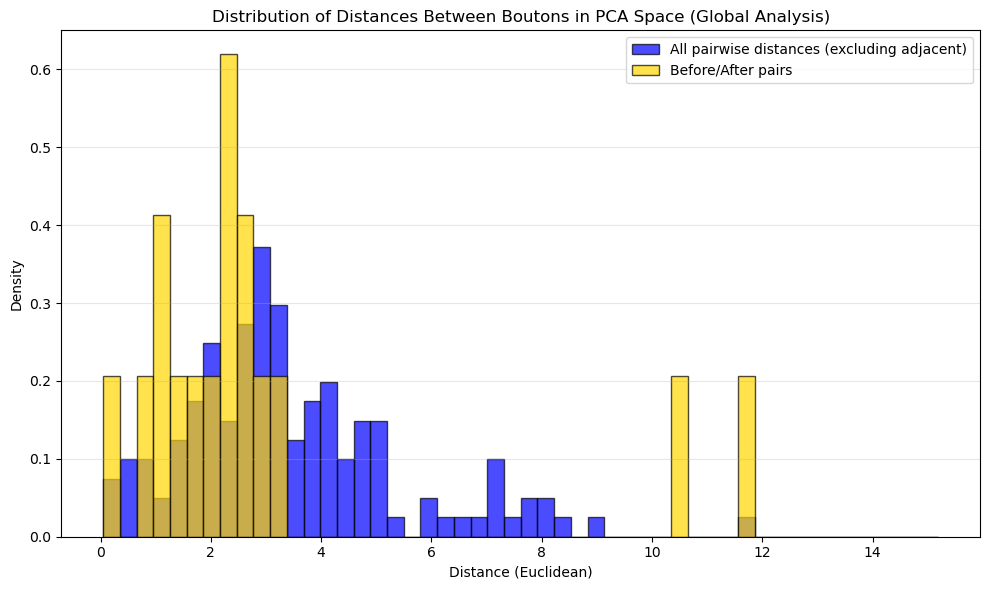

In [52]:
# Remplace la fonction analyze_global_distances pour comparer les distances before/after

def analyze_global_distances():
    results = []

    # Calcul des distances entre pairs before/after
    before_after_distances = np.linalg.norm(transformed_data_stab_before - transformed_data_stab_after, axis=1)

    plt.figure(figsize=(10, 6))

    # Plot global pairwise distances
    plt.hist(global_pairwise_distances, bins=bin_edges, color='blue', alpha=0.7,
             edgecolor='black', label='All pairwise distances (excluding adjacent)', density=True)

    # Plot before/after distances
    plt.hist(before_after_distances, bins=bin_edges, color='gold', alpha=0.7,
             edgecolor='black', label='Before/After pairs', density=True)

    plt.title('Distribution of Distances Between Boutons in PCA Space (Global Analysis)')
    plt.xlabel('Distance (Euclidean)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "24_global_distance_analysis.pdf"))
    plt.show()

    # Statistical analysis
    results.append("=== ANALYSE GLOBALE DES DISTANCES ===")
    results.append(f"Distances toutes paires (excluant adjacentes): n={len(global_pairwise_distances)}")
    results.append(f"  Moyenne: {np.mean(global_pairwise_distances):.3f}")
    results.append(f"  Écart-type: {np.std(global_pairwise_distances):.3f}")
    results.append(f"  Min-Max: {np.min(global_pairwise_distances):.3f} - {np.max(global_pairwise_distances):.3f}")

    results.append(f"\nDistances before/after: n={len(before_after_distances)}")
    results.append(f"  Moyenne: {np.mean(before_after_distances):.3f}")
    results.append(f"  Écart-type: {np.std(before_after_distances):.3f}")
    results.append(f"  Min-Max: {np.min(before_after_distances):.3f} - {np.max(before_after_distances):.3f}")

    # Statistical test
    ks_stat, ks_p = ks_2samp(global_pairwise_distances, before_after_distances)
    results.append(f"\nTest de Kolmogorov-Smirnov:")
    results.append(f"  Statistique: {ks_stat:.3f}")
    results.append(f"  p-value: {ks_p:.3e}")
    results.append(f"  Significatif: {'Oui' if ks_p < 0.05 else 'Non'} (p < 0.05)")

    return "\n".join(results)

# Exécute l'analyse et sauvegarde les résultats
results_global = analyze_global_distances()
save_results_to_file("24_global_distance_analysis.txt", results_global)
